<a href="https://colab.research.google.com/github/bmlogs64/TCC-Futebol-ML/blob/main/TCC_Futebol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistema de Recomendação de Jogadores de Futebol

## Aplicação de Técnicas de Ciência de Dados e Inteligência Artificial na Identificação de Substitutos Financeiramente Viáveis no Futebol

Este notebook apresenta as etapas de desenvolvimento do sistema de recomendação de jogadores, abrangendo a obtenção dos dados, análise exploratória, pré-processamento, treinamento de modelos e identificação de atletas com características semelhantes.

Os dados esportivos utilizados correspondem à temporada 2024/2025 e são obtidos diretamente da plataforma Kaggle.


In [1]:
!pip install -q kagglehub

In [2]:
import os
import pandas as pd
import numpy as np
import kagglehub

## 1. Obtenção dos dados

A primeira etapa consiste na obtenção da base de dados contendo as estatísticas de desempenho dos jogadores na temporada 2024/2025.

Para tornar o processo reproduzível, os dados são obtidos diretamente do Kaggle por meio da biblioteca `kagglehub`. Dessa forma, não é necessário realizar o download manual do arquivo ou armazená-lo previamente no ambiente do Google Colab.


In [3]:
path = kagglehub.dataset_download(
    "hubertsidorowicz/football-players-stats-2024-2025"
)

print("Caminho do dataset:", path)

Using Colab cache for faster access to the 'football-players-stats-2024-2025' dataset.
Caminho do dataset: /kaggle/input/football-players-stats-2024-2025


In [4]:
arquivos = os.listdir(path)

print("Arquivos disponíveis no dataset:")
for arquivo in arquivos:
    print("-", arquivo)

Arquivos disponíveis no dataset:
- players_data_light-2024_2025.csv
- players_data-2024_2025.csv


### Verificação dos arquivos

Após o download, são verificados os arquivos disponibilizados pelo dataset. Essa etapa permite identificar o arquivo que contém as estatísticas dos jogadores antes de realizar sua leitura e iniciar a análise exploratória.

## 2. Carregamento e inspeção inicial dos dados

Após identificar os arquivos disponíveis, será utilizada a versão completa da base de dados, denominada `players_data-2024_2025.csv`.

Nesta etapa, o objetivo é carregar os dados em um DataFrame e realizar uma primeira inspeção da estrutura da base antes de qualquer procedimento de limpeza ou transformação.

In [5]:
arquivo_dados = os.path.join(
    path,
    "players_data-2024_2025.csv"
)

df = pd.read_csv(arquivo_dados)

print("Base carregada com sucesso.")

Base carregada com sucesso.


In [6]:
df.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Att (GK),Thr,Launch%,AvgLen,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,2000.0,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Max Aarons,eng ENG,"DF,MF",Valencia,es La Liga,24.0,2000.0,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,2003.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,James Abankwah,ie IRL,"DF,MF",Udinese,it Serie A,20.0,2004.0,6,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,18.0,2006.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
print("Quantidade de jogadores:", df.shape[0])
print("Quantidade de colunas:", df.shape[1])

Quantidade de jogadores: 2854
Quantidade de colunas: 267


In [8]:
print("Colunas disponíveis na base:\n")

for coluna in df.columns:
    print("-", coluna)

Colunas disponíveis na base:

- Rk
- Player
- Nation
- Pos
- Squad
- Comp
- Age
- Born
- MP
- Starts
- Min
- 90s
- Gls
- Ast
- G+A
- G-PK
- PK
- PKatt
- CrdY
- CrdR
- xG
- npxG
- xAG
- npxG+xAG
- PrgC
- PrgP
- PrgR
- G+A-PK
- xG+xAG
- Rk_stats_shooting
- Nation_stats_shooting
- Pos_stats_shooting
- Comp_stats_shooting
- Age_stats_shooting
- Born_stats_shooting
- 90s_stats_shooting
- Gls_stats_shooting
- Sh
- SoT
- SoT%
- Sh/90
- SoT/90
- G/Sh
- G/SoT
- Dist
- FK
- PK_stats_shooting
- PKatt_stats_shooting
- xG_stats_shooting
- npxG_stats_shooting
- npxG/Sh
- G-xG
- np:G-xG
- Rk_stats_passing
- Nation_stats_passing
- Pos_stats_passing
- Comp_stats_passing
- Age_stats_passing
- Born_stats_passing
- 90s_stats_passing
- Cmp
- Att
- Cmp%
- TotDist
- PrgDist
- Ast_stats_passing
- xAG_stats_passing
- xA
- A-xAG
- KP
- 1/3
- PPA
- CrsPA
- PrgP_stats_passing
- Rk_stats_passing_types
- Nation_stats_passing_types
- Pos_stats_passing_types
- Comp_stats_passing_types
- Age_stats_passing_types
- Born

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2854 entries, 0 to 2853
Columns: 267 entries, Rk to AvgDist
dtypes: float64(111), int64(121), object(35)
memory usage: 5.8+ MB


## 3. Análise Exploratória dos Dados

Com a base carregada, inicia-se a etapa de Análise Exploratória de Dados (EDA).

O objetivo desta etapa é compreender a estrutura do conjunto de dados, verificar a distribuição dos jogadores entre posições e competições, analisar o tempo de participação dos atletas e identificar possíveis problemas de qualidade, como valores ausentes e registros duplicados.

Como a base reúne diferentes grupos de estatísticas, como finalização, passes, criação de jogadas, defesa, posse de bola e desempenho de goleiros, algumas informações aparecem repetidas com diferentes sufixos. Essas variáveis serão analisadas posteriormente antes da seleção das características utilizadas pelos modelos.

In [10]:
df[
    ["Player", "Nation", "Pos", "Squad", "Comp", "Age", "MP", "Starts", "Min"]
].head(10)

,Player,Nation,Pos,Squad,Comp,Age,MP,Starts,Min
0,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,3,1,86
1,Max Aarons,eng ENG,"DF,MF",Valencia,es La Liga,24.0,4,1,120
2,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,1,1,65
3,James Abankwah,ie IRL,"DF,MF",Udinese,it Serie A,20.0,6,0,88
4,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,18.0,1,0,3
5,Yunis Abdelhamid,ma MAR,DF,Saint-Étienne,fr Ligue 1,36.0,16,11,1033
6,Himad Abdelli,dz ALG,"MF,FW",Angers,fr Ligue 1,24.0,32,32,2842
7,Mohamed Abdelmoneim,eg EGY,DF,Nice,fr Ligue 1,25.0,12,10,855
8,Ali Abdi,tn TUN,"DF,MF",Nice,fr Ligue 1,30.0,25,17,1393
9,Saud Abdulhamid,sa KSA,DF,Roma,it Serie A,25.0,4,2,205


In [11]:
print("Distribuição dos jogadores por posição:\n")

df["Pos"].value_counts()

Distribuição dos jogadores por posição:



,count
Pos,
DF,859
MF,589
FW,371
"FW,MF",325
"MF,FW",230
GK,212
"DF,MF",110
"MF,DF",81
"DF,FW",53


In [12]:
print("Quantidade de jogadores por competição:\n")

df["Comp"].value_counts()

Quantidade de jogadores por competição:



,count
Comp,
it Serie A,634
es La Liga,601
eng Premier League,574
fr Ligue 1,553
de Bundesliga,492


In [13]:
df["Min"].describe()

,Min
count,2854.000000
mean,1211.529082
std,965.191628
min,1.000000
25%,317.250000
50%,1052.500000
75%,1996.750000
max,3420.000000


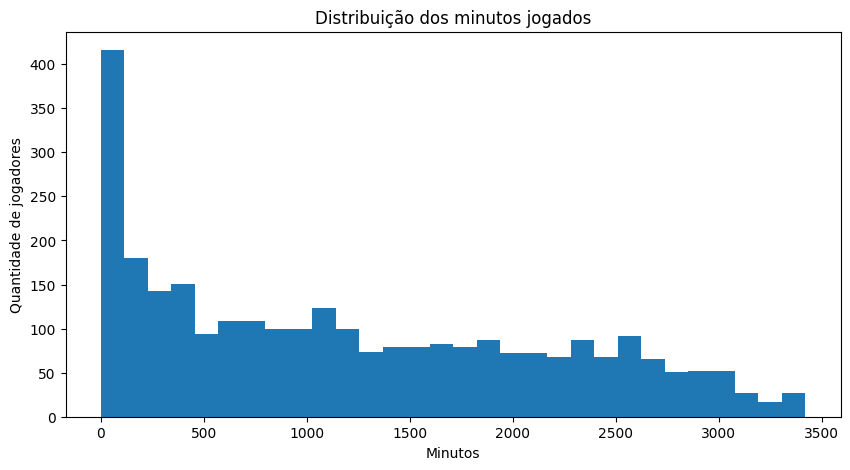

In [14]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df["Min"].dropna(), bins=30)
plt.title("Distribuição dos minutos jogados")
plt.xlabel("Minutos")
plt.ylabel("Quantidade de jogadores")
plt.show()

In [15]:
minutos_minimos = 900

abaixo_900 = (df["Min"] < minutos_minimos).sum()
acima_900 = (df["Min"] >= minutos_minimos).sum()

print("Jogadores com menos de 900 minutos:", abaixo_900)
print("Jogadores com 900 minutos ou mais:", acima_900)
print("Total:", len(df))

percentual_abaixo = abaixo_900 / len(df) * 100
percentual_acima = acima_900 / len(df) * 100

print(f"Abaixo de 900 minutos: {percentual_abaixo:.2f}%")
print(f"900 minutos ou mais: {percentual_acima:.2f}%")

Jogadores com menos de 900 minutos: 1284
Jogadores com 900 minutos ou mais: 1570
Total: 2854
Abaixo de 900 minutos: 44.99%
900 minutos ou mais: 55.01%


In [16]:
valores_ausentes = df.isnull().sum()

valores_ausentes = valores_ausentes[
    valores_ausentes > 0
].sort_values(ascending=False)

print("Quantidade de colunas com valores ausentes:", len(valores_ausentes))

valores_ausentes.head(30)

Quantidade de colunas com valores ausentes: 93


,0
CS%,2651
Save%,2648
PSxG/SoT,2648
AvgDist,2646
Cmp%_stats_keeper_adv,2644
Stp%,2643
90s_stats_keeper_adv,2642
Born_stats_keeper_adv,2642
MP_stats_keeper,2642
PKA,2642


In [17]:
duplicados = df.duplicated().sum()

print("Quantidade de registros completamente duplicados:", duplicados)

nomes_repetidos = df[df.duplicated(subset=["Player"], keep=False)]

print("Quantidade de registros com nomes de jogadores repetidos:",
      len(nomes_repetidos))

nomes_repetidos[
    ["Player", "Squad", "Pos", "Age"]
].sort_values("Player").head(30)

Quantidade de registros completamente duplicados: 0
Quantidade de registros com nomes de jogadores repetidos: 304


,Player,Squad,Pos,Age
1352,Abdukodir Khusanov,Lens,DF,20.0
1351,Abdukodir Khusanov,Manchester City,DF,20.0
189,Adam Aznou,Bayern Munich,DF,18.0
188,Adam Aznou,Valladolid,DF,18.0
22,Akor Adams,Sevilla,FW,24.0
23,Akor Adams,Montpellier,FW,24.0
1072,Albert Grønbaek,Rennes,"MF,FW",23.0
1071,Albert Grønbaek,Southampton,"FW,MF",23.0
328,Alessandro Bianco,Monza,MF,21.0
329,Alessandro Bianco,Fiorentina,MF,21.0


In [18]:
colunas_principais = [
    "Player",
    "Nation",
    "Pos",
    "Squad",
    "Comp",
    "Age",
    "MP",
    "Starts",
    "Min",
    "90s",
    "Gls",
    "Ast",
    "xG",
    "xAG"
]

df[colunas_principais].dtypes

,0
Player,object
Nation,object
Pos,object
Squad,object
Comp,object
Age,float64
MP,int64
Starts,int64
Min,int64
90s,float64


### Jogadores com múltiplos registros

Alguns jogadores aparecem mais de uma vez na base, possivelmente por terem atuado por diferentes clubes durante a temporada 2024/2025. Antes de aplicar o filtro mínimo de minutos, esses casos serão analisados para evitar a exclusão incorreta de atletas cujos minutos estão distribuídos entre mais de um registro.

In [19]:
contagem_jogadores = df["Player"].value_counts()

jogadores_multiplos = contagem_jogadores[
    contagem_jogadores > 1
]

print("Jogadores com mais de um registro:", len(jogadores_multiplos))

jogadores_multiplos.head(20)

Jogadores com mais de um registro: 152


,count
Player,
Rodri,2
Lennard Maloney,2
Trevoh Chalobah,2
Joshua King,2
Urko González,2
Gabriel Vidovic,2
Nicolás González,2
Abdukodir Khusanov,2
Tomás Palacios,2


In [20]:
df_multiplos = df[
    df["Player"].isin(jogadores_multiplos.index)
][
    [
        "Player",
        "Squad",
        "Comp",
        "Pos",
        "Age",
        "MP",
        "Starts",
        "Min",
        "90s"
    ]
].sort_values(["Player", "Squad"])

df_multiplos.head(40)

,Player,Squad,Comp,Pos,Age,MP,Starts,Min,90s
1352,Abdukodir Khusanov,Lens,fr Ligue 1,DF,20.0,13,11,975,10.8
1351,Abdukodir Khusanov,Manchester City,eng Premier League,DF,20.0,6,6,503,5.6
189,Adam Aznou,Bayern Munich,de Bundesliga,DF,18.0,2,0,17,0.2
188,Adam Aznou,Valladolid,es La Liga,DF,18.0,13,10,876,9.7
23,Akor Adams,Montpellier,fr Ligue 1,FW,24.0,15,13,1075,11.9
22,Akor Adams,Sevilla,es La Liga,FW,24.0,4,1,134,1.5
1072,Albert Grønbaek,Rennes,fr Ligue 1,"MF,FW",23.0,16,9,813,9.0
1071,Albert Grønbaek,Southampton,eng Premier League,"FW,MF",23.0,4,2,143,1.6
329,Alessandro Bianco,Fiorentina,it Serie A,MF,21.0,1,0,18,0.2
328,Alessandro Bianco,Monza,it Serie A,MF,21.0,34,29,2600,28.9


In [21]:
minutos_multiplos = (
    df_multiplos
    .groupby("Player")["Min"]
    .agg(["count", "sum"])
    .sort_values("sum", ascending=False)
)

minutos_multiplos.head(30)

,count,sum
Player,,
Vitinha,2,3370
Enzo Boyomo,2,3257
Scott McTominay,2,2957
Brice Samba,2,2879
Luis Rioja,2,2854
Marshall Munetsi,2,2770
Pablo Marí,2,2726
Patrick Dorgu,2,2682
Logan Costa,2,2677


In [22]:
jogadores_afetados_filtro = minutos_multiplos[
    minutos_multiplos["sum"] >= 900
]

print(
    "Jogadores com múltiplos registros que somam 900 minutos ou mais:",
    len(jogadores_afetados_filtro)
)

jogadores_afetados_filtro.head(30)

Jogadores com múltiplos registros que somam 900 minutos ou mais: 100


,count,sum
Player,,
Vitinha,2,3370
Enzo Boyomo,2,3257
Scott McTominay,2,2957
Brice Samba,2,2879
Luis Rioja,2,2854
Marshall Munetsi,2,2770
Pablo Marí,2,2726
Patrick Dorgu,2,2682
Logan Costa,2,2677


In [23]:
resumo_multiplos = (
    df_multiplos
    .groupby("Player")
    .agg(
        registros=("Player", "size"),
        minutos_totais=("Min", "sum"),
        maior_registro_min=("Min", "max"),
        menor_registro_min=("Min", "min")
    )
)

resumo_multiplos["seria_perdido_pelo_filtro"] = (
    (resumo_multiplos["minutos_totais"] >= 900) &
    (resumo_multiplos["maior_registro_min"] < 900)
)

resumo_multiplos.sort_values(
    "minutos_totais",
    ascending=False
).head(30)

,registros,minutos_totais,maior_registro_min,menor_registro_min,seria_perdido_pelo_filtro
Player,,,,,
Vitinha,2,3370,2042,1328,False
Enzo Boyomo,2,3257,2987,270,False
Scott McTominay,2,2957,2938,19,False
Brice Samba,2,2879,1529,1350,False
Luis Rioja,2,2854,2831,23,False
Marshall Munetsi,2,2770,1692,1078,False
Pablo Marí,2,2726,1628,1098,False
Patrick Dorgu,2,2682,1840,842,False
Logan Costa,2,2677,2587,90,False


In [24]:
afetados_filtro = resumo_multiplos[
    resumo_multiplos["seria_perdido_pelo_filtro"]
]

print(
    "Jogadores que somam 900 minutos ou mais, "
    "mas seriam excluídos pelo filtro aplicado por registro:",
    len(afetados_filtro)
)

afetados_filtro.sort_values(
    "minutos_totais",
    ascending=False
)

Jogadores que somam 900 minutos ou mais, mas seriam excluídos pelo filtro aplicado por registro: 20


,registros,minutos_totais,maior_registro_min,menor_registro_min,seria_perdido_pelo_filtro
Player,,,,,
Juma Bah,2,1550,864,686,True
Alessandro Vogliacco,2,1487,772,715,True
Marco Asensio,2,1361,743,618,True
Anastasios Douvikas,2,1280,700,580,True
Florian Grillitsch,2,1224,623,601,True
Julio Enciso,2,1163,869,294,True
João Félix,2,1129,760,369,True
Christian Kouamé,2,1129,622,507,True
Stefan Posch,2,1101,714,387,True


In [25]:
afetados_filtro = resumo_multiplos[
    resumo_multiplos["seria_perdido_pelo_filtro"]
].sort_values(
    "minutos_totais",
    ascending=False
)

print(
    "Jogadores que possuem 900 minutos ou mais no total, "
    "mas não chegam a 900 em nenhum clube:",
    len(afetados_filtro)
)

afetados_filtro

Jogadores que possuem 900 minutos ou mais no total, mas não chegam a 900 em nenhum clube: 20


,registros,minutos_totais,maior_registro_min,menor_registro_min,seria_perdido_pelo_filtro
Player,,,,,
Juma Bah,2,1550,864,686,True
Alessandro Vogliacco,2,1487,772,715,True
Marco Asensio,2,1361,743,618,True
Anastasios Douvikas,2,1280,700,580,True
Florian Grillitsch,2,1224,623,601,True
Julio Enciso,2,1163,869,294,True
João Félix,2,1129,760,369,True
Christian Kouamé,2,1129,622,507,True
Stefan Posch,2,1101,714,387,True


### Verificação da identidade dos jogadores com nomes repetidos

Antes de combinar os registros de jogadores que aparecem mais de uma vez, é necessário verificar se as ocorrências correspondem realmente ao mesmo atleta. Para isso, serão comparadas informações como idade, ano de nascimento, nacionalidade, posição e identificador de linha da base.

In [26]:
resumo_identidade = (
    df[df["Player"].isin(jogadores_multiplos.index)]
    .groupby("Player")
    .agg(
        registros=("Player", "size"),
        idades_diferentes=("Age", "nunique"),
        anos_nascimento_diferentes=("Born", "nunique"),
        nacionalidades_diferentes=("Nation", "nunique"),
        posicoes_diferentes=("Pos", "nunique"),
        clubes_diferentes=("Squad", "nunique")
    )
)

resumo_identidade.head(30)

,registros,idades_diferentes,anos_nascimento_diferentes,nacionalidades_diferentes,posicoes_diferentes,clubes_diferentes
Player,,,,,,
Abdukodir Khusanov,2,1,1,1,1,2
Adam Aznou,2,1,1,1,1,2
Akor Adams,2,1,1,1,1,2
Albert Grønbaek,2,1,1,1,2,2
Alessandro Bianco,2,1,1,1,1,2
Alessandro Marcandalli,2,1,1,1,1,2
Alessandro Vogliacco,2,1,1,1,1,2
Alessio Zerbin,2,1,1,1,2,2
Alexis Saelemaekers,2,1,1,1,1,2


In [27]:
possiveis_homonimos = resumo_identidade[
    (resumo_identidade["idades_diferentes"] > 1) |
    (resumo_identidade["anos_nascimento_diferentes"] > 1) |
    (resumo_identidade["nacionalidades_diferentes"] > 1)
]

print(
    "Nomes repetidos com indícios de jogadores diferentes:",
    len(possiveis_homonimos)
)

possiveis_homonimos

Nomes repetidos com indícios de jogadores diferentes: 5


,registros,idades_diferentes,anos_nascimento_diferentes,nacionalidades_diferentes,posicoes_diferentes,clubes_diferentes
Player,,,,,,
Danilo,2,2,2,1,2,2
David López,2,2,2,1,1,2
Joshua King,2,2,2,2,2,2
Nicolás González,2,2,2,2,2,2
Rodri,2,2,2,1,2,2


In [28]:
df_homonimos = df[
    df["Player"].isin(possiveis_homonimos.index)
][
    [
        "Rk",
        "Player",
        "Nation",
        "Age",
        "Born",
        "Pos",
        "Squad",
        "Comp",
        "Min"
    ]
].sort_values(["Player", "Squad"])

df_homonimos

,Rk,Player,Nation,Age,Born,Pos,Squad,Comp,Min
655,656,Danilo,br BRA,33.0,1991.0,DF,Juventus,it Serie A,581
654,655,Danilo,br BRA,23.0,2001.0,"MF,FW",Nott'ham Forest,eng Premier League,275
1516,1517,David López,es ESP,34.0,1989.0,DF,Girona,es La Liga,2429
1515,1516,David López,es ESP,21.0,2003.0,DF,Mallorca,es La Liga,169
1358,1359,Joshua King,eng ENG,17.0,2007.0,MF,Fulham,eng Premier League,130
1359,1360,Joshua King,no NOR,32.0,1992.0,"FW,MF",Toulouse,fr Ligue 1,1673
1036,1037,Nicolás González,ar ARG,26.0,1998.0,"FW,MF",Juventus,it Serie A,1750
1035,1036,Nicolás González,es ESP,22.0,2002.0,MF,Manchester City,eng Premier League,760
2227,2228,Rodri,es ESP,24.0,2000.0,FW,Betis,es La Liga,118
2226,2227,Rodri,es ESP,28.0,1996.0,MF,Manchester City,eng Premier League,73


In [29]:
def conjunto_posicoes(pos):
    return set(str(pos).split(","))

analise_posicoes = []

for jogador, grupo in df[
    df["Player"].isin(jogadores_multiplos.index)
].groupby("Player"):

    posicoes = grupo["Pos"].apply(conjunto_posicoes).tolist()

    if len(posicoes) > 1:
        intersecao = set.intersection(*posicoes)

        analise_posicoes.append({
            "Player": jogador,
            "Posicoes": grupo["Pos"].tolist(),
            "Tem_posicao_em_comum": len(intersecao) > 0
        })

df_compatibilidade_posicao = pd.DataFrame(analise_posicoes)

df_compatibilidade_posicao[
    df_compatibilidade_posicao["Tem_posicao_em_comum"] == False
]

,Player,Posicoes,Tem_posicao_em_comum
15,Antony,"[DF,MF, FW]",False
16,Arijon Ibrahimović,"[MF, FW]",False
17,Arnaud Nordin,"[FW, DF,MF]",False
33,Danilo,"[MF,FW, DF]",False
103,Mitchel Bakker,"[MF, FW,DF]",False
130,Rodri,"[MF, FW]",False
140,Tajon Buchanan,"[DF,FW, MF]",False


In [30]:
df[
    df["Player"] == "Vitinha"
][
    [
        "Rk",
        "Player",
        "Nation",
        "Age",
        "Born",
        "Pos",
        "Squad",
        "Comp",
        "Min"
    ]
]

,Rk,Player,Nation,Age,Born,Pos,Squad,Comp,Min
2717,2718,Vitinha,pt POR,24.0,2000.0,"FW,MF",Genoa,it Serie A,1328
2718,2719,Vitinha,pt POR,24.0,2000.0,MF,Paris S-G,fr Ligue 1,2042


In [31]:
homonimos_posicao = df_compatibilidade_posicao[
    df_compatibilidade_posicao["Tem_posicao_em_comum"] == False
]["Player"].tolist()

homonimos_demograficos = possiveis_homonimos.index.tolist()

homonimos_suspeitos = sorted(
    set(homonimos_demograficos + homonimos_posicao)
)

print("Quantidade de nomes que exigem tratamento separado:",
      len(homonimos_suspeitos))

homonimos_suspeitos

Quantidade de nomes que exigem tratamento separado: 10


['Antony',
 'Arijon Ibrahimović',
 'Arnaud Nordin',
 'Danilo',
 'David López',
 'Joshua King',
 'Mitchel Bakker',
 'Nicolás González',
 'Rodri',
 'Tajon Buchanan']

## 4. Integração com dados do Transfermarkt

Para identificar corretamente os jogadores e posteriormente incorporar informações financeiras, será utilizada uma segunda base de dados obtida diretamente do Kaggle.

Essa base contém identificadores únicos dos atletas (`player_id`), além de informações cadastrais e históricos de valor de mercado. O identificador será utilizado para reduzir ambiguidades causadas por jogadores com nomes iguais e por atletas que atuaram por mais de um clube durante a temporada.

In [32]:
path_transfermarkt = kagglehub.dataset_download(
    "davidcariboo/player-scores"
)

print("Caminho do dataset Transfermarkt:", path_transfermarkt)

100%|██████████| 234M/234M [00:05<00:00, 47.2MB/s]

Extracting files...


Caminho do dataset Transfermarkt: /root/.cache/kagglehub/datasets/davidcariboo/player-scores/versions/679


In [33]:
arquivos_transfermarkt = os.listdir(path_transfermarkt)

print("Arquivos disponíveis no dataset Transfermarkt:\n")

for arquivo in arquivos_transfermarkt:
    print("-", arquivo)

Arquivos disponíveis no dataset Transfermarkt:

- players.csv
- national_teams.csv
- game_events.csv
- competitions.csv
- game_lineups.csv
- transfers.csv
- clubs.csv
- appearances.csv
- games.csv
- player_valuations.csv
- countries.csv
- club_games.csv


In [34]:
arquivo_players = os.path.join(
    path_transfermarkt,
    "players.csv"
)

arquivo_valores = os.path.join(
    path_transfermarkt,
    "player_valuations.csv"
)

df_players_tm = pd.read_csv(arquivo_players)
df_valores_tm = pd.read_csv(arquivo_valores)

print("Players:", df_players_tm.shape)
print("Valuações:", df_valores_tm.shape)

Players: (50149, 26)
Valuações: (656301, 6)


In [35]:
print("Colunas de players.csv:\n")
print(df_players_tm.columns.tolist())

print("\nColunas de player_valuations.csv:\n")
print(df_valores_tm.columns.tolist())

Colunas de players.csv:

['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']

Colunas de player_valuations.csv:

['player_id', 'date', 'market_value_in_eur', 'current_club_name', 'current_club_id', 'player_club_domestic_competition_id']


## 5. Preparação dos dados de mercado

Os valores de mercado variam ao longo do tempo. Para manter coerência com a temporada esportiva 2024/2025, serão consideradas apenas avaliações registradas até 30 de junho de 2025.

Para cada jogador, será selecionada sua avaliação mais recente disponível até essa data. O histórico de clubes também será preservado para auxiliar posteriormente na identificação de jogadores com nomes semelhantes ou que foram transferidos durante a temporada.

In [36]:
df_valores_tm["date"] = pd.to_datetime(
    df_valores_tm["date"],
    errors="coerce"
)

DATA_LIMITE = pd.Timestamp("2025-06-30")
INICIO_TEMPORADA = pd.Timestamp("2024-07-01")

print("Primeira avaliação da base:", df_valores_tm["date"].min())
print("Última avaliação da base:", df_valores_tm["date"].max())

Primeira avaliação da base: 2000-01-20 00:00:00
Última avaliação da base: 2026-06-12 00:00:00


In [37]:
df_valores_ate_limite = df_valores_tm[
    df_valores_tm["date"] <= DATA_LIMITE
].copy()

print("Registros até a data limite:", len(df_valores_ate_limite))

Registros até a data limite: 612262


In [38]:
df_ultima_valoracao = (
    df_valores_ate_limite
    .sort_values("date")
    .groupby("player_id", as_index=False)
    .tail(1)
    .copy()
)

print(
    "Jogadores com avaliação disponível até 30/06/2025:",
    df_ultima_valoracao["player_id"].nunique()
)

df_ultima_valoracao.head()

Jogadores com avaliação disponível até 30/06/2025: 40152


,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
4568,16733,2005-12-02,100000,Malmö FF,678,DK1
15921,73096,2008-04-16,50000,CA Metropolitano,982,PO1
31975,62553,2009-10-25,200000,Hibernian FC,2759,SC1
34350,134354,2009-12-28,50000,Unknown,498,BE1
37862,144619,2010-03-15,25000,Spartak Moskow II,232,RU1


In [39]:
df_mercado = df_players_tm.merge(
    df_ultima_valoracao[
        [
            "player_id",
            "date",
            "market_value_in_eur",
            "current_club_name"
        ]
    ],
    on="player_id",
    how="inner",
    suffixes=("_players", "_valuation")
)

df_mercado = df_mercado[
    [
        "player_id",
        "name",
        "first_name",
        "last_name",
        "player_code",
        "date_of_birth",
        "position",
        "sub_position",
        "country_of_citizenship",
        "current_club_name_valuation",
        "date",
        "market_value_in_eur_valuation"
    ]
].copy()

df_mercado.rename(
    columns={
        "current_club_name_valuation": "club_tm",
        "date": "valuation_date",
        "market_value_in_eur_valuation": "market_value_in_eur"
    },
    inplace=True
)

print("Dimensões da base de mercado:", df_mercado.shape)

df_mercado.head()

Dimensões da base de mercado: (40152, 12)


,player_id,name,first_name,last_name,player_code,date_of_birth,position,sub_position,country_of_citizenship,club_tm,valuation_date,market_value_in_eur
0,10,Miroslav Klose,Miroslav,Klose,miroslav-klose,1978-06-09 00:00:00,Attack,Centre-Forward,Germany,SS Lazio,2016-01-04,1000000
1,26,Roman Weidenfeller,Roman,Weidenfeller,roman-weidenfeller,1980-08-06 00:00:00,Goalkeeper,Goalkeeper,Germany,Borussia Dortmund,2017-12-28,750000
2,65,Dimitar Berbatov,Dimitar,Berbatov,dimitar-berbatov,1981-01-30 00:00:00,Attack,Centre-Forward,Bulgaria,PAOK Thessaloniki,2016-06-21,1000000
3,77,Lúcio,NaN,Lúcio,lucio,1978-05-08 00:00:00,Defender,Centre-Back,Brazil,FC Goa,2016-11-15,200000
4,80,Tom Starke,Tom,Starke,tom-starke,1981-03-18 00:00:00,Goalkeeper,Goalkeeper,Germany,Bayern Munich,2018-06-05,100000


In [40]:
clubes_temporada = (
    df_valores_tm[
        (df_valores_tm["date"] >= INICIO_TEMPORADA) &
        (df_valores_tm["date"] <= DATA_LIMITE)
    ]
    .dropna(subset=["current_club_name"])
    .groupby("player_id")["current_club_name"]
    .agg(lambda x: sorted(set(x)))
    .reset_index()
    .rename(columns={
        "current_club_name": "clubes_temporada_tm"
    })
)

df_mercado = df_mercado.merge(
    clubes_temporada,
    on="player_id",
    how="left"
)

df_mercado[
    [
        "player_id",
        "name",
        "date_of_birth",
        "position",
        "club_tm",
        "clubes_temporada_tm",
        "market_value_in_eur"
    ]
].head(10)

,player_id,name,date_of_birth,position,club_tm,clubes_temporada_tm,market_value_in_eur
0,10,Miroslav Klose,1978-06-09 00:00:00,Attack,SS Lazio,NaN,1000000
1,26,Roman Weidenfeller,1980-08-06 00:00:00,Goalkeeper,Borussia Dortmund,NaN,750000
2,65,Dimitar Berbatov,1981-01-30 00:00:00,Attack,PAOK Thessaloniki,NaN,1000000
3,77,Lúcio,1978-05-08 00:00:00,Defender,FC Goa,NaN,200000
4,80,Tom Starke,1981-03-18 00:00:00,Goalkeeper,Bayern Munich,NaN,100000
5,109,Dedê,1978-04-18 00:00:00,Defender,Eskisehirspor,NaN,400000
6,123,Christoph Metzelder,1980-11-05 00:00:00,Defender,FC Schalke 04,NaN,1500000
7,132,Tomas Rosicky,1980-10-04 00:00:00,Midfield,AC Sparta Prague,NaN,350000
8,162,Marc Ziegler,1976-06-13 00:00:00,Goalkeeper,VfB Stuttgart,NaN,200000
9,215,Roque Santa Cruz,1981-08-16 00:00:00,Attack,Club Libertad Asunción,NaN,250000


## 6. Associação entre as bases esportiva e de mercado

A associação entre as bases será realizada em etapas. Inicialmente, os nomes dos jogadores serão normalizados para reduzir diferenças causadas por acentos, maiúsculas, caracteres especiais e variações de escrita.

Em seguida, o ano de nascimento será utilizado como critério adicional para reduzir associações incorretas entre jogadores homônimos.

In [41]:
import re
import unicodedata

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""

    texto = str(texto).lower().strip()

    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto

In [42]:
df_stats_match = df.copy()

df_stats_match["stats_row_id"] = df_stats_match.index

df_stats_match["nome_normalizado"] = (
    df_stats_match["Player"]
    .apply(normalizar_texto)
)

df_stats_match["ano_nascimento"] = (
    pd.to_numeric(
        df_stats_match["Born"],
        errors="coerce"
    )
    .astype("Int64")
)

df_stats_match[
    [
        "stats_row_id",
        "Player",
        "nome_normalizado",
        "Born",
        "Squad",
        "Pos"
    ]
].head()

,stats_row_id,Player,nome_normalizado,Born,Squad,Pos
0,0,Max Aarons,max aarons,2000.0,Bournemouth,DF
1,1,Max Aarons,max aarons,2000.0,Valencia,"DF,MF"
2,2,Rodrigo Abajas,rodrigo abajas,2003.0,Valencia,DF
3,3,James Abankwah,james abankwah,2004.0,Udinese,"DF,MF"
4,4,Keyliane Abdallah,keyliane abdallah,2006.0,Marseille,FW


In [43]:
df_mercado["date_of_birth"] = pd.to_datetime(
    df_mercado["date_of_birth"],
    errors="coerce"
)

df_mercado["ano_nascimento"] = (
    df_mercado["date_of_birth"]
    .dt.year
    .astype("Int64")
)

In [44]:
registros_alias = []

for _, jogador in df_mercado.iterrows():

    nomes = set()

    if pd.notna(jogador["name"]):
        nomes.add(
            normalizar_texto(jogador["name"])
        )

    partes_nome = []

    if pd.notna(jogador["first_name"]):
        partes_nome.append(str(jogador["first_name"]))

    if pd.notna(jogador["last_name"]):
        partes_nome.append(str(jogador["last_name"]))

    if partes_nome:
        nomes.add(
            normalizar_texto(" ".join(partes_nome))
        )

    if pd.notna(jogador["player_code"]):
        nomes.add(
            normalizar_texto(
                str(jogador["player_code"]).replace("-", " ")
            )
        )

    nomes.discard("")

    for nome in nomes:
        registros_alias.append({
            "player_id": jogador["player_id"],
            "nome_tm_normalizado": nome,
            "ano_nascimento_tm": jogador["ano_nascimento"]
        })

df_alias_tm = (
    pd.DataFrame(registros_alias)
    .drop_duplicates()
)

print("Quantidade de aliases criados:", len(df_alias_tm))

df_alias_tm.head()

Quantidade de aliases criados: 40687


,player_id,nome_tm_normalizado,ano_nascimento_tm
0,10,miroslav klose,1978
1,26,roman weidenfeller,1980
2,65,dimitar berbatov,1981
3,77,lucio,1978
4,80,tom starke,1981


In [45]:
candidatos_exatos = df_stats_match[
    [
        "stats_row_id",
        "Player",
        "nome_normalizado",
        "ano_nascimento"
    ]
].merge(
    df_alias_tm,
    left_on=[
        "nome_normalizado",
        "ano_nascimento"
    ],
    right_on=[
        "nome_tm_normalizado",
        "ano_nascimento_tm"
    ],
    how="left"
)

candidatos_exatos.head()

,stats_row_id,Player,nome_normalizado,ano_nascimento,player_id,nome_tm_normalizado,ano_nascimento_tm
0,0,Max Aarons,max aarons,2000,471690.0,max aarons,2000
1,1,Max Aarons,max aarons,2000,471690.0,max aarons,2000
2,2,Rodrigo Abajas,rodrigo abajas,2003,NaN,NaN,NaN
3,3,James Abankwah,james abankwah,2004,648032.0,james abankwah,2004
4,4,Keyliane Abdallah,keyliane abdallah,2006,NaN,NaN,NaN


In [46]:
contagem_candidatos = (
    candidatos_exatos
    .dropna(subset=["player_id"])
    .groupby("stats_row_id")["player_id"]
    .nunique()
)

df_stats_match["quantidade_candidatos_exatos"] = (
    df_stats_match["stats_row_id"]
    .map(contagem_candidatos)
    .fillna(0)
    .astype(int)
)

print(
    "Sem candidato:",
    (df_stats_match["quantidade_candidatos_exatos"] == 0).sum()
)

print(
    "Candidato único:",
    (df_stats_match["quantidade_candidatos_exatos"] == 1).sum()
)

print(
    "Mais de um candidato:",
    (df_stats_match["quantidade_candidatos_exatos"] > 1).sum()
)

Sem candidato: 307
Candidato único: 2541
Mais de um candidato: 6


In [47]:
ambiguos_exatos = df_stats_match[
    df_stats_match["quantidade_candidatos_exatos"] > 1
][
    [
        "stats_row_id",
        "Player",
        "Born",
        "Age",
        "Pos",
        "Squad",
        "Comp",
        "quantidade_candidatos_exatos"
    ]
]

ambiguos_exatos

,stats_row_id,Player,Born,Age,Pos,Squad,Comp,quantidade_candidatos_exatos
724,724,Pedro Díaz,1998.0,26.0,MF,Rayo Vallecano,es La Liga,2
882,882,Luiz Felipe,1997.0,27.0,DF,Marseille,fr Ligue 1,2
1139,1139,Liam Henderson,1996.0,28.0,MF,Empoli,it Serie A,2
2061,2061,Pedro,1987.0,37.0,"FW,MF",Lazio,it Serie A,2
2717,2717,Vitinha,2000.0,24.0,"FW,MF",Genoa,it Serie A,2
2718,2718,Vitinha,2000.0,24.0,MF,Paris S-G,fr Ligue 1,2


In [48]:
linhas_ambiguas = df_stats_match[
    df_stats_match["quantidade_candidatos_exatos"] > 1
][
    [
        "stats_row_id",
        "Player",
        "Born",
        "Age",
        "Pos",
        "Squad",
        "Comp"
    ]
]

detalhes_ambiguos = (
    linhas_ambiguas
    .merge(
        candidatos_exatos[
            [
                "stats_row_id",
                "player_id"
            ]
        ].dropna(),
        on="stats_row_id",
        how="left"
    )
    .merge(
        df_mercado[
            [
                "player_id",
                "name",
                "date_of_birth",
                "position",
                "sub_position",
                "club_tm",
                "clubes_temporada_tm"
            ]
        ],
        on="player_id",
        how="left"
    )
)

detalhes_ambiguos.sort_values(
    ["Player", "player_id"]
)

,stats_row_id,Player,Born,Age,Pos,Squad,Comp,player_id,name,date_of_birth,position,sub_position,club_tm,clubes_temporada_tm
4,1139,Liam Henderson,1996.0,28.0,MF,Empoli,it Serie A,193867.0,Liam Henderson,1996-04-25,Midfield,Central Midfield,Palermo FC,NaN
5,1139,Liam Henderson,1996.0,28.0,MF,Empoli,it Serie A,328429.0,Liam Henderson,1996-08-23,Defender,Centre-Back,Falkirk FC,[Falkirk FC]
2,882,Luiz Felipe,1997.0,27.0,DF,Marseille,fr Ligue 1,457931.0,Luiz Felipe,1997-03-22,Defender,Centre-Back,Olympique Marseille,"[Al-Ittihad Club, Olympique Marseille]"
3,882,Luiz Felipe,1997.0,27.0,DF,Marseille,fr Ligue 1,573907.0,Luiz Felipe,1997-04-24,Goalkeeper,Goalkeeper,SC Farense,NaN
6,2061,Pedro,1987.0,37.0,"FW,MF",Lazio,it Serie A,65278.0,Pedro,1987-07-28,Attack,Right Winger,SS Lazio,[SS Lazio]
7,2061,Pedro,1987.0,37.0,"FW,MF",Lazio,it Serie A,210057.0,Pedró,1987-09-01,Midfield,Attacking Midfield,Merelinense FC,NaN
0,724,Pedro Díaz,1998.0,26.0,MF,Rayo Vallecano,es La Liga,363057.0,Pedro Díaz,1998-06-05,Midfield,Central Midfield,Rayo Vallecano,[Rayo Vallecano]
1,724,Pedro Díaz,1998.0,26.0,MF,Rayo Vallecano,es La Liga,653363.0,Pedro Díaz,1998-04-21,Goalkeeper,Goalkeeper,Cusco FC,"[Asociación Deportiva Tarma, Cusco FC]"
8,2717,Vitinha,2000.0,24.0,"FW,MF",Genoa,it Serie A,487469.0,Vitinha,2000-02-13,Midfield,Defensive Midfield,Paris Saint-Germain,[Paris Saint-Germain]
10,2718,Vitinha,2000.0,24.0,MF,Paris S-G,fr Ligue 1,487469.0,Vitinha,2000-02-13,Midfield,Defensive Midfield,Paris Saint-Germain,[Paris Saint-Germain]


In [49]:
def posicoes_tm_aceitas(pos_fbref):
    mapa = {
        "GK": "Goalkeeper",
        "DF": "Defender",
        "MF": "Midfield",
        "FW": "Attack"
    }

    posicoes = str(pos_fbref).split(",")

    return {
        mapa[pos.strip()]
        for pos in posicoes
        if pos.strip() in mapa
    }

In [50]:
def posicoes_tm_aceitas(pos_fbref):
    mapa = {
        "GK": "Goalkeeper",
        "DF": "Defender",
        "MF": "Midfield",
        "FW": "Attack"
    }

    posicoes = str(pos_fbref).split(",")

    return {
        mapa[pos.strip()]
        for pos in posicoes
        if pos.strip() in mapa
    }

In [51]:
detalhes_ambiguos["posicao_compativel"] = detalhes_ambiguos.apply(
    lambda linha:
        linha["position"] in posicoes_tm_aceitas(linha["Pos"]),
    axis=1
)

detalhes_ambiguos[
    [
        "stats_row_id",
        "Player",
        "Squad",
        "Pos",
        "player_id",
        "name",
        "position",
        "club_tm",
        "posicao_compativel"
    ]
].sort_values(
    ["Player", "player_id"]
)

,stats_row_id,Player,Squad,Pos,player_id,name,position,club_tm,posicao_compativel
4,1139,Liam Henderson,Empoli,MF,193867.0,Liam Henderson,Midfield,Palermo FC,True
5,1139,Liam Henderson,Empoli,MF,328429.0,Liam Henderson,Defender,Falkirk FC,False
2,882,Luiz Felipe,Marseille,DF,457931.0,Luiz Felipe,Defender,Olympique Marseille,True
3,882,Luiz Felipe,Marseille,DF,573907.0,Luiz Felipe,Goalkeeper,SC Farense,False
6,2061,Pedro,Lazio,"FW,MF",65278.0,Pedro,Attack,SS Lazio,True
7,2061,Pedro,Lazio,"FW,MF",210057.0,Pedró,Midfield,Merelinense FC,True
0,724,Pedro Díaz,Rayo Vallecano,MF,363057.0,Pedro Díaz,Midfield,Rayo Vallecano,True
1,724,Pedro Díaz,Rayo Vallecano,MF,653363.0,Pedro Díaz,Goalkeeper,Cusco FC,False
8,2717,Vitinha,Genoa,"FW,MF",487469.0,Vitinha,Midfield,Paris Saint-Germain,True
10,2718,Vitinha,Paris S-G,MF,487469.0,Vitinha,Midfield,Paris Saint-Germain,True


In [52]:
df_stats_match["player_id_match"] = pd.NA

In [53]:
mapa_exatos_unicos = (
    candidatos_exatos
    .dropna(subset=["player_id"])
    .drop_duplicates(
        subset=["stats_row_id", "player_id"]
    )
)

ids_unicos = (
    mapa_exatos_unicos
    .groupby("stats_row_id")
    .filter(
        lambda grupo:
            grupo["player_id"].nunique() == 1
    )
    .drop_duplicates("stats_row_id")
    .set_index("stats_row_id")["player_id"]
)

df_stats_match["player_id_match"] = (
    df_stats_match["stats_row_id"]
    .map(ids_unicos)
)

In [54]:
from difflib import SequenceMatcher

def similaridade_clube(clube_fbref, clube_tm):
    if pd.isna(clube_fbref) or pd.isna(clube_tm):
        return 0

    clube_fbref = normalizar_texto(clube_fbref)
    clube_tm = normalizar_texto(clube_tm)

    return SequenceMatcher(
        None,
        clube_fbref,
        clube_tm
    ).ratio()

In [55]:
from difflib import SequenceMatcher

def similaridade_clube(clube_fbref, clube_tm):
    if pd.isna(clube_fbref) or pd.isna(clube_tm):
        return 0

    clube_fbref = normalizar_texto(clube_fbref)
    clube_tm = normalizar_texto(clube_tm)

    return SequenceMatcher(
        None,
        clube_fbref,
        clube_tm
    ).ratio()

In [56]:
def melhor_similaridade_clube(linha):

    clubes_tm = []

    if pd.notna(linha["club_tm"]):
        clubes_tm.append(linha["club_tm"])

    if isinstance(linha["clubes_temporada_tm"], list):
        clubes_tm.extend(linha["clubes_temporada_tm"])

    if not clubes_tm:
        return 0

    return max(
        similaridade_clube(
            linha["Squad"],
            clube
        )
        for clube in clubes_tm
    )


detalhes_ambiguos["similaridade_clube"] = (
    detalhes_ambiguos.apply(
        melhor_similaridade_clube,
        axis=1
    )
)

In [57]:
detalhes_ambiguos[
    [
        "stats_row_id",
        "Player",
        "Squad",
        "Pos",
        "player_id",
        "name",
        "position",
        "club_tm",
        "posicao_compativel",
        "similaridade_clube"
    ]
].sort_values(
    ["Player", "stats_row_id", "similaridade_clube"],
    ascending=[True, True, False]
)

,stats_row_id,Player,Squad,Pos,player_id,name,position,club_tm,posicao_compativel,similaridade_clube
4,1139,Liam Henderson,Empoli,MF,193867.0,Liam Henderson,Midfield,Palermo FC,True,0.375000
5,1139,Liam Henderson,Empoli,MF,328429.0,Liam Henderson,Defender,Falkirk FC,False,0.250000
2,882,Luiz Felipe,Marseille,DF,457931.0,Luiz Felipe,Defender,Olympique Marseille,True,0.642857
3,882,Luiz Felipe,Marseille,DF,573907.0,Luiz Felipe,Goalkeeper,SC Farense,False,0.421053
6,2061,Pedro,Lazio,"FW,MF",65278.0,Pedro,Attack,SS Lazio,True,0.769231
7,2061,Pedro,Lazio,"FW,MF",210057.0,Pedró,Midfield,Merelinense FC,True,0.210526
0,724,Pedro Díaz,Rayo Vallecano,MF,363057.0,Pedro Díaz,Midfield,Rayo Vallecano,True,1.000000
1,724,Pedro Díaz,Rayo Vallecano,MF,653363.0,Pedro Díaz,Goalkeeper,Cusco FC,False,0.272727
9,2717,Vitinha,Genoa,"FW,MF",586853.0,Vitinha,Attack,Genoa CFC,True,0.714286
8,2717,Vitinha,Genoa,"FW,MF",487469.0,Vitinha,Midfield,Paris Saint-Germain,True,0.250000


In [58]:
detalhes_ambiguos[
    [
        "stats_row_id",
        "Player",
        "Squad",
        "Pos",
        "player_id",
        "name",
        "position",
        "club_tm",
        "posicao_compativel",
        "similaridade_clube"
    ]
].sort_values(
    ["Player", "stats_row_id", "similaridade_clube"],
    ascending=[True, True, False]
)

,stats_row_id,Player,Squad,Pos,player_id,name,position,club_tm,posicao_compativel,similaridade_clube
4,1139,Liam Henderson,Empoli,MF,193867.0,Liam Henderson,Midfield,Palermo FC,True,0.375000
5,1139,Liam Henderson,Empoli,MF,328429.0,Liam Henderson,Defender,Falkirk FC,False,0.250000
2,882,Luiz Felipe,Marseille,DF,457931.0,Luiz Felipe,Defender,Olympique Marseille,True,0.642857
3,882,Luiz Felipe,Marseille,DF,573907.0,Luiz Felipe,Goalkeeper,SC Farense,False,0.421053
6,2061,Pedro,Lazio,"FW,MF",65278.0,Pedro,Attack,SS Lazio,True,0.769231
7,2061,Pedro,Lazio,"FW,MF",210057.0,Pedró,Midfield,Merelinense FC,True,0.210526
0,724,Pedro Díaz,Rayo Vallecano,MF,363057.0,Pedro Díaz,Midfield,Rayo Vallecano,True,1.000000
1,724,Pedro Díaz,Rayo Vallecano,MF,653363.0,Pedro Díaz,Goalkeeper,Cusco FC,False,0.272727
9,2717,Vitinha,Genoa,"FW,MF",586853.0,Vitinha,Attack,Genoa CFC,True,0.714286
8,2717,Vitinha,Genoa,"FW,MF",487469.0,Vitinha,Midfield,Paris Saint-Germain,True,0.250000


In [59]:
candidatos_ambiguos_validos = (
    detalhes_ambiguos[
        detalhes_ambiguos["posicao_compativel"]
    ]
    .copy()
)

mapa_ambiguos_resolvidos = (
    candidatos_ambiguos_validos
    .sort_values(
        ["stats_row_id", "similaridade_clube"],
        ascending=[True, False]
    )
    .drop_duplicates(
        subset=["stats_row_id"],
        keep="first"
    )
    .set_index("stats_row_id")["player_id"]
)

print(
    "Casos ambíguos resolvidos:",
    len(mapa_ambiguos_resolvidos)
)

mapa_ambiguos_resolvidos

Casos ambíguos resolvidos: 6


,player_id
stats_row_id,
724,363057.0
882,457931.0
1139,193867.0
2061,65278.0
2717,586853.0
2718,487469.0


In [60]:
print(
    "Linhas associadas:",
    df_stats_match["player_id_match"].notna().sum()
)

print(
    "Linhas ainda sem associação:",
    df_stats_match["player_id_match"].isna().sum()
)

print(
    "Cobertura atual:",
    f"{df_stats_match['player_id_match'].notna().mean() * 100:.2f}%"
)

Linhas associadas: 2541
Linhas ainda sem associação: 313
Cobertura atual: 89.03%


In [61]:
df_stats_match.loc[
    df_stats_match["player_id_match"].isna(),
    "player_id_match"
] = (
    df_stats_match.loc[
        df_stats_match["player_id_match"].isna(),
        "stats_row_id"
    ]
    .map(mapa_ambiguos_resolvidos)
)

In [62]:
print(
    "Linhas associadas:",
    df_stats_match["player_id_match"].notna().sum()
)

print(
    "Linhas ainda sem associação:",
    df_stats_match["player_id_match"].isna().sum()
)

print(
    "Cobertura atual:",
    f"{df_stats_match['player_id_match'].notna().mean() * 100:.2f}%"
)

Linhas associadas: 2547
Linhas ainda sem associação: 307
Cobertura atual: 89.24%


### Associação aproximada dos jogadores restantes

Os jogadores que não foram associados por correspondência exata de nome serão avaliados por similaridade textual. Para reduzir associações incorretas, os candidatos serão previamente restringidos por ano de nascimento e posição compatível.

A similaridade entre nomes será utilizada como critério principal, enquanto a correspondência entre clubes será utilizada como informação complementar para desempate e validação.

In [63]:
df_alias_detalhado = df_alias_tm.merge(
    df_mercado[
        [
            "player_id",
            "name",
            "position",
            "sub_position",
            "club_tm",
            "clubes_temporada_tm"
        ]
    ],
    on="player_id",
    how="left"
)

df_alias_detalhado.head()

,player_id,nome_tm_normalizado,ano_nascimento_tm,name,position,sub_position,club_tm,clubes_temporada_tm
0,10,miroslav klose,1978,Miroslav Klose,Attack,Centre-Forward,SS Lazio,NaN
1,26,roman weidenfeller,1980,Roman Weidenfeller,Goalkeeper,Goalkeeper,Borussia Dortmund,NaN
2,65,dimitar berbatov,1981,Dimitar Berbatov,Attack,Centre-Forward,PAOK Thessaloniki,NaN
3,77,lucio,1978,Lúcio,Defender,Centre-Back,FC Goa,NaN
4,80,tom starke,1981,Tom Starke,Goalkeeper,Goalkeeper,Bayern Munich,NaN


In [64]:
df_alias_detalhado = df_alias_tm.merge(
    df_mercado[
        [
            "player_id",
            "name",
            "position",
            "sub_position",
            "club_tm",
            "clubes_temporada_tm"
        ]
    ],
    on="player_id",
    how="left"
)

df_alias_detalhado.head()

,player_id,nome_tm_normalizado,ano_nascimento_tm,name,position,sub_position,club_tm,clubes_temporada_tm
0,10,miroslav klose,1978,Miroslav Klose,Attack,Centre-Forward,SS Lazio,NaN
1,26,roman weidenfeller,1980,Roman Weidenfeller,Goalkeeper,Goalkeeper,Borussia Dortmund,NaN
2,65,dimitar berbatov,1981,Dimitar Berbatov,Attack,Centre-Forward,PAOK Thessaloniki,NaN
3,77,lucio,1978,Lúcio,Defender,Centre-Back,FC Goa,NaN
4,80,tom starke,1981,Tom Starke,Goalkeeper,Goalkeeper,Bayern Munich,NaN


In [65]:
df_nao_associados = df_stats_match[
    df_stats_match["player_id_match"].isna()
].copy()

print("Jogadores ainda sem associação:", len(df_nao_associados))

df_nao_associados[
    [
        "stats_row_id",
        "Player",
        "Born",
        "Pos",
        "Squad"
    ]
].head(20)

Jogadores ainda sem associação: 307


,stats_row_id,Player,Born,Pos,Squad
2,2,Rodrigo Abajas,2003.0,DF,Valencia
4,4,Keyliane Abdallah,2006.0,FW,Marseille
7,7,Mohamed Abdelmoneim,1999.0,DF,Nice
10,10,Abel,2000.0,DF,Osasuna
21,21,Joshua Acheampong,2006.0,DF,Chelsea
33,33,Adrián,1987.0,GK,Betis
37,37,Oladapo Afolayan,1998.0,"FW,MF",St. Pauli
46,46,Lorenzo Aguado,2002.0,DF,Real Madrid
55,55,Ayman Aiki,2005.0,"FW,MF",Saint-Étienne
70,70,David Akpan Ankeye,2002.0,"FW,MF",Genoa


In [66]:
resultados_fuzzy = []

for _, jogador in df_nao_associados.iterrows():

    ano = jogador["ano_nascimento"]
    posicoes_aceitas = posicoes_tm_aceitas(
        jogador["Pos"]
    )

    candidatos = df_alias_detalhado[
        (df_alias_detalhado["ano_nascimento_tm"] == ano) &
        (df_alias_detalhado["position"].isin(posicoes_aceitas))
    ].copy()

    if candidatos.empty:
        continue

    candidatos["similaridade_nome"] = (
        candidatos["nome_tm_normalizado"]
        .apply(
            lambda nome:
                SequenceMatcher(
                    None,
                    jogador["nome_normalizado"],
                    nome
                ).ratio()
        )
    )

    candidatos["similaridade_clube"] = (
        candidatos.apply(
            lambda linha:
                melhor_similaridade_clube(
                    pd.Series({
                        "Squad": jogador["Squad"],
                        "club_tm": linha["club_tm"],
                        "clubes_temporada_tm":
                            linha["clubes_temporada_tm"]
                    })
                ),
            axis=1
        )
    )

    candidatos = (
        candidatos
        .sort_values(
            [
                "similaridade_nome",
                "similaridade_clube"
            ],
            ascending=False
        )
        .drop_duplicates(
            subset=["player_id"],
            keep="first"
        )
    )

    melhor = candidatos.iloc[0]

    segundo_score = (
        candidatos.iloc[1]["similaridade_nome"]
        if len(candidatos) > 1
        else 0
    )

    margem = (
        melhor["similaridade_nome"]
        - segundo_score
    )

    resultados_fuzzy.append({
        "stats_row_id": jogador["stats_row_id"],
        "Player": jogador["Player"],
        "Squad": jogador["Squad"],
        "Pos": jogador["Pos"],
        "player_id": melhor["player_id"],
        "nome_tm": melhor["name"],
        "position_tm": melhor["position"],
        "club_tm": melhor["club_tm"],
        "similaridade_nome":
            melhor["similaridade_nome"],
        "similaridade_clube":
            melhor["similaridade_clube"],
        "margem":
            margem
    })

df_resultados_fuzzy = pd.DataFrame(
    resultados_fuzzy
)

df_resultados_fuzzy.head()

,stats_row_id,Player,Squad,Pos,player_id,nome_tm,position_tm,club_tm,similaridade_nome,similaridade_clube,margem
0,2,Rodrigo Abajas,Valencia,DF,949116,Ro Abajas,Defender,Valencia Mestalla,0.782609,0.640000,0.092954
1,4,Keyliane Abdallah,Marseille,FW,1245677,Majed Abdullah,Attack,Al-Shabab FC U19,0.580645,0.160000,0.080645
2,7,Mohamed Abdelmoneim,Nice,DF,566025,Mohamed Abdelmonem,Defender,OGC Nice,0.972973,0.666667,0.287259
3,10,Abel,Osasuna,DF,646402,Abner,Defender,Olympique Lyon,0.666667,0.285714,0.066667
4,21,Joshua Acheampong,Chelsea,DF,1004708,Josh Acheampong,Defender,Chelsea FC,0.937500,0.823529,0.366071


In [67]:
LIMIAR_NOME = 0.90
MARGEM_MINIMA = 0.05

df_fuzzy_confiaveis = df_resultados_fuzzy[
    (df_resultados_fuzzy["similaridade_nome"] >= LIMIAR_NOME) &
    (df_resultados_fuzzy["margem"] >= MARGEM_MINIMA)
].copy()

print(
    "Matches fuzzy considerados confiáveis:",
    len(df_fuzzy_confiaveis)
)

df_fuzzy_confiaveis[
    [
        "Player",
        "nome_tm",
        "Squad",
        "club_tm",
        "similaridade_nome",
        "similaridade_clube",
        "margem"
    ]
].sort_values(
    "similaridade_nome",
    ascending=False
).head(30)

Matches fuzzy considerados confiáveis: 51


,Player,nome_tm,Squad,club_tm,similaridade_nome,similaridade_clube,margem
104,Dimitris Giannoulis,Dimitrios Giannoulis,Augsburg,FC Augsburg,0.974359,0.842105,0.237517
2,Mohamed Abdelmoneim,Mohamed Abdelmonem,Nice,OGC Nice,0.972973,0.666667,0.287259
103,Lautaro Gianetti,Lautaro Giannetti,Udinese,Udinese Calcio,0.969697,0.666667,0.303030
71,Enrico Del Prato,Enrico Delprato,Parma,Parma Calcio 1913,0.967742,0.454545,0.234409
93,Łukasz Fabiański,Lukasz Fabianski,West Ham,West Ham United,0.967742,0.695652,0.567742
267,Łukasz Skorupski,Lukasz Skorupski,Bologna,Bologna FC 1909,0.967742,0.636364,0.484983
89,Emanuel Emegha,Emmanuel Emegha,Strasbourg,RC Strasbourg Alsace,0.965517,0.666667,0.275862
194,Nathan N'Goumou,Nathan Ngoumou,Gladbach,Borussia Mönchengladbach,0.965517,0.500000,0.432184
196,Roberto Navarro,Robert Navarro,Mallorca,RCD Mallorca,0.965517,0.800000,0.340517
147,Waren Kamanzi,Warren Kamanzi,Toulouse,FC Toulouse,0.962963,0.842105,0.322963


In [68]:
df_fuzzy_confiaveis[
    [
        "stats_row_id",
        "Player",
        "nome_tm",
        "Squad",
        "club_tm",
        "Pos",
        "position_tm",
        "similaridade_nome",
        "similaridade_clube",
        "margem"
    ]
].sort_values(
    "similaridade_nome"
)

,stats_row_id,Player,nome_tm,Squad,club_tm,Pos,position_tm,similaridade_nome,similaridade_clube,margem
62,572,Silvi Clúa,Selvi Clua,Girona,UD Almería,MF,Midfield,0.900000,0.250000,0.328571
154,1358,Joshua King,Josh King,Fulham,Fulham FC,MF,Midfield,0.900000,0.800000,0.400000
114,1092,Bahereba Guirassy,Herba Guirassy,Nantes,FC Nantes,"FW,MF",Attack,0.903226,0.800000,0.331797
268,2453,William Smallbone,Will Smallbone,Southampton,Southampton FC,MF,Midfield,0.903226,0.880000,0.175953
189,1825,Javier Muñoz,Javi Muñoz,Las Palmas,UD Las Palmas,"MF,DF",Midfield,0.909091,0.869565,0.242424
230,2125,Yeremi Pino,Yéremy Pino,Villarreal,Villarreal CF,"MF,FW",Attack,0.909091,0.869565,0.309091
178,1662,Giorgos Masouras,Georgios Masouras,Bochum,VfL Bochum,"FW,MF",Attack,0.909091,0.750000,0.284091
76,760,Benjamín Domínguez,Benja Domínguez,Bologna,Bologna FC 1909,FW,Attack,0.909091,0.636364,0.221591
297,2852,Milan Đurić,Milan Djuric,Monza,Parma Calcio 1913,FW,Attack,0.909091,0.769231,0.337662
298,2853,Milan Đurić,Milan Djuric,Parma,Parma Calcio 1913,FW,Attack,0.909091,0.461538,0.337662


In [69]:
mapa_fuzzy_confiaveis = (
    df_fuzzy_confiaveis
    .drop_duplicates(
        subset=["stats_row_id"],
        keep="first"
    )
    .set_index("stats_row_id")["player_id"]
)

df_stats_match.loc[
    df_stats_match["player_id_match"].isna(),
    "player_id_match"
] = (
    df_stats_match.loc[
        df_stats_match["player_id_match"].isna(),
        "stats_row_id"
    ]
    .map(mapa_fuzzy_confiaveis)
)

In [70]:
print(
    "Linhas associadas:",
    df_stats_match["player_id_match"].notna().sum()
)

print(
    "Linhas ainda sem associação:",
    df_stats_match["player_id_match"].isna().sum()
)

print(
    "Cobertura atual:",
    f"{df_stats_match['player_id_match'].notna().mean() * 100:.2f}%"
)

Linhas associadas: 2598
Linhas ainda sem associação: 256
Cobertura atual: 91.03%


In [71]:
df_restantes = df_stats_match[
    df_stats_match["player_id_match"].isna()
].copy()

print("Jogadores restantes:", len(df_restantes))

Jogadores restantes: 256


In [72]:
df_alias_detalhado["ano_nascimento_tm_num"] = pd.to_numeric(
    df_alias_detalhado["ano_nascimento_tm"],
    errors="coerce"
)

resultados_fuzzy_flexivel = []

for _, jogador in df_restantes.iterrows():

    ano = jogador["ano_nascimento"]

    if pd.isna(ano):
        continue

    ano = float(ano)

    posicoes_aceitas = posicoes_tm_aceitas(
        jogador["Pos"]
    )

    candidatos = df_alias_detalhado[
        (
            df_alias_detalhado["ano_nascimento_tm_num"].notna()
        )
        &
        (
            abs(
                df_alias_detalhado["ano_nascimento_tm_num"] - ano
            ) <= 1
        )
        &
        (
            df_alias_detalhado["position"]
            .isin(posicoes_aceitas)
        )
    ].copy()

    if candidatos.empty:
        continue

    candidatos["similaridade_nome"] = (
        candidatos["nome_tm_normalizado"]
        .apply(
            lambda nome:
                SequenceMatcher(
                    None,
                    jogador["nome_normalizado"],
                    nome
                ).ratio()
        )
    )

    candidatos["similaridade_clube"] = (
        candidatos.apply(
            lambda linha:
                melhor_similaridade_clube(
                    pd.Series({
                        "Squad": jogador["Squad"],
                        "club_tm": linha["club_tm"],
                        "clubes_temporada_tm":
                            linha["clubes_temporada_tm"]
                    })
                ),
            axis=1
        )
    )

    candidatos = (
        candidatos
        .sort_values(
            [
                "similaridade_nome",
                "similaridade_clube"
            ],
            ascending=False
        )
        .drop_duplicates(
            subset=["player_id"],
            keep="first"
        )
    )

    melhor = candidatos.iloc[0]

    segundo_score = (
        candidatos.iloc[1]["similaridade_nome"]
        if len(candidatos) > 1
        else 0
    )

    margem = (
        melhor["similaridade_nome"]
        - segundo_score
    )

    resultados_fuzzy_flexivel.append({
        "stats_row_id": jogador["stats_row_id"],
        "Player": jogador["Player"],
        "Squad": jogador["Squad"],
        "Pos": jogador["Pos"],
        "ano_fbref": ano,
        "player_id": melhor["player_id"],
        "nome_tm": melhor["name"],
        "ano_tm": melhor["ano_nascimento_tm"],
        "position_tm": melhor["position"],
        "club_tm": melhor["club_tm"],
        "similaridade_nome":
            melhor["similaridade_nome"],
        "similaridade_clube":
            melhor["similaridade_clube"],
        "margem":
            margem
    })

df_resultados_fuzzy_flexivel = pd.DataFrame(
    resultados_fuzzy_flexivel
)

In [73]:
df_fuzzy_flexivel_confiaveis = (
    df_resultados_fuzzy_flexivel[
        (
            df_resultados_fuzzy_flexivel[
                "similaridade_nome"
            ] >= 0.90
        )
        &
        (
            df_resultados_fuzzy_flexivel[
                "margem"
            ] >= 0.05
        )
    ]
    .copy()
)

print(
    "Novos matches confiáveis:",
    len(df_fuzzy_flexivel_confiaveis)
)

df_fuzzy_flexivel_confiaveis[
    [
        "Player",
        "nome_tm",
        "Squad",
        "club_tm",
        "ano_fbref",
        "ano_tm",
        "similaridade_nome",
        "similaridade_clube",
        "margem"
    ]
].sort_values(
    "similaridade_nome"
)

Novos matches confiáveis: 3


,Player,nome_tm,Squad,club_tm,ano_fbref,ano_tm,similaridade_nome,similaridade_clube,margem
98,Juan Herzog,Juanma Herzog,Las Palmas,Las Palmas Atlético,2003.0,2004,0.916667,0.689655,0.189394
4,Oladapo Afolayan,Oladapo Afolayan,St. Pauli,FC St. Pauli,1998.0,1997,1.000000,0.842105,0.440000
65,Leif Davis,Leif Davis,Ipswich Town,Ipswich Town,2000.0,1999,1.000000,1.000000,0.391304


In [74]:
mapa_fuzzy_flexivel = (
    df_fuzzy_flexivel_confiaveis
    .drop_duplicates(
        subset=["stats_row_id"],
        keep="first"
    )
    .set_index("stats_row_id")["player_id"]
)

df_stats_match.loc[
    df_stats_match["player_id_match"].isna(),
    "player_id_match"
] = (
    df_stats_match.loc[
        df_stats_match["player_id_match"].isna(),
        "stats_row_id"
    ]
    .map(mapa_fuzzy_flexivel)
)

In [75]:
print(
    "Linhas associadas:",
    df_stats_match["player_id_match"].notna().sum()
)

print(
    "Linhas ainda sem associação:",
    df_stats_match["player_id_match"].isna().sum()
)

print(
    "Cobertura atual:",
    f"{df_stats_match['player_id_match'].notna().mean() * 100:.2f}%"
)

Linhas associadas: 2601
Linhas ainda sem associação: 253
Cobertura atual: 91.14%


In [76]:
df_restantes = df_stats_match[
    df_stats_match["player_id_match"].isna()
].copy()

candidatos_nome_exato = (
    df_restantes[
        [
            "stats_row_id",
            "Player",
            "nome_normalizado",
            "ano_nascimento",
            "Pos",
            "Squad"
        ]
    ]
    .merge(
        df_alias_detalhado,
        left_on="nome_normalizado",
        right_on="nome_tm_normalizado",
        how="inner"
    )
)

candidatos_nome_exato["posicao_compativel"] = (
    candidatos_nome_exato.apply(
        lambda linha:
            linha["position"] in posicoes_tm_aceitas(
                linha["Pos"]
            ),
        axis=1
    )
)

candidatos_nome_exato = (
    candidatos_nome_exato[
        candidatos_nome_exato["posicao_compativel"]
    ]
    .drop_duplicates(
        subset=["stats_row_id", "player_id"]
    )
)

print(
    "Linhas restantes com pelo menos um candidato "
    "de nome exato e posição compatível:",
    candidatos_nome_exato["stats_row_id"].nunique()
)

Linhas restantes com pelo menos um candidato de nome exato e posição compatível: 11


In [77]:
contagem_nome_exato = (
    candidatos_nome_exato
    .groupby("stats_row_id")["player_id"]
    .nunique()
)

print("Quantidade de candidatos por linha:")
print(
    contagem_nome_exato
    .value_counts()
    .sort_index()
)

Quantidade de candidatos por linha:
player_id
1    10
3     1
Name: count, dtype: int64


In [78]:
ids_nome_exato_unico = contagem_nome_exato[
    contagem_nome_exato == 1
].index

nome_exato_unicos = candidatos_nome_exato[
    candidatos_nome_exato["stats_row_id"].isin(
        ids_nome_exato_unico
    )
][
    [
        "stats_row_id",
        "Player",
        "name",
        "Squad",
        "club_tm",
        "Pos",
        "position",
        "ano_nascimento",
        "ano_nascimento_tm"
    ]
].sort_values("Player")

print(
    "Matches de nome exato com candidato único:",
    len(nome_exato_unicos)
)

nome_exato_unicos

Matches de nome exato com candidato único: 10


,stats_row_id,Player,name,Squad,club_tm,Pos,position,ano_nascimento,ano_nascimento_tm
28,2232,Arturo Rodríguez,Arturo Rodríguez,Las Palmas,Deportivo de La Coruña,FW,Attack,2006,1989
6,726,Diego,Diego,Leganés,Mumbai City FC,FW,Attack,2000,1988
18,1518,Fer López,Fer López,Celta Vigo,Celta de Vigo,"FW,MF",Midfield,<NA>,2004
19,1603,Mateus Mane,Mateus Mané,Wolves,Wolverhampton Wanderers U18,MF,Midfield,<NA>,2007
20,1769,Max Moerstedt,Max Moerstedt,Hoffenheim,TSG 1899 Hoffenheim,FW,Attack,<NA>,2006
31,2583,Norman Theuerkauf,Norman Theuerkauf,Heidenheim,1.FC Heidenheim 1846,MF,Midfield,1987,<NA>
22,2114,Pica,Pica,Alavés,Académico Viseu FC,DF,Defender,2002,1986
3,643,Samuel Dahl,Samuel Dahl,Roma,SL Benfica,"DF,MF",Defender,2000,2003
32,2584,Thiago,Thiago,Brentford,Avarta,"FW,MF",Attack,2001,1988
33,2846,Yanis Zouaoui,Yanis Zouaoui,Le Havre,Le Havre AC,"DF,FW",Defender,1994,1998


In [79]:
nome_exato_unicos_detalhado = (
    candidatos_nome_exato[
        candidatos_nome_exato["stats_row_id"].isin(
            ids_nome_exato_unico
        )
    ]
    .copy()
)

nome_exato_unicos_detalhado["diferenca_ano"] = (
    nome_exato_unicos_detalhado.apply(
        lambda linha:
            abs(
                float(linha["ano_nascimento"])
                - float(linha["ano_nascimento_tm"])
            )
            if (
                pd.notna(linha["ano_nascimento"])
                and pd.notna(linha["ano_nascimento_tm"])
            )
            else pd.NA,
        axis=1
    )
)

nome_exato_unicos_detalhado["similaridade_clube"] = (
    nome_exato_unicos_detalhado.apply(
        melhor_similaridade_clube,
        axis=1
    )
)

In [80]:
nome_exato_unicos_detalhado[
    [
        "stats_row_id",
        "Player",
        "name",
        "Squad",
        "club_tm",
        "clubes_temporada_tm",
        "Pos",
        "position",
        "ano_nascimento",
        "ano_nascimento_tm",
        "diferenca_ano",
        "similaridade_clube"
    ]
].sort_values(
    "similaridade_clube",
    ascending=False
)

,stats_row_id,Player,name,Squad,club_tm,clubes_temporada_tm,Pos,position,ano_nascimento,ano_nascimento_tm,diferenca_ano,similaridade_clube
18,1518,Fer López,Fer López,Celta Vigo,Celta de Vigo,"[Celta de Vigo, RC Celta Fortuna]","FW,MF",Midfield,<NA>,2004,<NA>,0.869565
33,2846,Yanis Zouaoui,Yanis Zouaoui,Le Havre,Le Havre AC,[Le Havre AC],"DF,FW",Defender,1994,1998,4.0,0.842105
3,643,Samuel Dahl,Samuel Dahl,Roma,SL Benfica,"[AS Roma, SL Benfica]","DF,MF",Defender,2000,2003,3.0,0.727273
20,1769,Max Moerstedt,Max Moerstedt,Hoffenheim,TSG 1899 Hoffenheim,[TSG 1899 Hoffenheim],FW,Attack,<NA>,2006,<NA>,0.689655
31,2583,Norman Theuerkauf,Norman Theuerkauf,Heidenheim,1.FC Heidenheim 1846,[1.FC Heidenheim 1846],MF,Midfield,1987,<NA>,<NA>,0.666667
19,1603,Mateus Mane,Mateus Mané,Wolves,Wolverhampton Wanderers U18,[Wolverhampton Wanderers U18],MF,Midfield,<NA>,2007,<NA>,0.363636
22,2114,Pica,Pica,Alavés,Académico Viseu FC,NaN,DF,Defender,2002,1986,16.0,0.333333
32,2584,Thiago,Thiago,Brentford,Avarta,NaN,"FW,MF",Attack,2001,1988,13.0,0.266667
28,2232,Arturo Rodríguez,Arturo Rodríguez,Las Palmas,Deportivo de La Coruña,NaN,FW,Attack,2006,1989,17.0,0.250000
6,726,Diego,Diego,Leganés,Mumbai City FC,NaN,FW,Attack,2000,1988,12.0,0.095238


In [81]:
matches_nome_exato_seguros = (
    nome_exato_unicos_detalhado[
        (
            nome_exato_unicos_detalhado["diferenca_ano"].isna()
        )
        &
        (
            nome_exato_unicos_detalhado["similaridade_clube"] >= 0.65
        )
    ]
    .copy()
)

print(
    "Matches de nome exato considerados seguros:",
    len(matches_nome_exato_seguros)
)

matches_nome_exato_seguros[
    [
        "stats_row_id",
        "Player",
        "name",
        "Squad",
        "club_tm",
        "Pos",
        "position",
        "ano_nascimento",
        "ano_nascimento_tm",
        "similaridade_clube"
    ]
]

Matches de nome exato considerados seguros: 3


,stats_row_id,Player,name,Squad,club_tm,Pos,position,ano_nascimento,ano_nascimento_tm,similaridade_clube
18,1518,Fer López,Fer López,Celta Vigo,Celta de Vigo,"FW,MF",Midfield,<NA>,2004,0.869565
20,1769,Max Moerstedt,Max Moerstedt,Hoffenheim,TSG 1899 Hoffenheim,FW,Attack,<NA>,2006,0.689655
31,2583,Norman Theuerkauf,Norman Theuerkauf,Heidenheim,1.FC Heidenheim 1846,MF,Midfield,1987,<NA>,0.666667


In [82]:
mapa_nome_exato_seguro = (
    matches_nome_exato_seguros
    .drop_duplicates(
        subset=["stats_row_id"],
        keep="first"
    )
    .set_index("stats_row_id")["player_id"]
)

df_stats_match.loc[
    df_stats_match["player_id_match"].isna(),
    "player_id_match"
] = (
    df_stats_match.loc[
        df_stats_match["player_id_match"].isna(),
        "stats_row_id"
    ]
    .map(mapa_nome_exato_seguro)
)

In [83]:
print(
    "Linhas associadas:",
    df_stats_match["player_id_match"].notna().sum()
)

print(
    "Linhas ainda sem associação:",
    df_stats_match["player_id_match"].isna().sum()
)

print(
    "Cobertura atual:",
    f"{df_stats_match['player_id_match'].notna().mean() * 100:.2f}%"
)

Linhas associadas: 2604
Linhas ainda sem associação: 250
Cobertura atual: 91.24%


### Refinamento da comparação entre clubes

A comparação entre clubes será refinada para considerar abreviações, categorias de base e diferenças na forma de registro dos nomes. Essa informação continuará sendo utilizada apenas como evidência complementar no processo de associação entre jogadores.

In [84]:
!pip install -q rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.9 MB/s eta 0:00:00


In [85]:
from rapidfuzz import fuzz

def normalizar_clube(nome):
    nome = normalizar_texto(nome)

    termos_remover = {
        "fc", "cf", "ac", "sc", "rc",
        "afc", "ss", "as",
        "club",
        "u18", "u19", "u20", "u21", "u23",
        "reserve", "reserves",
        "ii", "b"
    }

    palavras = [
        palavra
        for palavra in nome.split()
        if (
            palavra not in termos_remover
            and not palavra.isdigit()
        )
    ]

    return " ".join(palavras)

In [86]:
def similaridade_clube_refinada(clube_fbref, clube_tm):

    if pd.isna(clube_fbref) or pd.isna(clube_tm):
        return 0

    clube_fbref = normalizar_clube(clube_fbref)
    clube_tm = normalizar_clube(clube_tm)

    if not clube_fbref or not clube_tm:
        return 0

    similaridade_completa = (
        fuzz.ratio(
            clube_fbref,
            clube_tm
        ) / 100
    )

    similaridade_parcial = (
        fuzz.partial_ratio(
            clube_fbref,
            clube_tm
        ) / 100
    )

    return max(
        similaridade_completa,
        similaridade_parcial
    )

In [87]:
def melhor_similaridade_clube_refinada(linha):

    clubes_tm = []

    if pd.notna(linha["club_tm"]):
        clubes_tm.append(
            linha["club_tm"]
        )

    if isinstance(
        linha["clubes_temporada_tm"],
        list
    ):
        clubes_tm.extend(
            linha["clubes_temporada_tm"]
        )

    if not clubes_tm:
        return 0

    return max(
        similaridade_clube_refinada(
            linha["Squad"],
            clube
        )
        for clube in clubes_tm
    )

In [88]:
ids_ainda_sem_match = set(
    df_stats_match.loc[
        df_stats_match["player_id_match"].isna(),
        "stats_row_id"
    ]
)

nome_exato_reavaliacao = (
    nome_exato_unicos_detalhado[
        nome_exato_unicos_detalhado[
            "stats_row_id"
        ].isin(ids_ainda_sem_match)
    ]
    .copy()
)

nome_exato_reavaliacao[
    "similaridade_clube_refinada"
] = (
    nome_exato_reavaliacao.apply(
        melhor_similaridade_clube_refinada,
        axis=1
    )
)

In [89]:
nome_exato_reavaliacao[
    [
        "stats_row_id",
        "Player",
        "name",
        "Squad",
        "club_tm",
        "clubes_temporada_tm",
        "ano_nascimento",
        "ano_nascimento_tm",
        "diferenca_ano",
        "similaridade_clube",
        "similaridade_clube_refinada"
    ]
].sort_values(
    "similaridade_clube_refinada",
    ascending=False
)

,stats_row_id,Player,name,Squad,club_tm,clubes_temporada_tm,ano_nascimento,ano_nascimento_tm,diferenca_ano,similaridade_clube,similaridade_clube_refinada
3,643,Samuel Dahl,Samuel Dahl,Roma,SL Benfica,"[AS Roma, SL Benfica]",2000,2003,3.0,0.727273,1.000000
33,2846,Yanis Zouaoui,Yanis Zouaoui,Le Havre,Le Havre AC,[Le Havre AC],1994,1998,4.0,0.842105,1.000000
19,1603,Mateus Mane,Mateus Mané,Wolves,Wolverhampton Wanderers U18,[Wolverhampton Wanderers U18],<NA>,2007,<NA>,0.363636,0.909091
22,2114,Pica,Pica,Alavés,Académico Viseu FC,NaN,2002,1986,16.0,0.333333,0.545455
28,2232,Arturo Rodríguez,Arturo Rodríguez,Las Palmas,Deportivo de La Coruña,NaN,2006,1989,17.0,0.250000,0.421053
32,2584,Thiago,Thiago,Brentford,Avarta,NaN,2001,1988,13.0,0.266667,0.363636
6,726,Diego,Diego,Leganés,Mumbai City FC,NaN,2000,1988,12.0,0.095238,0.166667


In [90]:
matches_clube_refinado_seguros = (
    nome_exato_reavaliacao[
        (
            nome_exato_reavaliacao["diferenca_ano"].isna()
        )
        &
        (
            nome_exato_reavaliacao[
                "similaridade_clube_refinada"
            ] >= 0.85
        )
    ]
    .copy()
)

print(
    "Matches seguros após refinamento de clube:",
    len(matches_clube_refinado_seguros)
)

matches_clube_refinado_seguros[
    [
        "stats_row_id",
        "Player",
        "name",
        "Squad",
        "club_tm",
        "Pos",
        "position",
        "ano_nascimento",
        "ano_nascimento_tm",
        "similaridade_clube_refinada"
    ]
]

Matches seguros após refinamento de clube: 1


,stats_row_id,Player,name,Squad,club_tm,Pos,position,ano_nascimento,ano_nascimento_tm,similaridade_clube_refinada
19,1603,Mateus Mane,Mateus Mané,Wolves,Wolverhampton Wanderers U18,MF,Midfield,<NA>,2007,0.909091


In [91]:
mapa_clube_refinado_seguro = (
    matches_clube_refinado_seguros
    .drop_duplicates(
        subset=["stats_row_id"],
        keep="first"
    )
    .set_index("stats_row_id")["player_id"]
)

df_stats_match.loc[
    df_stats_match["player_id_match"].isna(),
    "player_id_match"
] = (
    df_stats_match.loc[
        df_stats_match["player_id_match"].isna(),
        "stats_row_id"
    ]
    .map(mapa_clube_refinado_seguro)
)

In [92]:
print(
    "Linhas associadas:",
    df_stats_match["player_id_match"].notna().sum()
)

print(
    "Linhas ainda sem associação:",
    df_stats_match["player_id_match"].isna().sum()
)

print(
    "Cobertura atual:",
    f"{df_stats_match['player_id_match'].notna().mean() * 100:.2f}%"
)

Linhas associadas: 2605
Linhas ainda sem associação: 249
Cobertura atual: 91.28%


In [93]:
casos_divergencia_ano = df_stats_match[
    df_stats_match["Player"].isin(
        [
            "Samuel Dahl",
            "Yanis Zouaoui"
        ]
    )
][
    [
        "stats_row_id",
        "Player",
        "Age",
        "Born",
        "Squad",
        "Pos",
        "Min"
    ]
].copy()

casos_divergencia_ano

,stats_row_id,Player,Age,Born,Squad,Pos,Min
643,643,Samuel Dahl,24.0,2000.0,Roma,"DF,MF",43
2846,2846,Yanis Zouaoui,30.0,1994.0,Le Havre,"DF,FW",976


In [94]:
detalhes_divergencia_ano = (
    casos_divergencia_ano
    .merge(
        nome_exato_reavaliacao[
            [
                "stats_row_id",
                "player_id",
                "name",
                "club_tm",
                "position",
                "ano_nascimento_tm",
                "similaridade_clube_refinada"
            ]
        ],
        on="stats_row_id",
        how="left"
    )
    .merge(
        df_mercado[
            [
                "player_id",
                "date_of_birth"
            ]
        ],
        on="player_id",
        how="left"
    )
)

detalhes_divergencia_ano

,stats_row_id,Player,Age,Born,Squad,Pos,Min,player_id,name,club_tm,position,ano_nascimento_tm,similaridade_clube_refinada,date_of_birth
0,643,Samuel Dahl,24.0,2000.0,Roma,"DF,MF",43,605396,Samuel Dahl,SL Benfica,Defender,2003,1.0,2003-03-04
1,2846,Yanis Zouaoui,30.0,1994.0,Le Havre,"DF,FW",976,691841,Yanis Zouaoui,Le Havre AC,Defender,1998,1.0,1998-04-28


In [95]:
detalhes_divergencia_ano["idade_fbref"] = pd.to_numeric(
    detalhes_divergencia_ano["Age"]
    .astype(str)
    .str.extract(r"(\d+)")[0],
    errors="coerce"
)

DATA_REFERENCIA_IDADE = pd.Timestamp("2024-08-01")

detalhes_divergencia_ano["idade_tm_na_referencia"] = (
    (
        DATA_REFERENCIA_IDADE
        - pd.to_datetime(
            detalhes_divergencia_ano["date_of_birth"]
        )
    ).dt.days / 365.2425
).astype(int)

detalhes_divergencia_ano[
    [
        "Player",
        "idade_fbref",
        "Born",
        "date_of_birth",
        "idade_tm_na_referencia",
        "Squad",
        "club_tm",
        "Pos",
        "position",
        "similaridade_clube_refinada"
    ]
]

,Player,idade_fbref,Born,date_of_birth,idade_tm_na_referencia,Squad,club_tm,Pos,position,similaridade_clube_refinada
0,Samuel Dahl,24,2000.0,2003-03-04,21,Roma,SL Benfica,"DF,MF",Defender,1.0
1,Yanis Zouaoui,30,1994.0,1998-04-28,26,Le Havre,Le Havre AC,"DF,FW",Defender,1.0


In [96]:
matches_divergencia_demografica = (
    nome_exato_reavaliacao[
        nome_exato_reavaliacao["Player"].isin(
            [
                "Samuel Dahl",
                "Yanis Zouaoui"
            ]
        )
    ]
    .copy()
)

matches_divergencia_demografica[
    [
        "stats_row_id",
        "Player",
        "name",
        "Squad",
        "club_tm",
        "Pos",
        "position",
        "ano_nascimento",
        "ano_nascimento_tm",
        "similaridade_clube_refinada"
    ]
]

,stats_row_id,Player,name,Squad,club_tm,Pos,position,ano_nascimento,ano_nascimento_tm,similaridade_clube_refinada
3,643,Samuel Dahl,Samuel Dahl,Roma,SL Benfica,"DF,MF",Defender,2000,2003,1.0
33,2846,Yanis Zouaoui,Yanis Zouaoui,Le Havre,Le Havre AC,"DF,FW",Defender,1994,1998,1.0


In [97]:
mapa_divergencia_demografica = (
    matches_divergencia_demografica
    .drop_duplicates(
        subset=["stats_row_id"],
        keep="first"
    )
    .set_index("stats_row_id")["player_id"]
)

df_stats_match.loc[
    df_stats_match["player_id_match"].isna(),
    "player_id_match"
] = (
    df_stats_match.loc[
        df_stats_match["player_id_match"].isna(),
        "stats_row_id"
    ]
    .map(mapa_divergencia_demografica)
)

In [98]:
print(
    "Linhas associadas:",
    df_stats_match["player_id_match"].notna().sum()
)

print(
    "Linhas ainda sem associação:",
    df_stats_match["player_id_match"].isna().sum()
)

print(
    "Cobertura atual:",
    f"{df_stats_match['player_id_match'].notna().mean() * 100:.2f}%"
)

Linhas associadas: 2607
Linhas ainda sem associação: 247
Cobertura atual: 91.35%


### Diagnóstico dos jogadores não associados

Os registros ainda não associados serão analisados para identificar se a ausência de correspondência decorre de diferenças de nomenclatura, incompatibilidade de posição, ausência de avaliação de mercado dentro do período considerado ou insuficiência de evidências para confirmar a identidade do jogador.

Essa etapa permite preservar apenas associações consideradas confiáveis antes da consolidação da base final.

In [99]:
df_players_tm_diagnostico = df_players_tm.copy()

df_players_tm_diagnostico["date_of_birth"] = pd.to_datetime(
    df_players_tm_diagnostico["date_of_birth"],
    errors="coerce"
)

df_players_tm_diagnostico["ano_nascimento_tm"] = (
    df_players_tm_diagnostico["date_of_birth"]
    .dt.year
    .astype("Int64")
)

aliases_nome = (
    df_players_tm_diagnostico[
        df_players_tm_diagnostico["name"].notna()
    ][
        [
            "player_id",
            "name",
            "position",
            "current_club_name",
            "ano_nascimento_tm"
        ]
    ]
    .copy()
)

aliases_nome["nome_tm_normalizado"] = (
    aliases_nome["name"]
    .apply(normalizar_texto)
)


aliases_completo = df_players_tm_diagnostico[
    [
        "player_id",
        "name",
        "first_name",
        "last_name",
        "position",
        "current_club_name",
        "ano_nascimento_tm"
    ]
].copy()

aliases_completo["nome_tm_normalizado"] = (
    aliases_completo.apply(
        lambda linha:
            normalizar_texto(
                " ".join(
                    [
                        str(valor)
                        for valor in [
                            linha["first_name"],
                            linha["last_name"]
                        ]
                        if pd.notna(valor)
                    ]
                )
            ),
        axis=1
    )
)

aliases_completo = aliases_completo[
    aliases_completo["nome_tm_normalizado"] != ""
]


aliases_codigo = df_players_tm_diagnostico[
    df_players_tm_diagnostico["player_code"].notna()
][
    [
        "player_id",
        "name",
        "player_code",
        "position",
        "current_club_name",
        "ano_nascimento_tm"
    ]
].copy()

aliases_codigo["nome_tm_normalizado"] = (
    aliases_codigo["player_code"]
    .astype(str)
    .str.replace("-", " ", regex=False)
    .apply(normalizar_texto)
)


df_alias_tm_todos = pd.concat(
    [
        aliases_nome[
            [
                "player_id",
                "name",
                "position",
                "current_club_name",
                "ano_nascimento_tm",
                "nome_tm_normalizado"
            ]
        ],
        aliases_completo[
            [
                "player_id",
                "name",
                "position",
                "current_club_name",
                "ano_nascimento_tm",
                "nome_tm_normalizado"
            ]
        ],
        aliases_codigo[
            [
                "player_id",
                "name",
                "position",
                "current_club_name",
                "ano_nascimento_tm",
                "nome_tm_normalizado"
            ]
        ]
    ],
    ignore_index=True
).drop_duplicates()

print(
    "Aliases disponíveis no Transfermarkt completo:",
    len(df_alias_tm_todos)
)

Aliases disponíveis no Transfermarkt completo: 50868


In [100]:
df_restantes_final = df_stats_match[
    df_stats_match["player_id_match"].isna()
].copy()

candidatos_diagnostico = (
    df_restantes_final[
        [
            "stats_row_id",
            "Player",
            "nome_normalizado",
            "ano_nascimento",
            "Pos",
            "Squad"
        ]
    ]
    .merge(
        df_alias_tm_todos,
        left_on="nome_normalizado",
        right_on="nome_tm_normalizado",
        how="left"
    )
)

candidatos_diagnostico["posicao_compativel"] = (
    candidatos_diagnostico.apply(
        lambda linha:
            (
                linha["position"]
                in posicoes_tm_aceitas(linha["Pos"])
            )
            if pd.notna(linha["position"])
            else False,
        axis=1
    )
)

In [101]:
ids_com_valor = set(
    df_mercado["player_id"]
    .dropna()
    .astype(int)
)

diagnostico_final = []

for _, jogador in df_restantes_final.iterrows():

    candidatos = candidatos_diagnostico[
        candidatos_diagnostico["stats_row_id"]
        == jogador["stats_row_id"]
    ]

    candidatos_nome = candidatos[
        candidatos["player_id"].notna()
    ]

    candidatos_posicao = candidatos_nome[
        candidatos_nome["posicao_compativel"]
    ]

    candidatos_com_valor = candidatos_posicao[
        candidatos_posicao["player_id"]
        .astype(int)
        .isin(ids_com_valor)
    ]

    if candidatos_nome.empty:

        motivo = "Sem nome exato no Transfermarkt"

    elif candidatos_posicao.empty:

        motivo = "Nome exato, mas posição incompatível"

    elif candidatos_com_valor.empty:

        motivo = "Jogador identificado, mas sem valor até a data limite"

    else:

        motivo = "Candidato com valor, mas evidências insuficientes"

    diagnostico_final.append({
        "stats_row_id":
            jogador["stats_row_id"],
        "Player":
            jogador["Player"],
        "Squad":
            jogador["Squad"],
        "Pos":
            jogador["Pos"],
        "Born":
            jogador["Born"],
        "motivo":
            motivo
    })

df_diagnostico_final = pd.DataFrame(
    diagnostico_final
)

In [102]:
resumo_diagnostico = (
    df_diagnostico_final["motivo"]
    .value_counts()
    .rename_axis("Motivo")
    .reset_index(name="Quantidade")
)

resumo_diagnostico["Percentual"] = (
    resumo_diagnostico["Quantidade"]
    / len(df_diagnostico_final)
    * 100
).round(2)

resumo_diagnostico

,Motivo,Quantidade,Percentual
0,Sem nome exato no Transfermarkt,173,70.04
1,"Jogador identificado, mas sem valor até a data...",49,19.84
2,"Nome exato, mas posição incompatível",20,8.10
3,"Candidato com valor, mas evidências insuficientes",5,2.02


In [103]:
df_diagnostico_final.sort_values(
    ["motivo", "Player"]
).groupby(
    "motivo",
    group_keys=False
).head(15)

,stats_row_id,Player,Squad,Pos,Born,motivo
203,2232,Arturo Rodríguez,Las Palmas,FW,2006.0,"Candidato com valor, mas evidências insuficientes"
67,726,Diego,Leganés,FW,2000.0,"Candidato com valor, mas evidências insuficientes"
98,1143,Henrique,Valladolid,DF,1994.0,"Candidato com valor, mas evidências insuficientes"
189,2114,Pica,Alavés,DF,2002.0,"Candidato com valor, mas evidências insuficientes"
228,2584,Thiago,Brentford,"FW,MF",2001.0,"Candidato com valor, mas evidências insuficientes"
5,55,Ayman Aiki,Saint-Étienne,"FW,MF",2005.0,"Jogador identificado, mas sem valor até a data..."
234,2701,Ben Viadere,Auxerre,MF,2005.0,"Jogador identificado, mas sem valor até a data..."
241,2793,Daniel Yáñez,Real Madrid,FW,2007.0,"Jogador identificado, mas sem valor até a data..."
61,609,David Costa,Lens,"MF,FW",2001.0,"Jogador identificado, mas sem valor até a data..."
191,2155,Diego Pugno,Juventus,FW,2006.0,"Jogador identificado, mas sem valor até a data..."


## 7. Consolidação dos registros por jogador

Após a associação entre as bases esportiva e de mercado, os registros correspondentes ao mesmo jogador serão identificados por meio do `player_id` do Transfermarkt.

Essa etapa é necessária porque jogadores que atuaram por mais de um clube durante a temporada podem aparecer em múltiplas linhas na base esportiva. A consolidação deverá preservar o desempenho acumulado na temporada sem somar ou calcular médias de forma inadequada para métricas percentuais e valores por 90 minutos.

In [104]:
df_associados = df_stats_match[
    df_stats_match["player_id_match"].notna()
].copy()

df_associados["player_id_match"] = pd.to_numeric(
    df_associados["player_id_match"],
    errors="coerce"
).astype("Int64")

print(
    "Linhas esportivas associadas:",
    len(df_associados)
)

print(
    "Jogadores únicos associados:",
    df_associados["player_id_match"].nunique()
)

Linhas esportivas associadas: 2607
Jogadores únicos associados: 2469


In [105]:
contagem_por_player_id = (
    df_associados["player_id_match"]
    .value_counts()
)

ids_multiplos = contagem_por_player_id[
    contagem_por_player_id > 1
]

print(
    "Jogadores com mais de um registro:",
    len(ids_multiplos)
)

print(
    "Linhas pertencentes a esses jogadores:",
    df_associados[
        df_associados["player_id_match"].isin(
            ids_multiplos.index
        )
    ].shape[0]
)

ids_multiplos.head(20)

Jogadores com mais de um registro: 138
Linhas pertencentes a esses jogadores: 276


,count
player_id_match,
690799,2
993645,2
480116,2
1121298,2
445939,2
345886,2
361065,2
327251,2
244940,2


In [106]:
resumo_multiplos_id = (
    df_associados[
        df_associados["player_id_match"].isin(
            ids_multiplos.index
        )
    ]
    .groupby("player_id_match")
    .agg(
        jogador=("Player", "first"),
        registros=("Player", "size"),
        clubes=(
            "Squad",
            lambda x: sorted(set(x))
        ),
        competicoes=(
            "Comp",
            lambda x: sorted(set(x))
        ),
        posicoes=(
            "Pos",
            lambda x: sorted(set(x))
        ),
        minutos_totais=("Min", "sum"),
        maior_registro_min=("Min", "max")
    )
    .sort_values(
        ["registros", "minutos_totais"],
        ascending=[False, False]
    )
)

resumo_multiplos_id

,jogador,registros,clubes,competicoes,posicoes,minutos_totais,maior_registro_min
player_id_match,,,,,,,
541555,Enzo Boyomo,2,"[Osasuna, Valladolid]",[es La Liga],[DF],3257,2987
315969,Scott McTominay,2,"[Manchester Utd, Napoli]","[eng Premier League, it Serie A]",[MF],2957,2938
191056,Brice Samba,2,"[Lens, Rennes]",[fr Ligue 1],[GK],2879,1529
278837,Luis Rioja,2,"[Alavés, Valencia]",[es La Liga],"[FW, MF,FW]",2854,2831
414908,Marshall Munetsi,2,"[Reims, Wolves]","[eng Premier League, fr Ligue 1]","[MF, MF,FW]",2770,1692
...,...,...,...,...,...,...,...
343475,Ben Godfrey,2,"[Atalanta, Ipswich Town]","[eng Premier League, it Serie A]",[DF],182,159
695454,Chiquinho,2,"[Mallorca, Wolves]","[eng Premier League, es La Liga]","[MF, MF,FW]",153,146
344152,Odsonne Édouard,2,"[Crystal Palace, Leicester City]",[eng Premier League],"[FW, MF,FW]",144,115


In [107]:
resumo_multiplos_id["atinge_900_total"] = (
    resumo_multiplos_id["minutos_totais"] >= 900
)

resumo_multiplos_id["nenhum_registro_atinge_900"] = (
    resumo_multiplos_id["maior_registro_min"] < 900
)

resumo_multiplos_id[
    "seria_perdido_sem_consolidacao"
] = (
    resumo_multiplos_id["atinge_900_total"]
    &
    resumo_multiplos_id[
        "nenhum_registro_atinge_900"
    ]
)

print(
    "Jogadores que possuem 900+ minutos no total, "
    "mas seriam eliminados analisando cada clube separadamente:",
    resumo_multiplos_id[
        "seria_perdido_sem_consolidacao"
    ].sum()
)

resumo_multiplos_id[
    resumo_multiplos_id[
        "seria_perdido_sem_consolidacao"
    ]
]

Jogadores que possuem 900+ minutos no total, mas seriam eliminados analisando cada clube separadamente: 20


,jogador,registros,clubes,competicoes,posicoes,minutos_totais,maior_registro_min,atinge_900_total,nenhum_registro_atinge_900,seria_perdido_sem_consolidacao
player_id_match,,,,,,,,,,
1121298,Juma Bah,2,"[Lens, Valladolid]","[es La Liga, fr Ligue 1]",[DF],1550,864,True,True,True
330208,Alessandro Vogliacco,2,"[Genoa, Parma]",[it Serie A],[DF],1487,772,True,True,True
296622,Marco Asensio,2,"[Aston Villa, Paris S-G]","[eng Premier League, fr Ligue 1]","[FW,MF, MF]",1361,743,True,True,True
523318,Anastasios Douvikas,2,"[Celta Vigo, Como]","[es La Liga, it Serie A]",[FW],1280,700,True,True,True
195736,Florian Grillitsch,2,"[Hoffenheim, Valladolid]","[de Bundesliga, es La Liga]",[MF],1224,623,True,True,True
660867,Julio Enciso,2,"[Brighton, Ipswich Town]",[eng Premier League],"[MF,FW]",1163,869,True,True,True
337725,Christian Kouamé,2,"[Empoli, Fiorentina]",[it Serie A],"[FW,MF]",1129,622,True,True,True
462250,João Félix,2,"[Chelsea, Milan]","[eng Premier League, it Serie A]","[FW,MF, MF]",1129,760,True,True,True
223974,Stefan Posch,2,"[Atalanta, Bologna]",[it Serie A],[DF],1101,714,True,True,True


In [108]:
colunas_soma = [
    # Tempo de jogo
    "Min",
    "90s",

    # Produção ofensiva
    "Gls",
    "xG",
    "npxG",
    "xAG",
    "Sh",
    "SoT",

    # Passe
    "Cmp",
    "Att",
    "KP",
    "PPA",
    "PrgP",

    # Criação
    "SCA",
    "GCA",

    # Posse e condução
    "Touches",
    "Succ",
    "Att_stats_possession",
    "PrgC_stats_possession",
    "PrgR_stats_possession",
    "CPA",

    # Defesa
    "Tkl",
    "Att_stats_defense",
    "Int",
    "Blocks_stats_defense",
    "Clr",

    # Outros
    "Recov",
    "Won",
    "Lost_stats_misc",
    "Crs_stats_misc",

    # Goleiros
    "GA",
    "SoTA",
    "Saves",
    "CS",
    "Starts_stats_keeper",
    "PSxG",
    "PSxG+/-",
    "Opp",
    "Stp",
    "#OPA",
    "Att (GK)"
]

colunas_ausentes = [
    coluna
    for coluna in colunas_soma
    if coluna not in df_associados.columns
]

print(
    "Quantidade de colunas necessárias:",
    len(colunas_soma)
)

print(
    "Colunas ausentes:",
    colunas_ausentes
)

Quantidade de colunas necessárias: 41
Colunas ausentes: []


In [109]:
df_associados["launch_ponderado"] = (
    df_associados["Launch%"]
    * df_associados["Att (GK)"]
)

df_associados[
    [
        "Player",
        "Pos",
        "Att (GK)",
        "Launch%",
        "launch_ponderado"
    ]
].dropna().head()

,Player,Pos,Att (GK),Launch%,launch_ponderado
42,Julen Agirrezabala,GK,341.0,37.5,12787.5
87,Alisson,GK,877.0,19.7,17276.9
147,Alphonse Areola,GK,788.0,34.4,27107.2
160,Kepa Arrizabalaga,GK,831.0,33.2,27589.2
173,Noah Atubolu,GK,1012.0,32.4,32788.8


In [110]:
estatisticas_consolidadas = (
    df_associados
    .groupby("player_id_match")[colunas_soma]
    .sum(min_count=1)
)

launch_consolidado = (
    df_associados
    .groupby("player_id_match")
    .agg(
        soma_launch_ponderado=(
            "launch_ponderado",
            lambda x: x.sum(min_count=1)
        )
    )
)

metadados_consolidados = (
    df_associados
    .groupby("player_id_match")
    .agg(
        Player=("Player", "first"),
        registros=("Player", "size"),
        clubes=(
            "Squad",
            lambda x: sorted(set(x))
        ),
        competicoes=(
            "Comp",
            lambda x: sorted(set(x))
        ),
        posicoes_fbref=(
            "Pos",
            lambda x: sorted(set(x))
        )
    )
)

df_consolidado = (
    metadados_consolidados
    .join(estatisticas_consolidadas)
    .join(launch_consolidado)
    .reset_index()
)

print(
    "Jogadores após consolidação:",
    len(df_consolidado)
)

df_consolidado.head()

Jogadores após consolidação: 2469


,player_id_match,Player,registros,clubes,competicoes,posicoes_fbref,Min,90s,Gls,xG,...,Saves,CS,Starts_stats_keeper,PSxG,PSxG+/-,Opp,Stp,#OPA,Att (GK),soma_launch_ponderado
0,3333,James Milner,1,[Brighton],[eng Premier League],[MF],170,1.9,0,0.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7161,Jonas Hofmann,1,[Leverkusen],[de Bundesliga],"[MF,DF]",356,4.0,2,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7825,Pepe Reina,1,[Como],[it Serie A],[GK],1034,11.5,0,0.0,...,27.0,2.0,12.0,12.1,-1.9,148.0,2.0,6.0,330.0,10692.0
3,12282,Daley Blind,1,[Girona],[es La Liga],[DF],2780,30.9,0,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,14086,Ashley Young,1,[Everton],[eng Premier League],[DF],1875,20.8,1,0.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [111]:
print(
    "Minutos antes da consolidação:",
    df_associados["Min"].sum()
)

print(
    "Minutos após a consolidação:",
    df_consolidado["Min"].sum()
)

print(
    "\nGols antes da consolidação:",
    df_associados["Gls"].sum()
)

print(
    "Gols após a consolidação:",
    df_consolidado["Gls"].sum()
)

print(
    "\nJogadores com 900+ minutos após consolidação:",
    (df_consolidado["Min"] >= 900).sum()
)

Minutos antes da consolidação: 3254116
Minutos após a consolidação: 3254116

Gols antes da consolidação: 4573
Gols após a consolidação: 4573

Jogadores com 900+ minutos após consolidação: 1494


In [112]:
ids_recuperados = resumo_multiplos_id[
    resumo_multiplos_id[
        "seria_perdido_sem_consolidacao"
    ]
].index

df_consolidado[
    df_consolidado["player_id_match"].isin(
        ids_recuperados
    )
][
    [
        "player_id_match",
        "Player",
        "clubes",
        "registros",
        "Min"
    ]
].sort_values(
    "Min",
    ascending=False
)

,player_id_match,Player,clubes,registros,Min
2435,1121298,Juma Bah,"[Lens, Valladolid]",2,1550
878,330208,Alessandro Vogliacco,"[Genoa, Parma]",2,1487
787,296622,Marco Asensio,"[Aston Villa, Paris S-G]",2,1361
1544,523318,Anastasios Douvikas,"[Celta Vigo, Como]",2,1280
421,195736,Florian Grillitsch,"[Hoffenheim, Valladolid]",2,1224
1903,660867,Julio Enciso,"[Brighton, Ipswich Town]",2,1163
916,337725,Christian Kouamé,"[Empoli, Fiorentina]",2,1129
1367,462250,João Félix,"[Chelsea, Milan]",2,1129
507,223974,Stefan Posch,"[Atalanta, Bologna]",2,1101
915,337715,Umar Sadiq,"[Real Sociedad, Valencia]",2,1052


## 8. Construção das variáveis de desempenho

Após a consolidação dos registros por jogador, as métricas utilizadas na modelagem serão recalculadas a partir dos valores acumulados da temporada.

As métricas por 90 minutos serão obtidas utilizando o total de minutos disputados, enquanto percentuais e razões serão recalculados a partir de seus respectivos numeradores e denominadores. Essa abordagem evita distorções causadas pela média direta de indicadores provenientes de diferentes clubes.

In [113]:
def divisao_segura(numerador, denominador):
    denominador = denominador.replace(0, np.nan)

    return numerador / denominador


df_consolidado["tempo_90"] = (
    df_consolidado["Min"] / 90
)

In [114]:
# Produção ofensiva
df_consolidado["Gls_90"] = divisao_segura(
    df_consolidado["Gls"],
    df_consolidado["tempo_90"]
)

df_consolidado["xG_90"] = divisao_segura(
    df_consolidado["xG"],
    df_consolidado["tempo_90"]
)

df_consolidado["npxG_90"] = divisao_segura(
    df_consolidado["npxG"],
    df_consolidado["tempo_90"]
)

df_consolidado["xAG_90"] = divisao_segura(
    df_consolidado["xAG"],
    df_consolidado["tempo_90"]
)

df_consolidado["Sh_90"] = divisao_segura(
    df_consolidado["Sh"],
    df_consolidado["tempo_90"]
)

df_consolidado["SoT_90"] = divisao_segura(
    df_consolidado["SoT"],
    df_consolidado["tempo_90"]
)

df_consolidado["SoT_pct"] = (
    divisao_segura(
        df_consolidado["SoT"],
        df_consolidado["Sh"]
    ) * 100
)

df_consolidado["npxG_por_Sh"] = divisao_segura(
    df_consolidado["npxG"],
    df_consolidado["Sh"]
)

df_consolidado["G_por_Sh"] = divisao_segura(
    df_consolidado["Gls"],
    df_consolidado["Sh"]
)


# Passe
df_consolidado["Cmp_pct"] = (
    divisao_segura(
        df_consolidado["Cmp"],
        df_consolidado["Att"]
    ) * 100
)

df_consolidado["KP_90"] = divisao_segura(
    df_consolidado["KP"],
    df_consolidado["tempo_90"]
)

df_consolidado["PPA_90"] = divisao_segura(
    df_consolidado["PPA"],
    df_consolidado["tempo_90"]
)

df_consolidado["PrgP_90"] = divisao_segura(
    df_consolidado["PrgP"],
    df_consolidado["tempo_90"]
)


# Criação
df_consolidado["SCA_90"] = divisao_segura(
    df_consolidado["SCA"],
    df_consolidado["tempo_90"]
)

df_consolidado["GCA_90"] = divisao_segura(
    df_consolidado["GCA"],
    df_consolidado["tempo_90"]
)


# Posse e condução
df_consolidado["Touches_90"] = divisao_segura(
    df_consolidado["Touches"],
    df_consolidado["tempo_90"]
)

df_consolidado["Succ_pct"] = (
    divisao_segura(
        df_consolidado["Succ"],
        df_consolidado["Att_stats_possession"]
    ) * 100
)

df_consolidado["PrgC_90"] = divisao_segura(
    df_consolidado["PrgC_stats_possession"],
    df_consolidado["tempo_90"]
)

df_consolidado["PrgR_90"] = divisao_segura(
    df_consolidado["PrgR_stats_possession"],
    df_consolidado["tempo_90"]
)

df_consolidado["CPA_90"] = divisao_segura(
    df_consolidado["CPA"],
    df_consolidado["tempo_90"]
)

df_consolidado["Recov_90"] = divisao_segura(
    df_consolidado["Recov"],
    df_consolidado["tempo_90"]
)

In [115]:
df_consolidado["Tkl_90"] = divisao_segura(
    df_consolidado["Tkl"],
    df_consolidado["tempo_90"]
)

df_consolidado["Tkl_pct"] = (
    divisao_segura(
        df_consolidado["Tkl"],
        df_consolidado["Att_stats_defense"]
    ) * 100
)

df_consolidado["Int_90"] = divisao_segura(
    df_consolidado["Int"],
    df_consolidado["tempo_90"]
)

df_consolidado["Blocks_90"] = divisao_segura(
    df_consolidado["Blocks_stats_defense"],
    df_consolidado["tempo_90"]
)

df_consolidado["Clr_90"] = divisao_segura(
    df_consolidado["Clr"],
    df_consolidado["tempo_90"]
)

df_consolidado["Won_90"] = divisao_segura(
    df_consolidado["Won"],
    df_consolidado["tempo_90"]
)

df_consolidado["Won_pct"] = (
    divisao_segura(
        df_consolidado["Won"],
        (
            df_consolidado["Won"]
            + df_consolidado["Lost_stats_misc"]
        )
    ) * 100
)

df_consolidado["Crs_90"] = divisao_segura(
    df_consolidado["Crs_stats_misc"],
    df_consolidado["tempo_90"]
)

In [116]:
df_consolidado["GA_90"] = divisao_segura(
    df_consolidado["GA"],
    df_consolidado["tempo_90"]
)

df_consolidado["Save_pct"] = (
    divisao_segura(
        df_consolidado["Saves"],
        df_consolidado["SoTA"]
    ) * 100
)

df_consolidado["CS_pct"] = (
    divisao_segura(
        df_consolidado["CS"],
        df_consolidado["Starts_stats_keeper"]
    ) * 100
)

df_consolidado["PSxG_por_SoT"] = divisao_segura(
    df_consolidado["PSxG"],
    df_consolidado["SoTA"]
)

df_consolidado["PSxG_mais_menos_90"] = divisao_segura(
    df_consolidado["PSxG+/-"],
    df_consolidado["tempo_90"]
)

df_consolidado["Stp_pct"] = (
    divisao_segura(
        df_consolidado["Stp"],
        df_consolidado["Opp"]
    ) * 100
)

df_consolidado["OPA_90"] = divisao_segura(
    df_consolidado["#OPA"],
    df_consolidado["tempo_90"]
)

df_consolidado["Launch_pct"] = divisao_segura(
    df_consolidado["soma_launch_ponderado"],
    df_consolidado["Att (GK)"]
)

In [117]:
MINUTOS_MINIMOS = 900

df_modelagem = df_consolidado[
    df_consolidado["Min"] >= MINUTOS_MINIMOS
].copy()

print(
    "Jogadores antes do filtro:",
    len(df_consolidado)
)

print(
    "Jogadores com pelo menos 900 minutos:",
    len(df_modelagem)
)

print(
    "Percentual mantido:",
    f"{len(df_modelagem) / len(df_consolidado) * 100:.2f}%"
)

Jogadores antes do filtro: 2469
Jogadores com pelo menos 900 minutos: 1494
Percentual mantido: 60.51%


In [118]:
def extrair_posicoes(lista_posicoes):

    posicoes = set()

    for registro in lista_posicoes:

        if pd.isna(registro):
            continue

        for posicao in str(registro).split(","):
            posicao = posicao.strip()

            if posicao:
                posicoes.add(posicao)

    return sorted(posicoes)


df_modelagem["posicoes_modelo"] = (
    df_modelagem["posicoes_fbref"]
    .apply(extrair_posicoes)
)

df_modelagem[
    [
        "Player",
        "posicoes_fbref",
        "posicoes_modelo"
    ]
].head(20)

,Player,posicoes_fbref,posicoes_modelo
2,Pepe Reina,[GK],[GK]
3,Daley Blind,[DF],[DF]
4,Ashley Young,[DF],[DF]
5,Raúl Albiol,[DF],[DF]
7,Dante,[DF],[DF]
8,Casemiro,[MF],[MF]
9,Manuel Neuer,[GK],[GK]
10,Steve Mandanda,[GK],[GK]
12,Luka Modrić,[MF],[MF]
13,Łukasz Fabiański,[GK],[GK]


In [119]:
quantidade_gk = df_modelagem[
    df_modelagem["posicoes_modelo"]
    .apply(lambda x: "GK" in x)
].shape[0]

quantidade_df = df_modelagem[
    df_modelagem["posicoes_modelo"]
    .apply(lambda x: "DF" in x)
].shape[0]

quantidade_mf = df_modelagem[
    df_modelagem["posicoes_modelo"]
    .apply(lambda x: "MF" in x)
].shape[0]

quantidade_fw = df_modelagem[
    df_modelagem["posicoes_modelo"]
    .apply(lambda x: "FW" in x)
].shape[0]

print("Goleiros:", quantidade_gk)
print("Defensores:", quantidade_df)
print("Meio-campistas:", quantidade_mf)
print("Atacantes:", quantidade_fw)

Goleiros: 114
Defensores: 638
Meio-campistas: 696
Atacantes: 471


In [120]:
features_gk = [
    "GA_90",
    "Save_pct",
    "CS_pct",
    "PSxG_por_SoT",
    "PSxG_mais_menos_90",
    "Stp_pct",
    "OPA_90",
    "Launch_pct"
]

features_df = [
    "Tkl_90",
    "Tkl_pct",
    "Int_90",
    "Blocks_90",
    "Clr_90",
    "Won_90",
    "Won_pct",
    "PrgP_90",
    "PrgC_90",
    "Cmp_pct",
    "Crs_90"
]

features_mf = [
    "xG_90",
    "xAG_90",
    "Sh_90",
    "SoT_90",
    "Cmp_pct",
    "KP_90",
    "PPA_90",
    "PrgP_90",
    "GCA_90",
    "Touches_90",
    "Succ_pct",
    "PrgC_90",
    "CPA_90",
    "Recov_90"
]

features_fw = [
    "Gls_90",
    "npxG_90",
    "Sh_90",
    "SoT_90",
    "SoT_pct",
    "npxG_por_Sh",
    "G_por_Sh",
    "PrgR_90",
    "PrgC_90",
    "SCA_90",
    "GCA_90"
]

In [121]:
df_gk = df_modelagem[
    df_modelagem["posicoes_modelo"]
    .apply(lambda x: "GK" in x)
].copy()

df_df = df_modelagem[
    df_modelagem["posicoes_modelo"]
    .apply(lambda x: "DF" in x)
].copy()

df_mf = df_modelagem[
    df_modelagem["posicoes_modelo"]
    .apply(lambda x: "MF" in x)
].copy()

df_fw = df_modelagem[
    df_modelagem["posicoes_modelo"]
    .apply(lambda x: "FW" in x)
].copy()

print("GK:", len(df_gk))
print("DF:", len(df_df))
print("MF:", len(df_mf))
print("FW:", len(df_fw))

GK: 114
DF: 638
MF: 696
FW: 471


In [122]:
def analisar_ausentes(df_posicao, features, nome_posicao):

    resumo = pd.DataFrame({
        "Feature": features,
        "Ausentes": [
            df_posicao[feature].isna().sum()
            for feature in features
        ]
    })

    resumo["Percentual"] = (
        resumo["Ausentes"]
        / len(df_posicao)
        * 100
    ).round(2)

    print(f"\n{nome_posicao}")
    print(f"Jogadores: {len(df_posicao)}")

    return resumo

In [123]:
analisar_ausentes(
    df_gk,
    features_gk,
    "GOLEIROS"
)


GOLEIROS
Jogadores: 114


,Feature,Ausentes,Percentual
0,GA_90,0,0.0
1,Save_pct,0,0.0
2,CS_pct,0,0.0
3,PSxG_por_SoT,0,0.0
4,PSxG_mais_menos_90,0,0.0
5,Stp_pct,0,0.0
6,OPA_90,0,0.0
7,Launch_pct,0,0.0


In [124]:
analisar_ausentes(
    df_df,
    features_df,
    "DEFENSORES"
)


DEFENSORES
Jogadores: 638


,Feature,Ausentes,Percentual
0,Tkl_90,0,0.0
1,Tkl_pct,0,0.0
2,Int_90,0,0.0
3,Blocks_90,0,0.0
4,Clr_90,0,0.0
5,Won_90,0,0.0
6,Won_pct,0,0.0
7,PrgP_90,0,0.0
8,PrgC_90,0,0.0
9,Cmp_pct,0,0.0


In [125]:
analisar_ausentes(
    df_mf,
    features_mf,
    "MEIO-CAMPISTAS"
)


MEIO-CAMPISTAS
Jogadores: 696


,Feature,Ausentes,Percentual
0,xG_90,0,0.0
1,xAG_90,0,0.0
2,Sh_90,0,0.0
3,SoT_90,0,0.0
4,Cmp_pct,0,0.0
5,KP_90,0,0.0
6,PPA_90,0,0.0
7,PrgP_90,0,0.0
8,GCA_90,0,0.0
9,Touches_90,0,0.0


In [126]:
analisar_ausentes(
    df_fw,
    features_fw,
    "ATACANTES"
)


ATACANTES
Jogadores: 471


,Feature,Ausentes,Percentual
0,Gls_90,0,0.0
1,npxG_90,0,0.0
2,Sh_90,0,0.0
3,SoT_90,0,0.0
4,SoT_pct,0,0.0
5,npxG_por_Sh,0,0.0
6,G_por_Sh,0,0.0
7,PrgR_90,0,0.0
8,PrgC_90,0,0.0
9,SCA_90,0,0.0


In [127]:
for nome, dataframe, features in [
    ("GK", df_gk, features_gk),
    ("DF", df_df, features_df),
    ("MF", df_mf, features_mf),
    ("FW", df_fw, features_fw)
]:

    quantidade_inf = np.isinf(
        dataframe[features]
        .select_dtypes(include=np.number)
    ).sum().sum()

    print(
        nome,
        "- valores infinitos:",
        quantidade_inf
    )

GK - valores infinitos: 0
DF - valores infinitos: 0
MF - valores infinitos: 0
FW - valores infinitos: 0


## 9. Comparação de modelos de Machine Learning

Para definir o método mais adequado à identificação de jogadores semelhantes, serão avaliadas três abordagens de Machine Learning: K-Nearest Neighbors (KNN), K-Means e Autoencoder.

Os três métodos utilizarão o mesmo conjunto de variáveis de desempenho, permitindo comparar diferentes formas de representação e identificação de proximidade entre os atletas.

Inicialmente, os experimentos serão realizados com os atacantes. Após a análise dos resultados, o procedimento será aplicado às demais posições.

In [128]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [129]:
df_fw_experimento = (
    df_fw
    .reset_index(drop=True)
    .copy()
)

scaler_fw_comparacao = StandardScaler()

X_fw = scaler_fw_comparacao.fit_transform(
    df_fw_experimento[features_fw]
)

print(
    "Jogadores:",
    X_fw.shape[0]
)

print(
    "Features:",
    X_fw.shape[1]
)

print(
    "Média após padronização:",
    round(X_fw.mean(), 4)
)

print(
    "Desvio padrão após padronização:",
    round(X_fw.std(), 4)
)

Jogadores: 471
Features: 11
Média após padronização: 0.0
Desvio padrão após padronização: 1.0


### Modelo 1 — K-Nearest Neighbors (KNN)

O primeiro método avaliado será o K-Nearest Neighbors (KNN), baseado na identificação das observações mais próximas em um espaço de características.

Neste experimento, cada atacante será representado por suas métricas de desempenho padronizadas. A distância euclidiana será utilizada para identificar os jogadores com perfis estatísticos mais próximos ao atleta utilizado como referência.

Como o objetivo do trabalho não é classificar os jogadores em categorias previamente definidas, o KNN será utilizado como método de busca por vizinhos mais próximos, permitindo gerar um ranking de atletas tecnicamente semelhantes.

In [130]:
knn_fw = NearestNeighbors(
    n_neighbors=6,
    metric="euclidean"
)

knn_fw.fit(X_fw)

NearestNeighbors(metric='euclidean', n_neighbors=6)

In [131]:
def recomendar_knn_atacante(
    jogador,
    quantidade=5
):

    encontrados = df_fw_experimento[
        df_fw_experimento["Player"]
        .str.lower()
        == jogador.lower()
    ]

    if encontrados.empty:
        print(
            f"Jogador '{jogador}' não encontrado."
        )
        return None

    indice = encontrados.index[0]

    distancias, indices = (
        knn_fw.kneighbors(
            X_fw[indice].reshape(1, -1),
            n_neighbors=quantidade + 1
        )
    )

    indices = indices[0][1:]
    distancias = distancias[0][1:]

    resultado = df_fw_experimento.loc[
        indices,
        [
            "player_id_match",
            "Player",
            "clubes",
            "Min"
        ]
    ].copy()

    resultado["Distancia_KNN"] = (
        distancias
    )

    resultado["Similaridade_KNN"] = (
        1 / (1 + distancias)
    )

    return resultado.reset_index(
        drop=True
    )

In [133]:
df_fw_experimento[
    [
        "player_id_match",
        "Player",
        "clubes",
        "Min"
    ]
].sort_values(
    "Min",
    ascending=False
).head(30)

,player_id_match,Player,clubes,Min
225,413039,Bryan Mbeumo,[Brentford],3414
34,148455,Mohamed Salah,[Liverpool],3371
69,241076,Emmanuel Gyasi,[Empoli],3217
346,583255,Antoine Semenyo,[Bournemouth],3203
332,568177,Cole Palmer,[Chelsea],3191
237,432092,Roberto Piccoli,[Cagliari],3127
288,503743,Morgan Rogers,[Aston Villa],3114
379,644401,Keane Lewis-Potter,[Brentford],3093
314,540536,Carlos Vicente,[Alavés],3092
117,303259,Dodi Lukebakio,[Sevilla],3092


In [134]:
jogadores_teste_fw = [
    "Kylian Mbappé",
    "Chris Wood",
    "Lamine Yamal",
    "Cole Palmer"
]

jogadores_teste_fw

['Kylian Mbappé', 'Chris Wood', 'Lamine Yamal', 'Cole Palmer']

In [135]:
resultados_knn_fw = {}

for jogador in jogadores_teste_fw:

    resultado = recomendar_knn_atacante(
        jogador,
        quantidade=5
    )

    resultados_knn_fw[jogador] = resultado

    print(f"\n=== {jogador} ===")
    display(resultado)


=== Kylian Mbappé ===


,player_id_match,Player,clubes,Min,Distancia_KNN,Similaridade_KNN
0,192565,Leroy Sané,[Bayern Munich],1637,3.220824,0.236921
1,288230,Ousmane Dembélé,[Paris S-G],1730,3.311032,0.231963
2,398184,Ferrán Torres,[Barcelona],1106,3.424280,0.226026
3,445939,Omar Marmoush,"[Eint Frankfurt, Manchester City]",2623,3.551465,0.219709
4,148455,Mohamed Salah,[Liverpool],3371,3.748698,0.210584



=== Chris Wood ===


,player_id_match,Player,clubes,Min,Distancia_KNN,Similaridade_KNN
0,283994,Ludovic Ajorque,[Brest],2495,1.669692,0.374575
1,429983,Jørgen Strand Larsen,[Wolves],2587,1.731656,0.366078
2,583699,Andrej Ilic,[Union Berlin],937,1.881508,0.347040
3,298976,Borja Mayoral,[Getafe],1114,2.052875,0.327560
4,461607,Esteban Lepaul,[Angers],1629,2.105684,0.321990



=== Lamine Yamal ===


,player_id_match,Player,clubes,Min,Distancia_KNN,Similaridade_KNN
0,433177,Bukayo Saka,[Arsenal],1729,2.261751,0.306584
1,243714,Kingsley Coman,[Bayern Munich],1282,2.536127,0.282795
2,566723,Michael Olise,[Bayern Munich],2334,2.714620,0.269207
3,502670,Khvicha Kvaratskhelia,"[Napoli, Paris S-G]",2094,2.925072,0.254772
4,598577,Florian Wirtz,[Leverkusen],2351,3.064139,0.246055



=== Cole Palmer ===


,player_id_match,Player,clubes,Min,Distancia_KNN,Similaridade_KNN
0,517894,Matheus Cunha,[Wolves],2597,1.863845,0.349181
1,206050,Paulo Dybala,[Roma],1417,1.887219,0.346354
2,479999,Eberechi Eze,[Crystal Palace],2588,2.036968,0.329276
3,405885,Giacomo Raspadori,[Napoli],1103,2.089252,0.323703
4,636703,Fermin López,[Barcelona],1252,2.193349,0.313151


In [136]:
tabelas_knn = []

for jogador, resultado in resultados_knn_fw.items():

    tabela = resultado.copy()

    tabela.insert(
        0,
        "Jogador_Referencia",
        jogador
    )

    tabela.insert(
        1,
        "Posicao_Ranking",
        range(1, len(tabela) + 1)
    )

    tabelas_knn.append(tabela)

df_comparacao_knn_fw = pd.concat(
    tabelas_knn,
    ignore_index=True
)

df_comparacao_knn_fw

,Jogador_Referencia,Posicao_Ranking,player_id_match,Player,clubes,Min,Distancia_KNN,Similaridade_KNN
0,Kylian Mbappé,1,192565,Leroy Sané,[Bayern Munich],1637,3.220824,0.236921
1,Kylian Mbappé,2,288230,Ousmane Dembélé,[Paris S-G],1730,3.311032,0.231963
2,Kylian Mbappé,3,398184,Ferrán Torres,[Barcelona],1106,3.424280,0.226026
3,Kylian Mbappé,4,445939,Omar Marmoush,"[Eint Frankfurt, Manchester City]",2623,3.551465,0.219709
4,Kylian Mbappé,5,148455,Mohamed Salah,[Liverpool],3371,3.748698,0.210584
5,Chris Wood,1,283994,Ludovic Ajorque,[Brest],2495,1.669692,0.374575
6,Chris Wood,2,429983,Jørgen Strand Larsen,[Wolves],2587,1.731656,0.366078
7,Chris Wood,3,583699,Andrej Ilic,[Union Berlin],937,1.881508,0.347040
8,Chris Wood,4,298976,Borja Mayoral,[Getafe],1114,2.052875,0.327560
9,Chris Wood,5,461607,Esteban Lepaul,[Angers],1629,2.105684,0.321990


### Modelo 2 — K-Means

O segundo método avaliado será o K-Means, algoritmo de aprendizado não supervisionado utilizado para agrupar observações com características semelhantes.

Neste experimento, os atacantes serão agrupados de acordo com suas métricas de desempenho padronizadas. Para definir a quantidade de grupos, serão testados diferentes valores de K e analisadas métricas de qualidade do agrupamento, como o Silhouette Score e a inércia.

In [137]:
resultados_kmeans_fw = []

for k in range(2, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    grupos = modelo.fit_predict(X_fw)

    silhouette = silhouette_score(
        X_fw,
        grupos
    )

    resultados_kmeans_fw.append({
        "k": k,
        "silhouette": silhouette,
        "inercia": modelo.inertia_
    })

df_avaliacao_kmeans_fw = pd.DataFrame(
    resultados_kmeans_fw
)

df_avaliacao_kmeans_fw

,k,silhouette,inercia
0,2,0.226790,3887.913645
1,3,0.220033,3157.365462
2,4,0.200880,2780.263185
3,5,0.187544,2570.168618
4,6,0.160049,2423.677061
5,7,0.150287,2298.157598
6,8,0.154868,2175.669320
7,9,0.144978,2089.099997
8,10,0.149466,1995.355507


In [138]:
melhor_resultado_kmeans = (
    df_avaliacao_kmeans_fw
    .sort_values(
        "silhouette",
        ascending=False
    )
    .iloc[0]
)

print(
    "Melhor K pelo Silhouette Score:",
    int(melhor_resultado_kmeans["k"])
)

print(
    "Silhouette Score:",
    round(
        melhor_resultado_kmeans["silhouette"],
        4
    )
)

Melhor K pelo Silhouette Score: 2
Silhouette Score: 0.2268


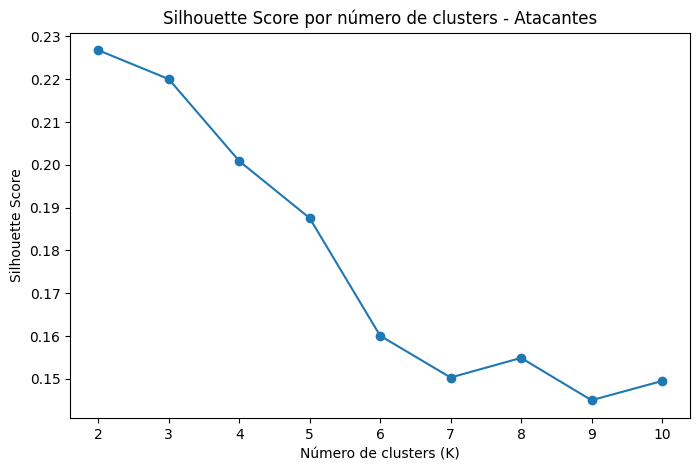

In [139]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    df_avaliacao_kmeans_fw["k"],
    df_avaliacao_kmeans_fw["silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title(
    "Silhouette Score por número de clusters - Atacantes"
)

plt.xticks(
    df_avaliacao_kmeans_fw["k"]
)

plt.show()

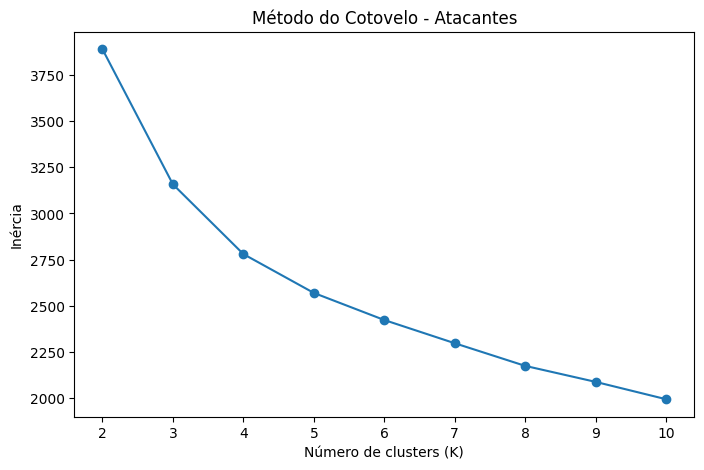

In [140]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_avaliacao_kmeans_fw["k"],
    df_avaliacao_kmeans_fw["inercia"],
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Inércia")
plt.title(
    "Método do Cotovelo - Atacantes"
)

plt.xticks(
    df_avaliacao_kmeans_fw["k"]
)

plt.show()

In [142]:
K_ESCOLHIDO_FW = 2

kmeans_fw = KMeans(
    n_clusters=K_ESCOLHIDO_FW,
    random_state=42,
    n_init=20
)

df_fw_experimento["Cluster_KMeans"] = (
    kmeans_fw.fit_predict(X_fw)
)

print(
    "Quantidade de jogadores por cluster:"
)

print(
    df_fw_experimento[
        "Cluster_KMeans"
    ].value_counts().sort_index()
)

Quantidade de jogadores por cluster:
Cluster_KMeans
0    197
1    274
Name: count, dtype: int64


In [143]:
perfil_clusters_fw = (
    df_fw_experimento
    .groupby("Cluster_KMeans")[
        features_fw
    ]
    .mean()
    .round(3)
)

perfil_clusters_fw

,Gls_90,npxG_90,Sh_90,SoT_90,SoT_pct,npxG_por_Sh,G_por_Sh,PrgR_90,PrgC_90,SCA_90,GCA_90
Cluster_KMeans,,,,,,,,,,,
0,0.463,0.384,2.705,1.115,41.839,0.146,0.178,6.894,2.349,2.974,0.410
1,0.164,0.166,1.758,0.574,32.208,0.095,0.094,6.238,2.690,3.002,0.313


In [144]:
df_fw_experimento[
    df_fw_experimento["Player"].isin(
        jogadores_teste_fw
    )
][
    [
        "Player",
        "clubes",
        "Min",
        "Cluster_KMeans"
    ]
].sort_values(
    "Cluster_KMeans"
)

,Player,clubes,Min,Cluster_KMeans
19,Chris Wood,[Nott'ham Forest],2959,0
157,Kylian Mbappé,[Real Madrid],2907,0
332,Cole Palmer,[Chelsea],3191,0
459,Lamine Yamal,[Barcelona],2856,0


In [145]:
def recomendar_kmeans_atacante(
    jogador,
    quantidade=5
):

    encontrados = df_fw_experimento[
        df_fw_experimento["Player"]
        .str.lower()
        == jogador.lower()
    ]

    if encontrados.empty:
        print(
            f"Jogador '{jogador}' não encontrado."
        )
        return None

    indice = encontrados.index[0]

    cluster_jogador = (
        df_fw_experimento.loc[
            indice,
            "Cluster_KMeans"
        ]
    )

    indices_cluster = (
        df_fw_experimento[
            df_fw_experimento[
                "Cluster_KMeans"
            ] == cluster_jogador
        ].index
    )

    indices_candidatos = [
        i
        for i in indices_cluster
        if i != indice
    ]

    distancias = np.linalg.norm(
        X_fw[indices_candidatos]
        - X_fw[indice],
        axis=1
    )

    resultado = (
        df_fw_experimento.loc[
            indices_candidatos,
            [
                "player_id_match",
                "Player",
                "clubes",
                "Min",
                "Cluster_KMeans"
            ]
        ]
        .copy()
    )

    resultado["Distancia_KMeans"] = (
        distancias
    )

    resultado = (
        resultado
        .sort_values(
            "Distancia_KMeans"
        )
        .head(quantidade)
        .reset_index(drop=True)
    )

    return resultado

In [146]:
resultados_kmeans_recomendacao_fw = {}

for jogador in jogadores_teste_fw:

    resultado = recomendar_kmeans_atacante(
        jogador,
        quantidade=5
    )

    resultados_kmeans_recomendacao_fw[
        jogador
    ] = resultado

    print(
        f"\n=== {jogador} ==="
    )

    display(resultado)


=== Kylian Mbappé ===


,player_id_match,Player,clubes,Min,Cluster_KMeans,Distancia_KMeans
0,192565,Leroy Sané,[Bayern Munich],1637,0,3.220824
1,288230,Ousmane Dembélé,[Paris S-G],1730,0,3.311032
2,398184,Ferrán Torres,[Barcelona],1106,0,3.424280
3,445939,Omar Marmoush,"[Eint Frankfurt, Manchester City]",2623,0,3.551465
4,148455,Mohamed Salah,[Liverpool],3371,0,3.748698



=== Chris Wood ===


,player_id_match,Player,clubes,Min,Cluster_KMeans,Distancia_KMeans
0,283994,Ludovic Ajorque,[Brest],2495,0,1.669692
1,429983,Jørgen Strand Larsen,[Wolves],2587,0,1.731656
2,583699,Andrej Ilic,[Union Berlin],937,0,1.881508
3,298976,Borja Mayoral,[Getafe],1114,0,2.052875
4,461607,Esteban Lepaul,[Angers],1629,0,2.105684



=== Lamine Yamal ===


,player_id_match,Player,clubes,Min,Cluster_KMeans,Distancia_KMeans
0,433177,Bukayo Saka,[Arsenal],1729,0,2.261751
1,243714,Kingsley Coman,[Bayern Munich],1282,0,2.536127
2,566723,Michael Olise,[Bayern Munich],2334,0,2.714620
3,502670,Khvicha Kvaratskhelia,"[Napoli, Paris S-G]",2094,0,2.925072
4,598577,Florian Wirtz,[Leverkusen],2351,0,3.064139



=== Cole Palmer ===


,player_id_match,Player,clubes,Min,Cluster_KMeans,Distancia_KMeans
0,517894,Matheus Cunha,[Wolves],2597,0,1.863845
1,206050,Paulo Dybala,[Roma],1417,0,1.887219
2,405885,Giacomo Raspadori,[Napoli],1103,0,2.089252
3,636703,Fermin López,[Barcelona],1252,0,2.193349
4,184892,Florian Thauvin,[Udinese],1956,0,2.422473


In [147]:
tabelas_kmeans = []

for jogador, resultado in (
    resultados_kmeans_recomendacao_fw.items()
):

    tabela = resultado.copy()

    tabela.insert(
        0,
        "Jogador_Referencia",
        jogador
    )

    tabela.insert(
        1,
        "Posicao_Ranking",
        range(
            1,
            len(tabela) + 1
        )
    )

    tabelas_kmeans.append(tabela)

df_comparacao_kmeans_fw = pd.concat(
    tabelas_kmeans,
    ignore_index=True
)

df_comparacao_kmeans_fw

,Jogador_Referencia,Posicao_Ranking,player_id_match,Player,clubes,Min,Cluster_KMeans,Distancia_KMeans
0,Kylian Mbappé,1,192565,Leroy Sané,[Bayern Munich],1637,0,3.220824
1,Kylian Mbappé,2,288230,Ousmane Dembélé,[Paris S-G],1730,0,3.311032
2,Kylian Mbappé,3,398184,Ferrán Torres,[Barcelona],1106,0,3.424280
3,Kylian Mbappé,4,445939,Omar Marmoush,"[Eint Frankfurt, Manchester City]",2623,0,3.551465
4,Kylian Mbappé,5,148455,Mohamed Salah,[Liverpool],3371,0,3.748698
5,Chris Wood,1,283994,Ludovic Ajorque,[Brest],2495,0,1.669692
6,Chris Wood,2,429983,Jørgen Strand Larsen,[Wolves],2587,0,1.731656
7,Chris Wood,3,583699,Andrej Ilic,[Union Berlin],937,0,1.881508
8,Chris Wood,4,298976,Borja Mayoral,[Getafe],1114,0,2.052875
9,Chris Wood,5,461607,Esteban Lepaul,[Angers],1629,0,2.105684


### Modelo 3 — Autoencoder

O terceiro método avaliado será o Autoencoder, uma rede neural capaz de aprender uma representação compacta dos dados sem a necessidade de uma variável-alvo.

Neste experimento, o modelo receberá as métricas de desempenho dos atacantes e será treinado para reconstruir essas mesmas informações. Durante esse processo, a camada intermediária da rede aprenderá uma representação de menor dimensionalidade do perfil dos jogadores.

Posteriormente, essa representação latente será utilizada para calcular a proximidade entre os atletas e gerar recomendações de jogadores semelhantes.

In [148]:
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)

In [149]:
indices_fw = np.arange(
    len(df_fw_experimento)
)

indices_treino_fw, indices_temp_fw = (
    train_test_split(
        indices_fw,
        test_size=0.30,
        random_state=42
    )
)

indices_validacao_fw, indices_teste_fw = (
    train_test_split(
        indices_temp_fw,
        test_size=0.50,
        random_state=42
    )
)

print(
    "Total:",
    len(indices_fw)
)

print(
    "Treino:",
    len(indices_treino_fw)
)

print(
    "Validação:",
    len(indices_validacao_fw)
)

print(
    "Teste:",
    len(indices_teste_fw)
)

Total: 471
Treino: 329
Validação: 71
Teste: 71


In [150]:
scaler_autoencoder_fw = StandardScaler()

X_fw_treino = (
    scaler_autoencoder_fw
    .fit_transform(
        df_fw_experimento.loc[
            indices_treino_fw,
            features_fw
        ]
    )
)

X_fw_validacao = (
    scaler_autoencoder_fw
    .transform(
        df_fw_experimento.loc[
            indices_validacao_fw,
            features_fw
        ]
    )
)

X_fw_teste = (
    scaler_autoencoder_fw
    .transform(
        df_fw_experimento.loc[
            indices_teste_fw,
            features_fw
        ]
    )
)

print(
    "Treino:",
    X_fw_treino.shape
)

print(
    "Validação:",
    X_fw_validacao.shape
)

print(
    "Teste:",
    X_fw_teste.shape
)

Treino: (329, 11)
Validação: (71, 11)
Teste: (71, 11)


In [151]:
numero_features_fw = len(
    features_fw
)

entrada_fw = keras.Input(
    shape=(numero_features_fw,),
    name="entrada"
)

encoder_oculta_fw = layers.Dense(
    8,
    activation="relu",
    name="encoder_oculta"
)(entrada_fw)

espaco_latente_fw = layers.Dense(
    4,
    activation="linear",
    name="espaco_latente"
)(encoder_oculta_fw)

decoder_oculta_fw = layers.Dense(
    8,
    activation="relu",
    name="decoder_oculta"
)(espaco_latente_fw)

saida_fw = layers.Dense(
    numero_features_fw,
    activation="linear",
    name="reconstrucao"
)(decoder_oculta_fw)

autoencoder_fw = keras.Model(
    entrada_fw,
    saida_fw,
    name="autoencoder_atacantes"
)

autoencoder_fw.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

autoencoder_fw.summary()

Model: "autoencoder_atacantes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_oculta (Dense)          │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ espaco_latente (Dense)          │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_oculta (Dense)          │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstrucao (Dense)            │ (None, 11)             │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271 (1.06 KB)

 Trainable params: 271 (1.06 KB)

 Non-trainable params: 0 (0.00 B)

In [152]:
early_stopping_fw = (
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )
)

In [153]:
historico_autoencoder_fw = (
    autoencoder_fw.fit(
        X_fw_treino,
        X_fw_treino,
        validation_data=(
            X_fw_validacao,
            X_fw_validacao
        ),
        epochs=200,
        batch_size=32,
        callbacks=[
            early_stopping_fw
        ],
        verbose=1
    )
)

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.9801 - val_loss: 0.8226
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.9298 - val_loss: 0.7853
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.8928 - val_loss: 0.7541
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.8616 - val_loss: 0.7266
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.8316 - val_loss: 0.7006
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8023 - val_loss: 0.6753
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7738 - val_loss: 0.6510
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7473 - val_loss: 0.6285
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7235 - val_loss: 0.6083
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7021 - val_loss: 0.5894
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6825 - val_loss: 0.5719
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

In [154]:
erro_teste_autoencoder_fw = (
    autoencoder_fw.evaluate(
        X_fw_teste,
        X_fw_teste,
        verbose=0
    )
)

print(
    "Épocas executadas:",
    len(
        historico_autoencoder_fw
        .history["loss"]
    )
)

print(
    "Loss final de treino:",
    round(
        historico_autoencoder_fw
        .history["loss"][-1],
        4
    )
)

print(
    "Melhor validation loss:",
    round(
        min(
            historico_autoencoder_fw
            .history["val_loss"]
        ),
        4
    )
)

print(
    "Erro no conjunto de teste:",
    round(
        erro_teste_autoencoder_fw,
        4
    )
)

Épocas executadas: 200
Loss final de treino: 0.1597
Melhor validation loss: 0.1579
Erro no conjunto de teste: 0.1771


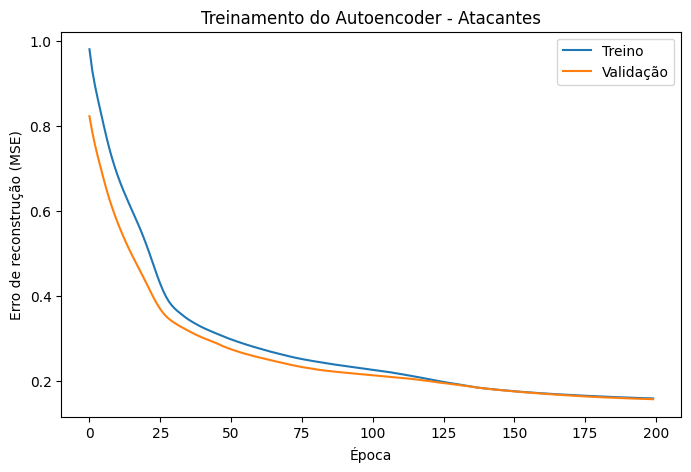

In [155]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    historico_autoencoder_fw
    .history["loss"],
    label="Treino"
)

plt.plot(
    historico_autoencoder_fw
    .history["val_loss"],
    label="Validação"
)

plt.xlabel("Época")

plt.ylabel(
    "Erro de reconstrução (MSE)"
)

plt.title(
    "Treinamento do Autoencoder - Atacantes"
)

plt.legend()

plt.show()

In [156]:
encoder_fw = keras.Model(
    inputs=autoencoder_fw.input,
    outputs=autoencoder_fw.get_layer(
        "espaco_latente"
    ).output,
    name="encoder_atacantes"
)

encoder_fw.summary()

Model: "encoder_atacantes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_oculta (Dense)          │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ espaco_latente (Dense)          │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132 (528.00 B)

 Trainable params: 132 (528.00 B)

 Non-trainable params: 0 (0.00 B)

In [157]:
X_fw_autoencoder = (
    scaler_autoencoder_fw
    .transform(
        df_fw_experimento[
            features_fw
        ]
    )
)

embeddings_fw = encoder_fw.predict(
    X_fw_autoencoder,
    verbose=0
)

print(
    "Formato dos embeddings:",
    embeddings_fw.shape
)

embeddings_fw[:5]

Formato dos embeddings: (471, 4)


array([[ 1.8154633 ,  2.5254276 , -3.0176368 , -2.6534426 ],
       [-1.3681265 , -2.7730792 , -4.062896  , -1.0745995 ],
       [ 0.7782937 ,  0.53897023, -2.1353152 , -1.2977304 ],
       [ 2.0284028 ,  0.9695473 , -3.8394575 ,  0.6058674 ],
       [ 2.399304  ,  2.6877239 , -5.7801375 ,  2.0845106 ]],
      dtype=float32)

In [158]:
scaler_latente_fw = StandardScaler()

scaler_latente_fw.fit(
    embeddings_fw[
        indices_treino_fw
    ]
)

embeddings_fw_padronizados = (
    scaler_latente_fw.transform(
        embeddings_fw
    )
)

print(
    "Formato final:",
    embeddings_fw_padronizados.shape
)

Formato final: (471, 4)


In [159]:
def recomendar_autoencoder_atacante(
    jogador,
    quantidade=5
):

    encontrados = df_fw_experimento[
        df_fw_experimento["Player"]
        .str.lower()
        == jogador.lower()
    ]

    if encontrados.empty:
        print(
            f"Jogador '{jogador}' não encontrado."
        )
        return None

    indice = encontrados.index[0]

    vetor_referencia = (
        embeddings_fw_padronizados[
            indice
        ]
    )

    distancias = np.linalg.norm(
        embeddings_fw_padronizados
        - vetor_referencia,
        axis=1
    )

    indices_ordenados = (
        np.argsort(distancias)
    )

    indices_candidatos = [
        i
        for i in indices_ordenados
        if i != indice
    ][:quantidade]

    resultado = (
        df_fw_experimento.loc[
            indices_candidatos,
            [
                "player_id_match",
                "Player",
                "clubes",
                "Min"
            ]
        ]
        .copy()
    )

    resultado[
        "Distancia_Autoencoder"
    ] = distancias[
        indices_candidatos
    ]

    resultado = (
        resultado
        .reset_index(drop=True)
    )

    return resultado

In [160]:
resultados_autoencoder_fw = {}

for jogador in jogadores_teste_fw:

    resultado = (
        recomendar_autoencoder_atacante(
            jogador,
            quantidade=5
        )
    )

    resultados_autoencoder_fw[
        jogador
    ] = resultado

    print(
        f"\n=== {jogador} ==="
    )

    display(resultado)


=== Kylian Mbappé ===


,player_id_match,Player,clubes,Min,Distancia_Autoencoder
0,192565,Leroy Sané,[Bayern Munich],1637,0.923328
1,532826,Mason Greenwood,[Marseille],2804,1.322077
2,445939,Omar Marmoush,"[Eint Frankfurt, Manchester City]",2623,1.427842
3,502670,Khvicha Kvaratskhelia,"[Napoli, Paris S-G]",2094,1.496940
4,406040,Ademola Lookman,[Atalanta],2247,1.601145



=== Chris Wood ===


,player_id_match,Player,clubes,Min,Distancia_Autoencoder
0,429983,Jørgen Strand Larsen,[Wolves],2587,0.504261
1,583699,Andrej Ilic,[Union Berlin],937,0.715293
2,343537,Artem Dovbyk,[Roma],2418,0.796435
3,292139,Sammie Szmodics,[Ipswich Town],992,0.804660
4,258889,Dominic Solanke,[Tottenham],2201,0.819665



=== Lamine Yamal ===


,player_id_match,Player,clubes,Min,Distancia_Autoencoder
0,243714,Kingsley Coman,[Bayern Munich],1282,0.649656
1,371998,Vinicius Júnior,[Real Madrid],2253,0.816594
2,406040,Ademola Lookman,[Atalanta],2247,0.936796
3,598577,Florian Wirtz,[Leverkusen],2351,1.085025
4,148455,Mohamed Salah,[Liverpool],3371,1.360974



=== Cole Palmer ===


,player_id_match,Player,clubes,Min,Distancia_Autoencoder
0,462250,João Félix,"[Chelsea, Milan]",1129,0.336473
1,636703,Fermin López,[Barcelona],1252,0.399221
2,206050,Paulo Dybala,[Roma],1417,0.571171
3,340950,Diogo Jota,[Liverpool],1196,0.745762
4,729814,Georges Mikautadze,[Lyon],1449,0.751851


In [161]:
tabelas_autoencoder = []

for jogador, resultado in (
    resultados_autoencoder_fw.items()
):

    tabela = resultado.copy()

    tabela.insert(
        0,
        "Jogador_Referencia",
        jogador
    )

    tabela.insert(
        1,
        "Posicao_Ranking",
        range(
            1,
            len(tabela) + 1
        )
    )

    tabelas_autoencoder.append(
        tabela
    )

df_comparacao_autoencoder_fw = (
    pd.concat(
        tabelas_autoencoder,
        ignore_index=True
    )
)

df_comparacao_autoencoder_fw

,Jogador_Referencia,Posicao_Ranking,player_id_match,Player,clubes,Min,Distancia_Autoencoder
0,Kylian Mbappé,1,192565,Leroy Sané,[Bayern Munich],1637,0.923328
1,Kylian Mbappé,2,532826,Mason Greenwood,[Marseille],2804,1.322077
2,Kylian Mbappé,3,445939,Omar Marmoush,"[Eint Frankfurt, Manchester City]",2623,1.427842
3,Kylian Mbappé,4,502670,Khvicha Kvaratskhelia,"[Napoli, Paris S-G]",2094,1.496940
4,Kylian Mbappé,5,406040,Ademola Lookman,[Atalanta],2247,1.601145
5,Chris Wood,1,429983,Jørgen Strand Larsen,[Wolves],2587,0.504261
6,Chris Wood,2,583699,Andrej Ilic,[Union Berlin],937,0.715293
7,Chris Wood,3,343537,Artem Dovbyk,[Roma],2418,0.796435
8,Chris Wood,4,292139,Sammie Szmodics,[Ipswich Town],992,0.804660
9,Chris Wood,5,258889,Dominic Solanke,[Tottenham],2201,0.819665


### Avaliação comparativa dos modelos

Após a execução dos três métodos, os resultados serão avaliados utilizando critérios comuns.

Além da análise dos jogadores recomendados, será utilizada a subposição registrada no Transfermarkt como uma informação externa de validação. Essa variável não foi utilizada durante o treinamento ou cálculo de similaridade dos modelos.

Dessa forma, será analisada a capacidade de cada método de recomendar jogadores que desempenham funções específicas semelhantes à do atleta utilizado como referência.

In [162]:
informacoes_posicao_tm = (
    df_mercado[
        [
            "player_id",
            "position",
            "sub_position"
        ]
    ]
    .drop_duplicates(
        subset=["player_id"]
    )
    .set_index("player_id")
)

df_fw_experimento["position_tm"] = (
    df_fw_experimento[
        "player_id_match"
    ].map(
        informacoes_posicao_tm[
            "position"
        ]
    )
)

df_fw_experimento["sub_position_tm"] = (
    df_fw_experimento[
        "player_id_match"
    ].map(
        informacoes_posicao_tm[
            "sub_position"
        ]
    )
)

In [163]:
df_fw_experimento[
    "posicao_tm_compativel"
] = (
    df_fw_experimento.apply(
        lambda linha:
            linha["position_tm"]
            in posicoes_tm_aceitas(
                ",".join(
                    linha[
                        "posicoes_modelo"
                    ]
                )
            ),
        axis=1
    )
)

print(
    "Jogadores analisados:",
    len(df_fw_experimento)
)

print(
    "Posição compatível:",
    df_fw_experimento[
        "posicao_tm_compativel"
    ].sum()
)

print(
    "Posição incompatível:",
    (
        ~df_fw_experimento[
            "posicao_tm_compativel"
        ]
    ).sum()
)

print(
    "\nSubposições disponíveis:",
    df_fw_experimento[
        "sub_position_tm"
    ].notna().sum()
)

Jogadores analisados: 471
Posição compatível: 462
Posição incompatível: 9

Subposições disponíveis: 471


In [164]:
df_fw_experimento[
    "sub_position_tm"
].value_counts(
    dropna=False
)

,count
sub_position_tm,
Centre-Forward,164
Right Winger,94
Left Winger,92
Attacking Midfield,51
Central Midfield,27
Second Striker,13
Left-Back,9
Right-Back,8
Right Midfield,8


In [165]:
def top5_knn_por_indice(
    indice,
    quantidade=5
):

    distancias, indices = (
        knn_fw.kneighbors(
            X_fw[indice]
            .reshape(1, -1),
            n_neighbors=quantidade + 1
        )
    )

    return [
        i
        for i in indices[0]
        if i != indice
    ][:quantidade]

In [166]:
def top5_kmeans_por_indice(
    indice,
    quantidade=5
):

    cluster = (
        df_fw_experimento.loc[
            indice,
            "Cluster_KMeans"
        ]
    )

    candidatos = (
        df_fw_experimento[
            df_fw_experimento[
                "Cluster_KMeans"
            ] == cluster
        ].index
    )

    candidatos = [
        i
        for i in candidatos
        if i != indice
    ]

    distancias = np.linalg.norm(
        X_fw[candidatos]
        - X_fw[indice],
        axis=1
    )

    ordem = np.argsort(
        distancias
    )[:quantidade]

    return [
        candidatos[i]
        for i in ordem
    ]

In [167]:
def top5_autoencoder_por_indice(
    indice,
    quantidade=5
):

    distancias = np.linalg.norm(
        embeddings_fw_padronizados
        - embeddings_fw_padronizados[
            indice
        ],
        axis=1
    )

    ordem = np.argsort(
        distancias
    )

    return [
        i
        for i in ordem
        if i != indice
    ][:quantidade]

In [168]:
modelos_avaliacao_fw = {
    "KNN":
        top5_knn_por_indice,

    "K-Means":
        top5_kmeans_por_indice,

    "Autoencoder":
        top5_autoencoder_por_indice
}

registros_avaliacao_fw = []

for indice, jogador in (
    df_fw_experimento.iterrows()
):

    subposicao_referencia = (
        jogador["sub_position_tm"]
    )

    if pd.isna(
        subposicao_referencia
    ):
        continue

    for (
        nome_modelo,
        funcao_modelo
    ) in modelos_avaliacao_fw.items():

        recomendacoes = (
            funcao_modelo(
                indice,
                quantidade=5
            )
        )

        for ranking, indice_rec in enumerate(
            recomendacoes,
            start=1
        ):

            subposicao_rec = (
                df_fw_experimento.loc[
                    indice_rec,
                    "sub_position_tm"
                ]
            )

            if pd.isna(
                subposicao_rec
            ):
                continue

            registros_avaliacao_fw.append({
                "Modelo":
                    nome_modelo,

                "Indice_Referencia":
                    indice,

                "Jogador_Referencia":
                    jogador["Player"],

                "Subposicao_Referencia":
                    subposicao_referencia,

                "Jogador_Recomendado":
                    df_fw_experimento.loc[
                        indice_rec,
                        "Player"
                    ],

                "Subposicao_Recomendada":
                    subposicao_rec,

                "Ranking":
                    ranking,

                "Mesma_Subposicao":
                    (
                        subposicao_referencia
                        == subposicao_rec
                    )
            })

df_avaliacao_modelos_fw = (
    pd.DataFrame(
        registros_avaliacao_fw
    )
)

df_avaliacao_modelos_fw.head()

,Modelo,Indice_Referencia,Jogador_Referencia,Subposicao_Referencia,Jogador_Recomendado,Subposicao_Recomendada,Ranking,Mesma_Subposicao
0,KNN,0,Robert Lewandowski,Centre-Forward,Patrik Schick,Centre-Forward,1,True
1,KNN,0,Robert Lewandowski,Centre-Forward,Serhou Guirassy,Centre-Forward,2,True
2,KNN,0,Robert Lewandowski,Centre-Forward,Ermedin Demirović,Centre-Forward,3,True
3,KNN,0,Robert Lewandowski,Centre-Forward,Moise Kean,Centre-Forward,4,True
4,KNN,0,Robert Lewandowski,Centre-Forward,Jonathan Burkardt,Centre-Forward,5,True


In [169]:
resumo_avaliacao_modelos_fw = (
    df_avaliacao_modelos_fw
    .groupby("Modelo")
    .agg(
        Jogadores_Avaliados=(
            "Indice_Referencia",
            "nunique"
        ),
        Recomendacoes_Avaliadas=(
            "Mesma_Subposicao",
            "size"
        ),
        Mesma_Subposicao=(
            "Mesma_Subposicao",
            "sum"
        )
    )
)

resumo_avaliacao_modelos_fw[
    "Taxa_Mesma_Subposicao"
] = (
    resumo_avaliacao_modelos_fw[
        "Mesma_Subposicao"
    ]
    /
    resumo_avaliacao_modelos_fw[
        "Recomendacoes_Avaliadas"
    ]
    * 100
).round(2)

resumo_avaliacao_modelos_fw

,Jogadores_Avaliados,Recomendacoes_Avaliadas,Mesma_Subposicao,Taxa_Mesma_Subposicao
Modelo,,,,
Autoencoder,471,2355,953,40.47
K-Means,471,2355,972,41.27
KNN,471,2355,977,41.49


In [170]:
df_fw_experimento[
    ~df_fw_experimento[
        "posicao_tm_compativel"
    ]
][
    [
        "player_id_match",
        "Player",
        "clubes",
        "posicoes_modelo",
        "position_tm",
        "sub_position_tm"
    ]
]

,player_id_match,Player,clubes,posicoes_modelo,position_tm,sub_position_tm
45,186368,Valentino Lazaro,[Torino],"[DF, FW]",Midfield,Right Midfield
69,241076,Emmanuel Gyasi,[Empoli],"[DF, FW]",Midfield,Right Midfield
81,255731,Wes Burns,[Ipswich Town],"[DF, FW]",Midfield,Right Midfield
188,370846,Timothy Weah,[Juventus],"[DF, FW]",Midfield,Right Midfield
192,381950,Alexis Saelemaekers,"[Milan, Roma]","[DF, FW]",Midfield,Right Midfield
239,433584,Alessio Zerbin,"[Napoli, Venezia]","[DF, FW]",Midfield,Right Midfield
327,560483,Randy Nteka,[Rayo Vallecano],[FW],Midfield,Attacking Midfield
379,644401,Keane Lewis-Potter,[Brentford],"[DF, FW]",Midfield,Left Midfield
402,691316,Luis Henrique,[Marseille],"[DF, FW]",Midfield,Right Midfield


In [171]:
distribuicao_subposicoes = (
    df_fw_experimento[
        "sub_position_tm"
    ]
    .value_counts(
        normalize=True
    )
)

taxa_aleatoria_subposicao = (
    distribuicao_subposicoes
    .pow(2)
    .sum()
    * 100
)

print(
    "Taxa esperada por acaso:",
    f"{taxa_aleatoria_subposicao:.2f}%"
)

Taxa esperada por acaso: 21.60%


In [172]:
avaliacao_por_jogador_fw = (
    df_avaliacao_modelos_fw
    .groupby(
        [
            "Modelo",
            "Indice_Referencia",
            "Jogador_Referencia"
        ]
    )
    .agg(
        Precisao_5=(
            "Mesma_Subposicao",
            "mean"
        ),
        Acerto_Top1=(
            "Mesma_Subposicao",
            "first"
        )
    )
    .reset_index()
)

avaliacao_por_jogador_fw[
    "Precisao_5"
] *= 100

avaliacao_por_jogador_fw.head()

,Modelo,Indice_Referencia,Jogador_Referencia,Precisao_5,Acerto_Top1
0,Autoencoder,0,Robert Lewandowski,100.0,True
1,Autoencoder,1,André Ayew,60.0,True
2,Autoencoder,2,Ante Budimir,100.0,True
3,Autoencoder,3,Andrej Kramarić,20.0,False
4,Autoencoder,4,Thomas Müller,0.0,False


In [173]:
resumo_complementar_fw = (
    avaliacao_por_jogador_fw
    .groupby("Modelo")
    .agg(
        Precisao_Media_Top5=(
            "Precisao_5",
            "mean"
        ),
        Taxa_Acerto_Top1=(
            "Acerto_Top1",
            "mean"
        )
    )
)

resumo_complementar_fw[
    "Taxa_Acerto_Top1"
] *= 100

resumo_complementar_fw = (
    resumo_complementar_fw
    .round(2)
)

resumo_complementar_fw

,Precisao_Media_Top5,Taxa_Acerto_Top1
Modelo,,
Autoencoder,40.47,44.16
K-Means,41.27,40.76
KNN,41.49,41.83


### Análise da estabilidade dos resultados

Como os modelos apresentaram resultados próximos, será utilizada uma análise por reamostragem bootstrap para estimar a estabilidade das diferenças observadas.

O procedimento permite calcular intervalos de confiança para a diferença de desempenho entre os métodos utilizando os mesmos jogadores de referência, evitando que pequenas variações percentuais sejam interpretadas diretamente como superioridade de um modelo.

In [174]:
comparacao_precisao_fw = (
    avaliacao_por_jogador_fw
    .pivot(
        index="Indice_Referencia",
        columns="Modelo",
        values="Precisao_5"
    )
)

comparacao_top1_fw = (
    avaliacao_por_jogador_fw
    .pivot(
        index="Indice_Referencia",
        columns="Modelo",
        values="Acerto_Top1"
    )
    .astype(int)
)

comparacao_precisao_fw.head()

Modelo,Autoencoder,K-Means,KNN
Indice_Referencia,,,
0,100.0,100.0,100.0
1,60.0,80.0,80.0
2,100.0,100.0,100.0
3,20.0,0.0,20.0
4,0.0,0.0,0.0


In [175]:
def bootstrap_diferenca(
    serie_a,
    serie_b,
    repeticoes=10000,
    seed=42
):

    a = np.asarray(
        serie_a,
        dtype=float
    )

    b = np.asarray(
        serie_b,
        dtype=float
    )

    rng = np.random.default_rng(
        seed
    )

    diferencas = []

    n = len(a)

    for _ in range(repeticoes):

        indices = rng.integers(
            0,
            n,
            size=n
        )

        diferencas.append(
            (
                a[indices]
                - b[indices]
            ).mean()
        )

    diferencas = np.array(
        diferencas
    )

    return {
        "Diferenca_Media":
            (a - b).mean(),

        "IC_95_Inferior":
            np.percentile(
                diferencas,
                2.5
            ),

        "IC_95_Superior":
            np.percentile(
                diferencas,
                97.5
            )
    }

In [176]:
pares_modelos = [
    ("KNN", "K-Means"),
    ("KNN", "Autoencoder"),
    ("Autoencoder", "K-Means")
]

resultados_bootstrap_top5 = []

for modelo_a, modelo_b in pares_modelos:

    resultado = bootstrap_diferenca(
        comparacao_precisao_fw[
            modelo_a
        ],
        comparacao_precisao_fw[
            modelo_b
        ]
    )

    resultados_bootstrap_top5.append({
        "Modelo_A": modelo_a,
        "Modelo_B": modelo_b,
        **resultado
    })

df_bootstrap_top5_fw = pd.DataFrame(
    resultados_bootstrap_top5
)

df_bootstrap_top5_fw.round(2)

,Modelo_A,Modelo_B,Diferenca_Media,IC_95_Inferior,IC_95_Superior
0,KNN,K-Means,0.21,-0.42,0.85
1,KNN,Autoencoder,1.02,-0.89,2.93
2,Autoencoder,K-Means,-0.81,-2.72,1.11


In [178]:
resultados_bootstrap_top1 = []

for modelo_a, modelo_b in pares_modelos:

    resultado = bootstrap_diferenca(
        comparacao_top1_fw[
            modelo_a
        ],
        comparacao_top1_fw[
            modelo_b
        ]
    )

    resultados_bootstrap_top1.append({
        "Modelo_A": modelo_a,
        "Modelo_B": modelo_b,
        **resultado
    })

df_bootstrap_top1_fw = pd.DataFrame(
    resultados_bootstrap_top1
)

df_bootstrap_top1_fw[
    [
        "Diferenca_Media",
        "IC_95_Inferior",
        "IC_95_Superior"
    ]
] *= 100

df_bootstrap_top1_fw.round(2)

,Modelo_A,Modelo_B,Diferenca_Media,IC_95_Inferior,IC_95_Superior
0,KNN,K-Means,1.06,-0.42,2.76
1,KNN,Autoencoder,-2.34,-7.01,2.34
2,Autoencoder,K-Means,3.40,-1.27,8.07


## 10. Repetição do experimento nas demais posições

Após a avaliação inicial realizada com os atacantes, o mesmo procedimento será aplicado aos meio-campistas, defensores e goleiros.

Para garantir uma comparação consistente, cada grupo utilizará suas respectivas variáveis de desempenho, mantendo os mesmos procedimentos de padronização, treinamento e avaliação dos modelos KNN, K-Means e Autoencoder.

In [179]:
def preparar_experimento_posicao(
    dataframe,
    features
):

    df_exp = (
        dataframe
        .reset_index(drop=True)
        .copy()
    )

    df_exp["position_tm"] = (
        df_exp["player_id_match"]
        .map(
            informacoes_posicao_tm[
                "position"
            ]
        )
    )

    df_exp["sub_position_tm"] = (
        df_exp["player_id_match"]
        .map(
            informacoes_posicao_tm[
                "sub_position"
            ]
        )
    )

    scaler_baseline = StandardScaler()

    X = scaler_baseline.fit_transform(
        df_exp[features]
    )

    return (
        df_exp,
        X,
        scaler_baseline
    )

In [180]:
def treinar_modelos_posicao(
    dataframe,
    features,
    dimensao_latente,
    neuronios_ocultos,
    nome_posicao
):

    df_exp, X, scaler_baseline = (
        preparar_experimento_posicao(
            dataframe,
            features
        )
    )

    # -------------------------
    # KNN
    # -------------------------

    knn = NearestNeighbors(
        n_neighbors=6,
        metric="euclidean"
    )

    knn.fit(X)


    # -------------------------
    # K-MEANS
    # -------------------------

    resultados_k = []

    for k in range(2, 11):

        modelo_k = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )

        grupos = modelo_k.fit_predict(
            X
        )

        resultados_k.append({
            "k": k,
            "silhouette":
                silhouette_score(
                    X,
                    grupos
                ),
            "inercia":
                modelo_k.inertia_
        })

    df_k = pd.DataFrame(
        resultados_k
    )

    melhor_k = int(
        df_k.loc[
            df_k["silhouette"].idxmax(),
            "k"
        ]
    )

    kmeans = KMeans(
        n_clusters=melhor_k,
        random_state=42,
        n_init=20
    )

    clusters = kmeans.fit_predict(
        X
    )

    df_exp["Cluster_KMeans"] = (
        clusters
    )


    # -------------------------
    # AUTOENCODER
    # -------------------------

    indices = np.arange(
        len(df_exp)
    )

    indices_treino, indices_temp = (
        train_test_split(
            indices,
            test_size=0.30,
            random_state=42
        )
    )

    (
        indices_validacao,
        indices_teste
    ) = train_test_split(
        indices_temp,
        test_size=0.50,
        random_state=42
    )

    scaler_ae = StandardScaler()

    X_treino = scaler_ae.fit_transform(
        df_exp.loc[
            indices_treino,
            features
        ]
    )

    X_validacao = scaler_ae.transform(
        df_exp.loc[
            indices_validacao,
            features
        ]
    )

    X_teste = scaler_ae.transform(
        df_exp.loc[
            indices_teste,
            features
        ]
    )

    tf.keras.utils.set_random_seed(
        42
    )

    entrada = keras.Input(
        shape=(len(features),)
    )

    x = layers.Dense(
        neuronios_ocultos,
        activation="relu"
    )(entrada)

    espaco_latente = layers.Dense(
        dimensao_latente,
        activation="linear",
        name=f"latente_{nome_posicao}"
    )(x)

    x = layers.Dense(
        neuronios_ocultos,
        activation="relu"
    )(espaco_latente)

    saida = layers.Dense(
        len(features),
        activation="linear"
    )(x)

    autoencoder = keras.Model(
        entrada,
        saida
    )

    autoencoder.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse"
    )

    early_stopping = (
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )
    )

    historico = autoencoder.fit(
        X_treino,
        X_treino,
        validation_data=(
            X_validacao,
            X_validacao
        ),
        epochs=200,
        batch_size=32,
        callbacks=[
            early_stopping
        ],
        verbose=0
    )

    erro_teste = (
        autoencoder.evaluate(
            X_teste,
            X_teste,
            verbose=0
        )
    )

    encoder = keras.Model(
        autoencoder.input,
        autoencoder.get_layer(
            f"latente_{nome_posicao}"
        ).output
    )

    X_autoencoder = (
        scaler_ae.transform(
            df_exp[features]
        )
    )

    embeddings = encoder.predict(
        X_autoencoder,
        verbose=0
    )

    scaler_latente = StandardScaler()

    scaler_latente.fit(
        embeddings[
            indices_treino
        ]
    )

    embeddings_padronizados = (
        scaler_latente.transform(
            embeddings
        )
    )

    return {
        "df": df_exp,
        "features": features,
        "X": X,
        "knn": knn,
        "kmeans": kmeans,
        "melhor_k": melhor_k,
        "avaliacao_kmeans": df_k,
        "autoencoder": autoencoder,
        "historico": historico,
        "erro_teste": erro_teste,
        "embeddings":
            embeddings_padronizados,
        "indices_treino":
            indices_treino,
        "indices_validacao":
            indices_validacao,
        "indices_teste":
            indices_teste
    }

In [181]:
def avaliar_modelos_posicao(
    resultado,
    quantidade=5
):

    df_exp = resultado["df"]
    X = resultado["X"]
    knn = resultado["knn"]
    embeddings = resultado[
        "embeddings"
    ]

    registros = []

    for indice, jogador in (
        df_exp.iterrows()
    ):

        subposicao_ref = (
            jogador[
                "sub_position_tm"
            ]
        )

        if pd.isna(
            subposicao_ref
        ):
            continue


        # =====================
        # KNN
        # =====================

        _, indices_knn = (
            knn.kneighbors(
                X[indice].reshape(
                    1,
                    -1
                ),
                n_neighbors=
                    quantidade + 1
            )
        )

        recomendacoes_knn = [
            i
            for i in indices_knn[0]
            if i != indice
        ][:quantidade]


        # =====================
        # K-MEANS
        # =====================

        cluster = (
            df_exp.loc[
                indice,
                "Cluster_KMeans"
            ]
        )

        candidatos = (
            df_exp[
                df_exp[
                    "Cluster_KMeans"
                ] == cluster
            ].index
        )

        candidatos = [
            i
            for i in candidatos
            if i != indice
        ]

        distancias_cluster = (
            np.linalg.norm(
                X[candidatos]
                - X[indice],
                axis=1
            )
        )

        ordem_cluster = (
            np.argsort(
                distancias_cluster
            )[:quantidade]
        )

        recomendacoes_kmeans = [
            candidatos[i]
            for i in ordem_cluster
        ]


        # =====================
        # AUTOENCODER
        # =====================

        distancias_ae = (
            np.linalg.norm(
                embeddings
                - embeddings[indice],
                axis=1
            )
        )

        ordem_ae = np.argsort(
            distancias_ae
        )

        recomendacoes_ae = [
            i
            for i in ordem_ae
            if i != indice
        ][:quantidade]


        modelos = {
            "KNN":
                recomendacoes_knn,

            "K-Means":
                recomendacoes_kmeans,

            "Autoencoder":
                recomendacoes_ae
        }


        for modelo, recomendacoes in (
            modelos.items()
        ):

            for ranking, indice_rec in (
                enumerate(
                    recomendacoes,
                    start=1
                )
            ):

                subposicao_rec = (
                    df_exp.loc[
                        indice_rec,
                        "sub_position_tm"
                    ]
                )

                if pd.isna(
                    subposicao_rec
                ):
                    continue

                registros.append({
                    "Modelo":
                        modelo,

                    "Indice_Referencia":
                        indice,

                    "Jogador_Referencia":
                        jogador["Player"],

                    "Subposicao_Referencia":
                        subposicao_ref,

                    "Jogador_Recomendado":
                        df_exp.loc[
                            indice_rec,
                            "Player"
                        ],

                    "Subposicao_Recomendada":
                        subposicao_rec,

                    "Ranking":
                        ranking,

                    "Mesma_Subposicao":
                        (
                            subposicao_ref
                            == subposicao_rec
                        )
                })

    return pd.DataFrame(
        registros
    )

In [182]:
resultado_mf = (
    treinar_modelos_posicao(
        dataframe=df_mf,
        features=features_mf,
        dimensao_latente=5,
        neuronios_ocultos=10,
        nome_posicao="mf"
    )
)

In [184]:
print(
    "Jogadores:",
    len(
        resultado_mf["df"]
    )
)

print(
    "Melhor K do K-Means:",
    resultado_mf["melhor_k"]
)

print(
    "Melhor Silhouette:",
    round(
        resultado_mf[
            "avaliacao_kmeans"
        ]["silhouette"].max(),
        4
    )
)

print(
    "Épocas do Autoencoder:",
    len(
        resultado_mf[
            "historico"
        ].history["loss"]
    )
)

print(
    "Melhor validation loss:",
    round(
        min(
            resultado_mf[
                "historico"
            ].history["val_loss"]
        ),
        4
    )
)

print(
    "Erro de teste:",
    round(
        resultado_mf[
            "erro_teste"
        ],
        4
    )
)

Jogadores: 696
Melhor K do K-Means: 2
Melhor Silhouette: 0.2791
Épocas do Autoencoder: 200
Melhor validation loss: 0.1559
Erro de teste: 0.1685


In [185]:
df_avaliacao_mf = (
    avaliar_modelos_posicao(
        resultado_mf
    )
)

In [186]:
resumo_mf = (
    df_avaliacao_mf
    .groupby("Modelo")
    .agg(
        Jogadores_Avaliados=(
            "Indice_Referencia",
            "nunique"
        ),
        Recomendacoes=(
            "Mesma_Subposicao",
            "size"
        ),
        Mesma_Subposicao=(
            "Mesma_Subposicao",
            "sum"
        )
    )
)

resumo_mf[
    "Taxa_Mesma_Subposicao"
] = (
    resumo_mf[
        "Mesma_Subposicao"
    ]
    /
    resumo_mf[
        "Recomendacoes"
    ]
    * 100
).round(2)

resumo_mf

,Jogadores_Avaliados,Recomendacoes,Mesma_Subposicao,Taxa_Mesma_Subposicao
Modelo,,,,
Autoencoder,696,3480,1269,36.47
K-Means,696,3480,1357,38.99
KNN,696,3480,1355,38.94


In [187]:
def analisar_resultados_posicao(
    df_avaliacao,
    df_experimento
):

    distribuicao = (
        df_experimento[
            "sub_position_tm"
        ]
        .dropna()
        .value_counts(
            normalize=True
        )
    )

    taxa_aleatoria = (
        distribuicao.pow(2).sum()
        * 100
    )

    avaliacao_por_jogador = (
        df_avaliacao
        .groupby(
            [
                "Modelo",
                "Indice_Referencia",
                "Jogador_Referencia"
            ]
        )
        .agg(
            Precisao_5=(
                "Mesma_Subposicao",
                "mean"
            ),
            Acerto_Top1=(
                "Mesma_Subposicao",
                "first"
            )
        )
        .reset_index()
    )

    avaliacao_por_jogador[
        "Precisao_5"
    ] *= 100

    resumo = (
        avaliacao_por_jogador
        .groupby("Modelo")
        .agg(
            Precisao_Media_Top5=(
                "Precisao_5",
                "mean"
            ),
            Taxa_Acerto_Top1=(
                "Acerto_Top1",
                "mean"
            )
        )
    )

    resumo[
        "Taxa_Acerto_Top1"
    ] *= 100

    comparacao_top5 = (
        avaliacao_por_jogador
        .pivot(
            index="Indice_Referencia",
            columns="Modelo",
            values="Precisao_5"
        )
    )

    comparacao_top1 = (
        avaliacao_por_jogador
        .pivot(
            index="Indice_Referencia",
            columns="Modelo",
            values="Acerto_Top1"
        )
        .astype(int)
    )


    bootstrap_top5 = []

    for modelo_a, modelo_b in pares_modelos:

        resultado = bootstrap_diferenca(
            comparacao_top5[modelo_a],
            comparacao_top5[modelo_b]
        )

        bootstrap_top5.append({
            "Modelo_A": modelo_a,
            "Modelo_B": modelo_b,
            **resultado
        })

    bootstrap_top1 = []

    for modelo_a, modelo_b in pares_modelos:

        resultado = bootstrap_diferenca(
            comparacao_top1[modelo_a],
            comparacao_top1[modelo_b]
        )

        bootstrap_top1.append({
            "Modelo_A": modelo_a,
            "Modelo_B": modelo_b,
            **resultado
        })

    df_bootstrap_top1 = pd.DataFrame(
        bootstrap_top1
    )

    df_bootstrap_top1[
        [
            "Diferenca_Media",
            "IC_95_Inferior",
            "IC_95_Superior"
        ]
    ] *= 100


    return {
        "taxa_aleatoria":
            taxa_aleatoria,

        "avaliacao_por_jogador":
            avaliacao_por_jogador,

        "resumo":
            resumo.round(2),

        "bootstrap_top5":
            pd.DataFrame(
                bootstrap_top5
            ).round(2),

        "bootstrap_top1":
            df_bootstrap_top1.round(2)
    }

In [188]:
analise_mf = analisar_resultados_posicao(
    df_avaliacao_mf,
    resultado_mf["df"]
)

print(
    "Taxa esperada por acaso:",
    f"{analise_mf['taxa_aleatoria']:.2f}%"
)

print(
    "\n--- RESULTADO GERAL ---"
)

display(
    analise_mf["resumo"]
)

print(
    "\n--- BOOTSTRAP TOP-5 ---"
)

display(
    analise_mf["bootstrap_top5"]
)

print(
    "\n--- BOOTSTRAP TOP-1 ---"
)

display(
    analise_mf["bootstrap_top1"]
)

Taxa esperada por acaso: 16.85%

--- RESULTADO GERAL ---


,Precisao_Media_Top5,Taxa_Acerto_Top1
Modelo,,
Autoencoder,36.47,37.93
K-Means,38.99,41.81
KNN,38.94,41.81



--- BOOTSTRAP TOP-5 ---


,Modelo_A,Modelo_B,Diferenca_Media,IC_95_Inferior,IC_95_Superior
0,KNN,K-Means,-0.06,-0.60,0.52
1,KNN,Autoencoder,2.47,0.75,4.20
2,Autoencoder,K-Means,-2.53,-4.28,-0.78



--- BOOTSTRAP TOP-1 ---


,Modelo_A,Modelo_B,Diferenca_Media,IC_95_Inferior,IC_95_Superior
0,KNN,K-Means,0.00,-1.15,1.15
1,KNN,Autoencoder,3.88,-0.29,8.05
2,Autoencoder,K-Means,-3.88,-8.05,0.29


In [189]:
resultado_df = (
    treinar_modelos_posicao(
        dataframe=df_df,
        features=features_df,
        dimensao_latente=4,
        neuronios_ocultos=8,
        nome_posicao="df"
    )
)

In [190]:
print(
    "Jogadores:",
    len(
        resultado_df["df"]
    )
)

print(
    "Melhor K do K-Means:",
    resultado_df["melhor_k"]
)

print(
    "Melhor Silhouette:",
    round(
        resultado_df[
            "avaliacao_kmeans"
        ]["silhouette"].max(),
        4
    )
)

print(
    "Épocas do Autoencoder:",
    len(
        resultado_df[
            "historico"
        ].history["loss"]
    )
)

print(
    "Melhor validation loss:",
    round(
        min(
            resultado_df[
                "historico"
            ].history["val_loss"]
        ),
        4
    )
)

print(
    "Erro de teste:",
    round(
        resultado_df[
            "erro_teste"
        ],
        4
    )
)

Jogadores: 638
Melhor K do K-Means: 2
Melhor Silhouette: 0.2327
Épocas do Autoencoder: 200
Melhor validation loss: 0.3317
Erro de teste: 0.3057


In [191]:
df_avaliacao_df = (
    avaliar_modelos_posicao(
        resultado_df
    )
)

In [192]:
analise_df = (
    analisar_resultados_posicao(
        df_avaliacao_df,
        resultado_df["df"]
    )
)

print(
    "Taxa esperada por acaso:",
    f"{analise_df['taxa_aleatoria']:.2f}%"
)

print(
    "\n--- RESULTADO GERAL ---"
)

display(
    analise_df["resumo"]
)

print(
    "\n--- BOOTSTRAP TOP-5 ---"
)

display(
    analise_df["bootstrap_top5"]
)

print(
    "\n--- BOOTSTRAP TOP-1 ---"
)

display(
    analise_df["bootstrap_top1"]
)

Taxa esperada por acaso: 32.40%

--- RESULTADO GERAL ---


,Precisao_Media_Top5,Taxa_Acerto_Top1
Modelo,,
Autoencoder,58.65,58.78
K-Means,62.63,61.91
KNN,62.13,60.66



--- BOOTSTRAP TOP-5 ---


,Modelo_A,Modelo_B,Diferenca_Media,IC_95_Inferior,IC_95_Superior
0,KNN,K-Means,-0.50,-1.32,0.28
1,KNN,Autoencoder,3.48,1.85,5.11
2,Autoencoder,K-Means,-3.98,-5.67,-2.32



--- BOOTSTRAP TOP-1 ---


,Modelo_A,Modelo_B,Diferenca_Media,IC_95_Inferior,IC_95_Superior
0,KNN,K-Means,-1.25,-2.35,-0.31
1,KNN,Autoencoder,1.88,-1.57,5.49
2,Autoencoder,K-Means,-3.13,-6.74,0.47


In [193]:
resultado_gk = (
    treinar_modelos_posicao(
        dataframe=df_gk,
        features=features_gk,
        dimensao_latente=3,
        neuronios_ocultos=6,
        nome_posicao="gk"
    )
)

In [195]:
print(
    "Jogadores:",
    len(resultado_gk["df"])
)

print(
    "Melhor K do K-Means:",
    resultado_gk["melhor_k"]
)

print(
    "Melhor Silhouette:",
    round(
        resultado_gk[
            "avaliacao_kmeans"
        ]["silhouette"].max(),
        4
    )
)

print(
    "Épocas do Autoencoder:",
    len(
        resultado_gk[
            "historico"
        ].history["loss"]
    )
)

print(
    "Melhor validation loss:",
    round(
        min(
            resultado_gk[
                "historico"
            ].history["val_loss"]
        ),
        4
    )
)

print(
    "Erro de teste:",
    round(
        resultado_gk[
            "erro_teste"
        ],
        4
    )
)

Jogadores: 114
Melhor K do K-Means: 2
Melhor Silhouette: 0.2326
Épocas do Autoencoder: 200
Melhor validation loss: 0.5728
Erro de teste: 0.731


In [196]:
resultado_gk["df"][
    "sub_position_tm"
].value_counts(
    dropna=False
)

,count
sub_position_tm,
Goalkeeper,114


In [197]:
resultado_gk["df"][
    "Cluster_KMeans"
].value_counts().sort_index()

,count
Cluster_KMeans,
0,65
1,49


## 11. Comparação geral dos modelos

Como os goleiros possuem uma única subposição na base de mercado, a correspondência de subposição não permite diferenciar os modelos nesse grupo.

Dessa forma, a comparação quantitativa entre KNN, K-Means e Autoencoder será realizada utilizando atacantes, meio-campistas e defensores, grupos nos quais existem diferentes funções específicas. Os goleiros permanecerão contemplados pelo sistema, utilizando posteriormente o método selecionado a partir da análise geral.

In [198]:
df_avaliacao_fw_geral = (
    df_avaliacao_modelos_fw
    .copy()
)

df_avaliacao_fw_geral[
    "Posicao"
] = "FW"

df_avaliacao_mf_geral = (
    df_avaliacao_mf
    .copy()
)

df_avaliacao_mf_geral[
    "Posicao"
] = "MF"

df_avaliacao_df_geral = (
    df_avaliacao_df
    .copy()
)

df_avaliacao_df_geral[
    "Posicao"
] = "DF"

df_avaliacao_geral = pd.concat(
    [
        df_avaliacao_fw_geral,
        df_avaliacao_mf_geral,
        df_avaliacao_df_geral
    ],
    ignore_index=True
)

print(
    "Total de recomendações avaliadas:",
    len(df_avaliacao_geral)
)

Total de recomendações avaliadas: 27075


In [199]:
resumo_geral_modelos = (
    df_avaliacao_geral
    .groupby("Modelo")
    .agg(
        Jogadores_Avaliados=(
            "Jogador_Referencia",
            "count"
        ),
        Recomendacoes=(
            "Mesma_Subposicao",
            "size"
        ),
        Mesma_Subposicao=(
            "Mesma_Subposicao",
            "sum"
        )
    )
)

resumo_geral_modelos[
    "Taxa_Mesma_Subposicao"
] = (
    resumo_geral_modelos[
        "Mesma_Subposicao"
    ]
    /
    resumo_geral_modelos[
        "Recomendacoes"
    ]
    * 100
).round(2)

resumo_geral_modelos

,Jogadores_Avaliados,Recomendacoes,Mesma_Subposicao,Taxa_Mesma_Subposicao
Modelo,,,,
Autoencoder,9025,9025,4093,45.35
K-Means,9025,9025,4327,47.94
KNN,9025,9025,4314,47.80


In [200]:
avaliacao_geral_por_jogador = (
    df_avaliacao_geral
    .groupby(
        [
            "Modelo",
            "Posicao",
            "Indice_Referencia",
            "Jogador_Referencia"
        ]
    )
    .agg(
        Precisao_5=(
            "Mesma_Subposicao",
            "mean"
        ),
        Acerto_Top1=(
            "Mesma_Subposicao",
            "first"
        )
    )
    .reset_index()
)

avaliacao_geral_por_jogador[
    "Precisao_5"
] *= 100

resumo_geral_completo = (
    avaliacao_geral_por_jogador
    .groupby("Modelo")
    .agg(
        Precisao_Media_Top5=(
            "Precisao_5",
            "mean"
        ),
        Taxa_Acerto_Top1=(
            "Acerto_Top1",
            "mean"
        )
    )
)

resumo_geral_completo[
    "Taxa_Acerto_Top1"
] *= 100

resumo_geral_completo.round(2)

,Precisao_Media_Top5,Taxa_Acerto_Top1
Modelo,,
Autoencoder,45.35,46.93
K-Means,47.94,48.64
KNN,47.80,48.48


In [201]:
comparacao_geral_top5 = (
    avaliacao_geral_por_jogador
    .pivot_table(
        index=[
            "Posicao",
            "Indice_Referencia"
        ],
        columns="Modelo",
        values="Precisao_5"
    )
)

comparacao_geral_top1 = (
    avaliacao_geral_por_jogador
    .pivot_table(
        index=[
            "Posicao",
            "Indice_Referencia"
        ],
        columns="Modelo",
        values="Acerto_Top1"
    )
    .astype(int)
)

In [202]:
bootstrap_geral_top5 = []

for modelo_a, modelo_b in pares_modelos:

    resultado = bootstrap_diferenca(
        comparacao_geral_top5[
            modelo_a
        ],
        comparacao_geral_top5[
            modelo_b
        ]
    )

    bootstrap_geral_top5.append({
        "Modelo_A": modelo_a,
        "Modelo_B": modelo_b,
        **resultado
    })

df_bootstrap_geral_top5 = (
    pd.DataFrame(
        bootstrap_geral_top5
    )
)

df_bootstrap_geral_top5.round(2)

,Modelo_A,Modelo_B,Diferenca_Media,IC_95_Inferior,IC_95_Superior
0,KNN,K-Means,-0.14,-0.54,0.24
1,KNN,Autoencoder,2.45,1.43,3.47
2,Autoencoder,K-Means,-2.59,-3.61,-1.57


In [203]:
bootstrap_geral_top1 = []

for modelo_a, modelo_b in pares_modelos:

    resultado = bootstrap_diferenca(
        comparacao_geral_top1[
            modelo_a
        ],
        comparacao_geral_top1[
            modelo_b
        ]
    )

    bootstrap_geral_top1.append({
        "Modelo_A": modelo_a,
        "Modelo_B": modelo_b,
        **resultado
    })

df_bootstrap_geral_top1 = (
    pd.DataFrame(
        bootstrap_geral_top1
    )
)

df_bootstrap_geral_top1[
    [
        "Diferenca_Media",
        "IC_95_Inferior",
        "IC_95_Superior"
    ]
] *= 100

df_bootstrap_geral_top1.round(2)

,Modelo_A,Modelo_B,Diferenca_Media,IC_95_Inferior,IC_95_Superior
0,KNN,K-Means,-0.17,-0.89,0.55
1,KNN,Autoencoder,1.55,-0.83,3.82
2,Autoencoder,K-Means,-1.72,-4.04,0.66


In [204]:
resumo_final_modelos = (
    avaliacao_geral_por_jogador
    .groupby("Modelo")
    .agg(
        Jogadores_Avaliados=(
            "Jogador_Referencia",
            "size"
        ),
        Precisao_Media_Top5=(
            "Precisao_5",
            "mean"
        ),
        Taxa_Acerto_Top1=(
            "Acerto_Top1",
            "mean"
        )
    )
)

resumo_final_modelos[
    "Taxa_Acerto_Top1"
] *= 100

resumo_final_modelos.round(2)

,Jogadores_Avaliados,Precisao_Media_Top5,Taxa_Acerto_Top1
Modelo,,,
Autoencoder,1805,45.35,46.93
K-Means,1805,47.94,48.64
KNN,1805,47.80,48.48


In [205]:
resultado_por_posicao_modelo = (
    avaliacao_geral_por_jogador
    .groupby(
        [
            "Modelo",
            "Posicao"
        ]
    )
    .agg(
        Top5=(
            "Precisao_5",
            "mean"
        ),
        Top1=(
            "Acerto_Top1",
            "mean"
        )
    )
    .reset_index()
)

resultado_por_posicao_modelo[
    "Top1"
] *= 100

display(
    resultado_por_posicao_modelo.round(2)
)

media_macro_modelos = (
    resultado_por_posicao_modelo
    .groupby("Modelo")[
        [
            "Top5",
            "Top1"
        ]
    ]
    .mean()
    .round(2)
)

print(
    "\nMédia com mesmo peso para cada posição:"
)

display(
    media_macro_modelos
)

,Modelo,Posicao,Top5,Top1
0,Autoencoder,DF,58.65,58.78
1,Autoencoder,FW,40.47,44.16
2,Autoencoder,MF,36.47,37.93
3,K-Means,DF,62.63,61.91
4,K-Means,FW,41.27,40.76
5,K-Means,MF,38.99,41.81
6,KNN,DF,62.13,60.66
7,KNN,FW,41.49,41.83
8,KNN,MF,38.94,41.81



Média com mesmo peso para cada posição:


,Top5,Top1
Modelo,,
Autoencoder,45.19,46.96
K-Means,47.63,48.16
KNN,47.52,48.10


### Seleção do modelo

A comparação experimental demonstrou que KNN e K-Means apresentaram os melhores resultados gerais na identificação de jogadores pertencentes à mesma subposição, enquanto o Autoencoder apresentou desempenho inferior no Top-5.

A análise por bootstrap mostrou que não houve diferença estatisticamente consistente entre KNN e K-Means no desempenho global. Entretanto, ambos apresentaram desempenho significativamente superior ao Autoencoder no critério Top-5.

Diante da equivalência de desempenho entre KNN e K-Means, optou-se pelo KNN como método principal do sistema. A escolha considera sua adequação direta ao objetivo do trabalho, uma vez que o algoritmo permite identificar os jogadores mais próximos de um atleta de referência com base nas distâncias entre seus perfis estatísticos, sem restringir previamente a busca a grupos definidos por clustering.

Além disso, o KNN apresenta maior simplicidade de interpretação, permitindo relacionar diretamente a distância calculada com a proximidade entre os perfis dos jogadores. O método será, portanto, utilizado na etapa de recomendação de substitutos, enquanto os resultados de K-Means e Autoencoder serão mantidos como modelos comparativos do experimento.

## 12. Construção do modelo final de recomendação

Após a comparação experimental entre KNN, K-Means e Autoencoder, o KNN foi selecionado como método principal do sistema.

Nesta etapa, serão construídos modelos específicos para atacantes, meio-campistas, defensores e goleiros. Cada modelo utilizará todas as observações elegíveis da respectiva posição, considerando as métricas de desempenho previamente definidas.

O KNN será utilizado para localizar os jogadores com menor distância em relação ao atleta de referência. A análise financeira será incorporada posteriormente ao ranking técnico.

In [206]:
configuracoes_knn_final = {
    "FW": {
        "dataframe": df_fw,
        "features": features_fw
    },

    "MF": {
        "dataframe": df_mf,
        "features": features_mf
    },

    "DF": {
        "dataframe": df_df,
        "features": features_df
    },

    "GK": {
        "dataframe": df_gk,
        "features": features_gk
    }
}

In [207]:
modelos_knn_final = {}

for posicao, configuracao in (
    configuracoes_knn_final.items()
):

    df_posicao = (
        configuracao["dataframe"]
        .reset_index(drop=True)
        .copy()
    )

    features = configuracao[
        "features"
    ]

    scaler = StandardScaler()

    X = scaler.fit_transform(
        df_posicao[features]
    )

    knn = NearestNeighbors(
        metric="euclidean"
    )

    knn.fit(X)

    modelos_knn_final[posicao] = {
        "dataframe": df_posicao,
        "features": features,
        "scaler": scaler,
        "X": X,
        "knn": knn
    }

    print(
        posicao,
        "- jogadores:",
        len(df_posicao),
        "- features:",
        len(features)
    )

FW - jogadores: 471 - features: 11
MF - jogadores: 696 - features: 14
DF - jogadores: 638 - features: 11
GK - jogadores: 114 - features: 8


In [208]:
def recomendar_knn_tecnico(
    jogador,
    posicao,
    quantidade=10
):

    posicao = posicao.upper()

    if posicao not in modelos_knn_final:
        raise ValueError(
            "Posição deve ser FW, MF, DF ou GK."
        )

    modelo = modelos_knn_final[
        posicao
    ]

    df_posicao = modelo[
        "dataframe"
    ]

    X = modelo["X"]

    knn = modelo["knn"]

    features = modelo[
        "features"
    ]

    encontrados = df_posicao[
        df_posicao["Player"]
        .str.lower()
        == jogador.lower()
    ]

    if encontrados.empty:
        print(
            f"Jogador '{jogador}' não encontrado "
            f"na posição {posicao}."
        )
        return None

    indice = encontrados.index[0]

    quantidade_busca = min(
        quantidade + 1,
        len(df_posicao)
    )

    distancias, indices = (
        knn.kneighbors(
            X[indice].reshape(
                1,
                -1
            ),
            n_neighbors=quantidade_busca
        )
    )

    candidatos = []

    for distancia, indice_candidato in zip(
        distancias[0],
        indices[0]
    ):

        if indice_candidato == indice:
            continue

        candidatos.append(
            (
                indice_candidato,
                distancia
            )
        )

        if len(candidatos) == quantidade:
            break

    indices_candidatos = [
        item[0]
        for item in candidatos
    ]

    distancias_candidatos = np.array(
        [
            item[1]
            for item in candidatos
        ]
    )

    resultado = (
        df_posicao.loc[
            indices_candidatos,
            [
                "player_id_match",
                "Player",
                "clubes",
                "Min"
            ]
        ]
        .copy()
        .reset_index(drop=True)
    )

    resultado[
        "Distancia_Euclidiana"
    ] = distancias_candidatos

    distancia_normalizada = (
        distancias_candidatos
        / np.sqrt(
            len(features)
        )
    )

    resultado[
        "Score_Tecnico"
    ] = (
        1
        /
        (
            1
            + distancia_normalizada
        )
    )

    return resultado

In [209]:
testes_modelo_final = [
    ("Kylian Mbappé", "FW"),
    ("Kevin De Bruyne", "MF"),
    ("Virgil van Dijk", "DF"),
    ("Alisson", "GK")
]

for jogador, posicao in testes_modelo_final:

    print(
        f"\n=== {jogador} | {posicao} ==="
    )

    resultado = recomendar_knn_tecnico(
        jogador,
        posicao,
        quantidade=5
    )

    display(resultado)


=== Kylian Mbappé | FW ===


,player_id_match,Player,clubes,Min,Distancia_Euclidiana,Score_Tecnico
0,192565,Leroy Sané,[Bayern Munich],1637,3.220824,0.507327
1,288230,Ousmane Dembélé,[Paris S-G],1730,3.311032,0.500422
2,398184,Ferrán Torres,[Barcelona],1106,3.424280,0.492015
3,445939,Omar Marmoush,"[Eint Frankfurt, Manchester City]",2623,3.551465,0.482904
4,148455,Mohamed Salah,[Liverpool],3371,3.748698,0.469423



=== Kevin De Bruyne | MF ===


,player_id_match,Player,clubes,Min,Distancia_Euclidiana,Score_Tecnico
0,348795,Giovani Lo Celso,[Betis],1457,2.923770,0.561353
1,548111,Alex Baena,[Villarreal],2595,3.067745,0.549484
2,861410,Arda Güler,[Real Madrid],1250,3.101216,0.546796
3,607223,Rayan Cherki,[Lyon],2041,3.152166,0.542755
4,106872,Kevin Stöger,[Gladbach],1551,3.540025,0.513845



=== Virgil van Dijk | DF ===


,player_id_match,Player,clubes,Min,Distancia_Euclidiana,Score_Tecnico
0,111196,Stefan de Vrij,[Inter],1636,1.819339,0.645765
1,139304,Karol Mets,[St. Pauli],900,1.960748,0.628461
2,257732,Amir Rrahmani,[Napoli],3406,2.388790,0.581312
3,131075,Francesco Acerbi,[Inter],1710,2.429387,0.577205
4,196357,Jonathan Tah,[Leverkusen],2970,2.433694,0.576772



=== Alisson | GK ===


,player_id_match,Player,clubes,Min,Distancia_Euclidiana,Score_Tecnico
0,182906,Mike Maignan,[Milan],3294,1.536286,0.648021
1,192279,Kepa Arrizabalaga,[Bournemouth],2790,1.600290,0.638656
2,459763,Marco Carnesecchi,[Atalanta],3060,1.607127,0.637672
3,234811,Rui Silva,[Betis],1350,1.613610,0.636741
4,240414,Alex Meret,[Napoli],3005,1.797402,0.611442


## 13. Análise de viabilidade financeira

Após a identificação dos jogadores tecnicamente semelhantes pelo KNN, serão incorporadas informações financeiras provenientes da base do Transfermarkt.

Para cada candidato serão considerados o valor de mercado mais recente disponível até 30 de junho de 2025, a data dessa avaliação e a idade do jogador. Inicialmente, essas informações serão analisadas separadamente do desempenho técnico, permitindo avaliar a disponibilidade e a consistência dos dados antes da definição do ranking final.

In [210]:
df_financeiro_tm = (
    df_mercado[
        [
            "player_id",
            "date_of_birth",
            "valuation_date",
            "market_value_in_eur",
            "club_tm"
        ]
    ]
    .drop_duplicates(
        subset=["player_id"]
    )
    .copy()
)

df_financeiro_tm[
    "date_of_birth"
] = pd.to_datetime(
    df_financeiro_tm[
        "date_of_birth"
    ],
    errors="coerce"
)

df_financeiro_tm[
    "valuation_date"
] = pd.to_datetime(
    df_financeiro_tm[
        "valuation_date"
    ],
    errors="coerce"
)

df_financeiro_tm[
    "Idade"
] = np.floor(
    (
        DATA_LIMITE
        - df_financeiro_tm[
            "date_of_birth"
        ]
    ).dt.days
    / 365.2425
).astype("Int64")

df_financeiro_tm[
    "Valor_Mercado_Milhoes"
] = (
    df_financeiro_tm[
        "market_value_in_eur"
    ]
    / 1_000_000
)

df_financeiro_tm.head()

,player_id,date_of_birth,valuation_date,market_value_in_eur,club_tm,Idade,Valor_Mercado_Milhoes
0,10,1978-06-09,2016-01-04,1000000,SS Lazio,47,1.00
1,26,1980-08-06,2017-12-28,750000,Borussia Dortmund,44,0.75
2,65,1981-01-30,2016-06-21,1000000,PAOK Thessaloniki,44,1.00
3,77,1978-05-08,2016-11-15,200000,FC Goa,47,0.20
4,80,1981-03-18,2018-06-05,100000,Bayern Munich,44,0.10


In [211]:
verificacao_financeira = (
    df_modelagem[
        [
            "player_id_match",
            "Player",
            "Min"
        ]
    ]
    .merge(
        df_financeiro_tm[
            [
                "player_id",
                "valuation_date",
                "market_value_in_eur",
                "Idade"
            ]
        ],
        left_on="player_id_match",
        right_on="player_id",
        how="left"
    )
)

print(
    "Jogadores elegíveis:",
    len(verificacao_financeira)
)

print(
    "Com valor de mercado:",
    verificacao_financeira[
        "market_value_in_eur"
    ].notna().sum()
)

print(
    "Sem valor de mercado:",
    verificacao_financeira[
        "market_value_in_eur"
    ].isna().sum()
)

print(
    "Com idade disponível:",
    verificacao_financeira[
        "Idade"
    ].notna().sum()
)

Jogadores elegíveis: 1494
Com valor de mercado: 1494
Sem valor de mercado: 0
Com idade disponível: 1494


In [212]:
verificacao_financeira[
    "Valor_Mercado_Milhoes"
] = (
    verificacao_financeira[
        "market_value_in_eur"
    ]
    / 1_000_000
)

verificacao_financeira[
    [
        "Valor_Mercado_Milhoes",
        "Idade"
    ]
].describe()

,Valor_Mercado_Milhoes,Idade
count,1494.000000,1494.0
mean,16.395750,26.801205
std,21.534736,4.072843
min,0.300000,17.0
25%,3.250000,24.0
50%,8.000000,27.0
75%,22.000000,30.0
max,200.000000,42.0


In [213]:
def recomendar_knn_com_financas(
    jogador,
    posicao,
    quantidade=10
):

    resultado = recomendar_knn_tecnico(
        jogador=jogador,
        posicao=posicao,
        quantidade=quantidade
    )

    if resultado is None:
        return None

    posicao = posicao.upper()

    df_posicao = (
        modelos_knn_final[
            posicao
        ]["dataframe"]
    )

    referencia = df_posicao[
        df_posicao["Player"]
        .str.lower()
        == jogador.lower()
    ].iloc[0]

    player_id_referencia = (
        referencia[
            "player_id_match"
        ]
    )

    dados_referencia = (
        df_financeiro_tm[
            df_financeiro_tm[
                "player_id"
            ]
            == player_id_referencia
        ]
    )

    if dados_referencia.empty:
        return resultado

    valor_referencia = (
        dados_referencia[
            "market_value_in_eur"
        ].iloc[0]
    )

    idade_referencia = (
        dados_referencia[
            "Idade"
        ].iloc[0]
    )

    resultado = resultado.merge(
        df_financeiro_tm[
            [
                "player_id",
                "valuation_date",
                "market_value_in_eur",
                "Valor_Mercado_Milhoes",
                "Idade"
            ]
        ],
        left_on="player_id_match",
        right_on="player_id",
        how="left"
    )

    resultado[
        "Valor_Referencia_Milhoes"
    ] = (
        valor_referencia
        / 1_000_000
    )

    resultado[
        "Economia_Milhoes"
    ] = (
        valor_referencia
        - resultado[
            "market_value_in_eur"
        ]
    ) / 1_000_000

    resultado[
        "Economia_Percentual"
    ] = (
        (
            valor_referencia
            - resultado[
                "market_value_in_eur"
            ]
        )
        / valor_referencia
        * 100
    )

    resultado[
        "Idade_Referencia"
    ] = idade_referencia

    resultado[
        "Diferenca_Idade"
    ] = (
        resultado["Idade"]
        - idade_referencia
    )

    resultado[
        "Mais_Barato"
    ] = (
        resultado[
            "market_value_in_eur"
        ]
        < valor_referencia
    )

    return resultado

In [214]:
for jogador, posicao in testes_modelo_final:

    print(
        f"\n=== {jogador} | {posicao} ==="
    )

    resultado = (
        recomendar_knn_com_financas(
            jogador,
            posicao,
            quantidade=10
        )
    )

    display(
        resultado[
            [
                "Player",
                "Score_Tecnico",
                "Valor_Mercado_Milhoes",
                "Economia_Percentual",
                "Idade",
                "Diferenca_Idade",
                "Mais_Barato"
            ]
        ]
    )


=== Kylian Mbappé | FW ===


,Player,Score_Tecnico,Valor_Mercado_Milhoes,Economia_Percentual,Idade,Diferenca_Idade,Mais_Barato
0,Leroy Sané,0.507327,32.0,82.222222,29,3,True
1,Ousmane Dembélé,0.500422,90.0,50.000000,28,2,True
2,Ferrán Torres,0.492015,40.0,77.777778,25,-1,True
3,Omar Marmoush,0.482904,75.0,58.333333,26,0,True
4,Mohamed Salah,0.469423,50.0,72.222222,33,7,True
5,Mason Greenwood,0.455476,40.0,77.777778,23,-3,True
6,Amine Gouiri,0.445380,30.0,83.333333,25,-1,True
7,Hugo Ekitike,0.445247,75.0,58.333333,23,-3,True
8,Donyell Malen,0.437751,25.0,86.111111,26,0,True
9,Ademola Lookman,0.436635,60.0,66.666667,27,1,True



=== Kevin De Bruyne | MF ===


,Player,Score_Tecnico,Valor_Mercado_Milhoes,Economia_Percentual,Idade,Diferenca_Idade,Mais_Barato
0,Giovani Lo Celso,0.561353,15.0,25.0,29,-5,True
1,Alex Baena,0.549484,55.0,-175.0,23,-11,False
2,Arda Güler,0.546796,45.0,-125.0,20,-14,False
3,Rayan Cherki,0.542755,45.0,-125.0,21,-13,False
4,Kevin Stöger,0.513845,3.5,82.5,31,-3,True
5,Lazar Samardzic,0.510866,17.0,15.0,23,-11,True
6,Angelo Fulgini,0.507798,5.0,75.0,28,-6,True
7,Martin Ødegaard,0.503785,85.0,-325.0,26,-8,False
8,Xavi Simons,0.493852,70.0,-250.0,22,-12,False
9,Julian Brandt,0.492605,25.0,-25.0,29,-5,False



=== Virgil van Dijk | DF ===


,Player,Score_Tecnico,Valor_Mercado_Milhoes,Economia_Percentual,Idade,Diferenca_Idade,Mais_Barato
0,Stefan de Vrij,0.645765,5.0,78.260870,33,0,True
1,Karol Mets,0.628461,1.3,94.347826,32,-1,True
2,Amir Rrahmani,0.581312,12.0,47.826087,31,-2,True
3,Francesco Acerbi,0.577205,3.0,86.956522,37,4,True
4,Jonathan Tah,0.576772,30.0,-30.434783,29,-4,False
5,Lilian Brassier,0.568587,10.0,56.521739,25,-8,True
6,Arouna Sangante,0.566214,8.0,65.217391,23,-10,True
7,Wilfried Singo,0.563911,25.0,-8.695652,24,-9,False
8,Mohammed Salisu,0.558834,12.0,47.826087,26,-7,True
9,Anthony Rouault,0.557764,10.0,56.521739,24,-9,True



=== Alisson | GK ===


,Player,Score_Tecnico,Valor_Mercado_Milhoes,Economia_Percentual,Idade,Diferenca_Idade,Mais_Barato
0,Mike Maignan,0.648021,25.0,-25.0,29,-3,False
1,Kepa Arrizabalaga,0.638656,10.0,50.0,30,-2,True
2,Marco Carnesecchi,0.637672,25.0,-25.0,24,-8,False
3,Rui Silva,0.636741,7.0,65.0,31,-1,True
4,Alex Meret,0.611442,18.0,10.0,28,-4,True
5,Péter Gulácsi,0.609881,2.0,90.0,35,3,True
6,Lukáš Hrádecký,0.608684,2.0,90.0,35,3,True
7,Lucas Perri,0.603614,10.0,50.0,27,-5,True
8,Lucas Chevalier,0.586785,30.0,-50.0,23,-9,False
9,Kevin Trapp,0.584995,2.5,87.5,34,2,True


### Definição do critério de viabilidade financeira

A viabilidade financeira será tratada como uma restrição aplicada após a identificação da similaridade técnica.

Inicialmente, o KNN ordenará os jogadores de acordo com a proximidade entre seus perfis estatísticos. Em seguida, serão considerados financeiramente viáveis os candidatos cujo valor de mercado seja inferior ao valor do jogador utilizado como referência.

A ordenação dos candidatos financeiramente viáveis continuará sendo determinada pela similaridade técnica. O valor de mercado, a economia estimada e a idade serão apresentados como informações complementares para apoio à decisão.

Essa abordagem evita a utilização de pesos arbitrários entre desempenho esportivo e valor financeiro, mantendo separadas as duas dimensões da análise.

In [215]:
def recomendar_substitutos(
    jogador,
    posicao,
    quantidade=10
):

    posicao = posicao.upper()

    if posicao not in modelos_knn_final:
        raise ValueError(
            "Posição deve ser FW, MF, DF ou GK."
        )

    modelo = modelos_knn_final[
        posicao
    ]

    df_posicao = modelo[
        "dataframe"
    ]

    X = modelo["X"]
    knn = modelo["knn"]
    features = modelo["features"]

    encontrados = df_posicao[
        df_posicao["Player"]
        .str.lower()
        == jogador.lower()
    ]

    if encontrados.empty:
        print(
            f"Jogador '{jogador}' não encontrado "
            f"na posição {posicao}."
        )
        return None

    indice = encontrados.index[0]

    player_id_referencia = (
        df_posicao.loc[
            indice,
            "player_id_match"
        ]
    )

    financeiro_referencia = (
        df_financeiro_tm[
            df_financeiro_tm[
                "player_id"
            ]
            == player_id_referencia
        ]
        .iloc[0]
    )

    valor_referencia = (
        financeiro_referencia[
            "market_value_in_eur"
        ]
    )

    idade_referencia = (
        financeiro_referencia[
            "Idade"
        ]
    )

    distancias, indices = (
        knn.kneighbors(
            X[indice].reshape(1, -1),
            n_neighbors=len(
                df_posicao
            )
        )
    )

    candidatos = []

    for distancia, indice_candidato in zip(
        distancias[0],
        indices[0]
    ):

        if indice_candidato == indice:
            continue

        candidatos.append({
            "indice":
                indice_candidato,
            "distancia":
                distancia
        })

    resultado = (
        df_posicao.loc[
            [
                item["indice"]
                for item in candidatos
            ],
            [
                "player_id_match",
                "Player",
                "clubes",
                "Min"
            ]
        ]
        .copy()
        .reset_index(drop=True)
    )

    distancias_candidatos = np.array(
        [
            item["distancia"]
            for item in candidatos
        ]
    )

    resultado[
        "Distancia_Euclidiana"
    ] = distancias_candidatos

    resultado[
        "Score_Tecnico"
    ] = (
        1
        /
        (
            1
            +
            (
                distancias_candidatos
                / np.sqrt(
                    len(features)
                )
            )
        )
    )

    resultado = resultado.merge(
        df_financeiro_tm[
            [
                "player_id",
                "valuation_date",
                "market_value_in_eur",
                "Valor_Mercado_Milhoes",
                "Idade"
            ]
        ],
        left_on="player_id_match",
        right_on="player_id",
        how="left"
    )

    resultado[
        "Economia_Milhoes"
    ] = (
        valor_referencia
        - resultado[
            "market_value_in_eur"
        ]
    ) / 1_000_000

    resultado[
        "Economia_Percentual"
    ] = (
        (
            valor_referencia
            - resultado[
                "market_value_in_eur"
            ]
        )
        / valor_referencia
        * 100
    )

    resultado[
        "Diferenca_Idade"
    ] = (
        resultado["Idade"]
        - idade_referencia
    )

    resultado[
        "Mais_Jovem"
    ] = (
        resultado["Idade"]
        < idade_referencia
    )

    resultado = resultado[
        resultado[
            "market_value_in_eur"
        ] < valor_referencia
    ].copy()

    resultado = (
        resultado
        .sort_values(
            "Score_Tecnico",
            ascending=False
        )
        .head(quantidade)
        .reset_index(drop=True)
    )

    resultado.insert(
        0,
        "Ranking",
        range(
            1,
            len(resultado) + 1
        )
    )

    resultado[
        "Valor_Referencia_Milhoes"
    ] = (
        valor_referencia
        / 1_000_000
    )

    resultado[
        "Idade_Referencia"
    ] = idade_referencia

    return resultado

In [216]:
resultados_finais_teste = {}

for jogador, posicao in testes_modelo_final:

    resultado = recomendar_substitutos(
        jogador,
        posicao,
        quantidade=10
    )

    resultados_finais_teste[
        jogador
    ] = resultado

    print(
        f"\n=== {jogador} | {posicao} ==="
    )

    display(
        resultado[
            [
                "Ranking",
                "Player",
                "Score_Tecnico",
                "Valor_Mercado_Milhoes",
                "Economia_Milhoes",
                "Economia_Percentual",
                "Idade",
                "Diferenca_Idade",
                "Mais_Jovem"
            ]
        ]
    )


=== Kylian Mbappé | FW ===


,Ranking,Player,Score_Tecnico,Valor_Mercado_Milhoes,Economia_Milhoes,Economia_Percentual,Idade,Diferenca_Idade,Mais_Jovem
0,1,Leroy Sané,0.507327,32.0,148.0,82.222222,29,3,False
1,2,Ousmane Dembélé,0.500422,90.0,90.0,50.000000,28,2,False
2,3,Ferrán Torres,0.492015,40.0,140.0,77.777778,25,-1,True
3,4,Omar Marmoush,0.482904,75.0,105.0,58.333333,26,0,False
4,5,Mohamed Salah,0.469423,50.0,130.0,72.222222,33,7,False
5,6,Mason Greenwood,0.455476,40.0,140.0,77.777778,23,-3,True
6,7,Amine Gouiri,0.445380,30.0,150.0,83.333333,25,-1,True
7,8,Hugo Ekitike,0.445247,75.0,105.0,58.333333,23,-3,True
8,9,Donyell Malen,0.437751,25.0,155.0,86.111111,26,0,False
9,10,Ademola Lookman,0.436635,60.0,120.0,66.666667,27,1,False



=== Kevin De Bruyne | MF ===


,Ranking,Player,Score_Tecnico,Valor_Mercado_Milhoes,Economia_Milhoes,Economia_Percentual,Idade,Diferenca_Idade,Mais_Jovem
0,1,Giovani Lo Celso,0.561353,15.0,5.0,25.0,29,-5,True
1,2,Kevin Stöger,0.513845,3.5,16.5,82.5,31,-3,True
2,3,Lazar Samardzic,0.510866,17.0,3.0,15.0,23,-11,True
3,4,Angelo Fulgini,0.507798,5.0,15.0,75.0,28,-6,True
4,5,Paulo Dybala,0.482443,8.0,12.0,60.0,31,-3,True
5,6,Rémy Cabella,0.461457,2.5,17.5,87.5,35,1,False
6,7,Osame Sahraoui,0.459570,12.0,8.0,40.0,24,-10,True
7,8,Vincenzo Grifo,0.459229,6.0,14.0,70.0,32,-2,True
8,9,Isco,0.458884,6.0,14.0,70.0,33,-1,True
9,10,Iago Aspas,0.451908,2.0,18.0,90.0,37,3,False



=== Virgil van Dijk | DF ===


,Ranking,Player,Score_Tecnico,Valor_Mercado_Milhoes,Economia_Milhoes,Economia_Percentual,Idade,Diferenca_Idade,Mais_Jovem
0,1,Stefan de Vrij,0.645765,5.0,18.0,78.260870,33,0,False
1,2,Karol Mets,0.628461,1.3,21.7,94.347826,32,-1,True
2,3,Amir Rrahmani,0.581312,12.0,11.0,47.826087,31,-2,True
3,4,Francesco Acerbi,0.577205,3.0,20.0,86.956522,37,4,False
4,5,Lilian Brassier,0.568587,10.0,13.0,56.521739,25,-8,True
5,6,Arouna Sangante,0.566214,8.0,15.0,65.217391,23,-10,True
6,7,Mohammed Salisu,0.558834,12.0,11.0,47.826087,26,-7,True
7,8,Anthony Rouault,0.557764,10.0,13.0,56.521739,24,-9,True
8,9,Keven Schlotterbeck,0.552872,6.0,17.0,73.913043,28,-5,True
9,10,Guillermo Maripán,0.551659,4.0,19.0,82.608696,31,-2,True



=== Alisson | GK ===


,Ranking,Player,Score_Tecnico,Valor_Mercado_Milhoes,Economia_Milhoes,Economia_Percentual,Idade,Diferenca_Idade,Mais_Jovem
0,1,Kepa Arrizabalaga,0.638656,10.0,10.0,50.0,30,-2,True
1,2,Rui Silva,0.636741,7.0,13.0,65.0,31,-1,True
2,3,Alex Meret,0.611442,18.0,2.0,10.0,28,-4,True
3,4,Péter Gulácsi,0.609881,2.0,18.0,90.0,35,3,False
4,5,Lukáš Hrádecký,0.608684,2.0,18.0,90.0,35,3,False
5,6,Lucas Perri,0.603614,10.0,10.0,50.0,27,-5,True
6,7,Kevin Trapp,0.584995,2.5,17.5,87.5,34,2,False
7,8,Razvan Sava,0.577777,2.5,17.5,87.5,23,-9,True
8,9,Yann Sommer,0.551513,4.0,16.0,80.0,36,4,False
9,10,Vanja Milinković-Savić,0.543747,16.0,4.0,20.0,28,-4,True
